# Results Reproducing
In this notebook, you can reproduce the main results of our paper: TAP3D: Thermal-Assisted 3D Human Point Clouds

In [45]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from Metrics import PointCloudMetrics
import torch
import seaborn as sns


## 1. Pilot Study Results [Table 2]

In [ ]:
Log_folder_path = 'logs/m08/unet_m08_pilot_unet_like_0626101104/final_metric.pickle' # this is the path to the log file

In [7]:
# Load the pickle file containing performance metrics
with open(Log_folder_path, 'rb') as f:
    metrics_data = pickle.load(f)

print(f"Loaded metrics data from {Log_folder_path}")
print(f"Number of processed files: {len(metrics_data['file_name'])}")

# Combine all metrics into a single dataframe for easier analysis
all_metrics = []
for i, file_metrics in enumerate(metrics_data['metrics']):
    file_name = metrics_data['file_name'][i]
    
    # Create a dataframe for this file's metrics
    df = pd.DataFrame({
        'file_name': [file_name] * len(file_metrics['true_positives']),
        'true_positives': file_metrics['true_positives'],
        'false_positives': file_metrics['false_positives'],
        'false_negatives': file_metrics['false_negatives'],
        'chamfer_distance': file_metrics['chamfer_distance'],
        'hausdorff_distance': file_metrics['hausdorff_distance'],
        'point2point_distance': file_metrics['point2point_distance'],
        'user_id': file_metrics['user_id'],
        'env_id': file_metrics['env_id'],
        'num_people': file_metrics['num_people'],
        'activity_id': file_metrics['activity_id'],
        'device_height': file_metrics['device_height'],
        'x_average': file_metrics['x_average'],
        'y_average': file_metrics['y_average'],
        'z_average': file_metrics['z_average'], # this is the average depth from the camera to the person
    })
    all_metrics.append(df)

# Combine all dataframes
metrics_df = pd.concat(all_metrics, ignore_index=True)
# Replace NaN values with 0
metrics_df = metrics_df.fillna(0)
# Calculate distance from camera (Euclidean distance)
metrics_df['distance_from_camera'] = np.sqrt(metrics_df['x_average']**2 + metrics_df['y_average']**2 + metrics_df['z_average']**2)
print(f"Total number of samples: {len(metrics_df)}")
metrics_df.head()


#### Overall Results
precision = metrics_df['true_positives'].sum() / (metrics_df['true_positives'].sum() + metrics_df['false_positives'].sum() + metrics_df['false_negatives'].sum())
recall = metrics_df['true_positives'].sum() / (metrics_df['true_positives'].sum() + metrics_df['false_negatives'].sum())
overall_DCD = np.sqrt(metrics_df['chamfer_distance'].mean())/10  # unit cm
overall_f1_score = 2 * precision * recall / (precision + recall)  
overall_mae = metrics_df['point2point_distance'].mean() / 10    # unit cm

# print('Overall DCD: {:.1f} cm'.format(overall_DCD))
# print('Overall F1 Score: {:.2f}'.format(overall_f1_score))
# print('Overall MAE: {:.2f} cm'.format(overall_mae))


#### Single-User Results
single_user_recording = [
    'U0_E0_1_sitting_1o3_none_2',
    'U0_E0_1_standing_1o3_none_1',
    'U0_E0_1_walking_1o3_none_2',
    'U0_E2_1_walking_1o3_none_2',
    'U1_E2_1_sitting_1o3_none_2',
    'U1_E2_1_standing_1o3_none_2',
    'U1_E2_1_walking_1o3_none_0',
    'U2_E1_1_walking_1o3_none_1',
    'U2_E2_1_sitting_1o3_none_1',
    'U2_E2_1_walking_1o3_none_0',
    'U3_E0_1_standing_1o3_none_0',
    'U3_E0_1_standing_1o3_none_1',
    'U3_E0_1_walking_1o3_none_3',
    'U3_E0_1_walking_1o3_none_4',
    'U4_E0_1_sitting_1o3_none_0',
    'U4_E0_1_sitting_1o3_none_3',
    'U4_E0_1_standing_1o3_none_0',
    'U4_E0_1_walking_1o3_none_1',
    'U0_E3_1_walking_1o0_HMG-CH_1',
    'U0_E3_1_walking_1o0_HMG-DH_2',
    'U0_E3_1_walking_1o0_C-C_2',
    'U0_E3_1_walking_1o0_C-D_2',
    'U0_E3_1_walking_1o0_AI-PT_1',
    'U0_E4_1_standing_1o2_AI-ST_0',
    'U0_E4_1_walking_1o2_AI-ST_0',
    'U0_E7_1_cooking_1o0_AI-CT_5',
    'U0_E7_1_cooking_1o0_AI-CT_7',
    'U0_E7_1_walking_1o0_AI-F_4',
]

for index in range(len(single_user_recording)):
  single_user_recording[index] = single_user_recording[index] + '.pkl'

selectec_metrics_df = metrics_df[metrics_df['file_name'].isin(single_user_recording)]

precision = selectec_metrics_df['true_positives'].sum() / (selectec_metrics_df['true_positives'].sum() + selectec_metrics_df['false_positives'].sum() + selectec_metrics_df['false_negatives'].sum())
recall = selectec_metrics_df['true_positives'].sum() / (selectec_metrics_df['true_positives'].sum() + selectec_metrics_df['false_negatives'].sum())
single_user_DCD = np.sqrt(selectec_metrics_df['chamfer_distance'].mean())/10  # unit cm
single_user_f1_score = 2 * precision * recall / (precision + recall)  
single_user_mae = selectec_metrics_df['point2point_distance'].mean() / 10    # unit cm

# print('Single-User DCD: {:.1f} cm'.format(single_user_DCD))
# print('Single-User F1 Score: {:.2f}'.format(single_user_f1_score))
# print('Single-User MAE: {:.2f} cm'.format(single_user_mae))



### Multi-user results
Multi_user_recording = [
    'U0o2_E2_2_walking_1o3_none_0',
    'U0o1o2_E2_3_walking_1o3_none_1',
    'U0o1_E2_2_walkingositting_1o3_none_0',
    'U0o1_E12_2_walking_1o3_none_2',
    'U1o2_E2_2_walking_1o3_none_1',
    'U1o2o3_E11_3_walking_1o3_none_0',
    'U1o2o3o6o10_E2_5_walking_1o3_none_0',
    'none_E0_0_none_1o3_none_0',
    'none_E0_0_none_1o5_none_0',
]

for index in range(len(Multi_user_recording)):
  Multi_user_recording[index] = Multi_user_recording[index] + '.pkl'

selectec_metrics_df = metrics_df[metrics_df['file_name'].isin(Multi_user_recording)]

precision = selectec_metrics_df['true_positives'].sum() / (selectec_metrics_df['true_positives'].sum() + selectec_metrics_df['false_positives'].sum() + selectec_metrics_df['false_negatives'].sum())
recall = selectec_metrics_df['true_positives'].sum() / (selectec_metrics_df['true_positives'].sum() + selectec_metrics_df['false_negatives'].sum())
multi_user_DCD = np.sqrt(selectec_metrics_df['chamfer_distance'].mean())/10  # unit cm
multi_user_f1_score = 2 * precision * recall / (precision + recall)  
multi_user_mae = selectec_metrics_df['point2point_distance'].mean() / 10    # unit cm

# print('Multi-User DCD: {:.1f} cm'.format(multi_user_DCD))
# print('Multi-User F1 Score: {:.2f}'.format(multi_user_f1_score))
# print('Multi-User MAE: {:.2f} cm'.format(multi_user_mae))


## Table 2:
table = pd.DataFrame({
    'Scenario': ['Overall', 'Single-User', 'Multi-User'],
    'DCD (cm)': [f"{overall_DCD:.1f}", f"{single_user_DCD:.1f}", f"{multi_user_DCD:.1f}"],
    'F1': [f"{overall_f1_score:.2f}", f"{single_user_f1_score:.2f}", f"{multi_user_f1_score:.2f}"],
    'MAE (cm)': [f"{overall_mae:.2f}", f"{single_user_mae:.2f}", f"{multi_user_mae:.2f}"]
})

print('\nTable 2: Pilot study results.')
print(table)

Loaded metrics data from logs/m08/unet_m08_pilot_unet_like_0626101104/final_metric.pickle
Number of processed files: 37
Total number of samples: 17529

Table 2: Pilot study results.
      Scenario DCD (cm)    F1 MAE (cm)
0      Overall     22.6  0.88    31.94
1  Single-User     18.5  0.91    26.83
2   Multi-User     34.2  0.82    51.72


## 2. TAP3D Overall Performance in the 'Experiments Section'

In [3]:
from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")
from Models import *
import torch.nn as nn
from typing import Any, Dict, Tuple, Optional
from fvcore.nn import FlopCountAnalysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def count_flops_fvcore(
    model: torch.nn.Module,
    inputs,
    verbose: bool = False,
    suppress_warnings: bool = True
) -> int:
    """
    Count FLOPs using fvcore.

    Args:
        model: PyTorch nn.Module
        inputs: tuple or tensor input to the model (same as forward)
        verbose: if True, print per-module FLOPs

    Returns:
        Total FLOPs (int)
    """
    model.eval()

    if not isinstance(inputs, (tuple, list)):
        inputs = (inputs,)

    if suppress_warnings:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            flops = FlopCountAnalysis(model, inputs)
            flops.unsupported_ops_warnings(False)
            flops.uncalled_modules_warnings(False)
            flops.tracer_warnings("none")
    else:
        flops = FlopCountAnalysis(model, inputs)
        
    # if verbose:
    #     print(flops.by_module())

    return flops.total()

def count_parameters(model: nn.Module, trainable_only: bool = False) -> int:
    """
    Count model parameters.
    Args:
        trainable_only: if True, only count parameters with requires_grad=True
    Returns:
        total number of parameters
    """
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def load_metrics_df(log_path):
    with open(log_path, 'rb') as f:
        metrics_data = pickle.load(f)
    file_names = []
    for i, file_metrics in enumerate(metrics_data['metrics']):
        file_name = metrics_data['file_name'][i]
        file_names.append(file_name)
    return file_names


# Load the pickle file containing performance metrics
def load_metrics_df_0(log_path, file_names):
    with open(log_path, 'rb') as f:
        metrics_data = pickle.load(f)
    all_metrics = []
    for i, file_metrics in enumerate(metrics_data['metrics']):
        file_name = metrics_data['file_name'][i]
        if file_name in file_names:
            df = pd.DataFrame({
                'file_name': [file_name] * len(file_metrics['true_positives']),
                'true_positives': file_metrics['true_positives'],
                'false_positives': file_metrics['false_positives'],
                'false_negatives': file_metrics['false_negatives'],
                'chamfer_distance': file_metrics['chamfer_distance'],
                'hausdorff_distance': file_metrics['hausdorff_distance'],
                'point2point_distance': file_metrics['point2point_distance'],
                'user_id': file_metrics['user_id'],
                'env_id': file_metrics['env_id'],
                'num_people': file_metrics['num_people'],
                'activity_id': file_metrics['activity_id'],
                'device_height': file_metrics['device_height'],
                'x_average': file_metrics['x_average'],
                'y_average': file_metrics['y_average'],
                'z_average': file_metrics['z_average'], # this is the average depth from the camera to the person
            })
            all_metrics.append(df)

    metrics_df = pd.concat(all_metrics, ignore_index=True)
    metrics_df = metrics_df.fillna(0)
    metrics_df['distance_from_camera'] = np.sqrt(metrics_df['x_average']**2 + metrics_df['y_average']**2 + metrics_df['z_average']**2)
    return metrics_df

def get_the_measurement(log_path, file_names):
    selected_metrics_df = load_metrics_df_0(log_path, file_names)
    min_distance = 0
    max_distance = 6500 # mm
    # only consider the targets that are within the sensing range
    selected_metrics_df = selected_metrics_df[(selected_metrics_df['z_average'] >= min_distance) & (selected_metrics_df['z_average'] <= max_distance)]
    
    bins = [0. , 500. , 1500. ,  2500. ,  3500. ,  4500. , 5500. , 6500.,]
    distance_bins = pd.cut(selected_metrics_df['z_average'], bins=bins, include_lowest=True)

    distance_metrics = selected_metrics_df.groupby(distance_bins, observed=False).apply(lambda x: pd.Series({
        'distance_range': f"{x['z_average'].min():.1f}-{x['z_average'].max():.1f}",
        'precision': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_positives'].sum()) if (x['true_positives'].sum() + x['false_positives'].sum()) > 0 else 0,
        'recall': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_negatives'].sum()) if (x['true_positives'].sum() + x['false_negatives'].sum()) > 0 else 0,
        'chamfer_distance': x['chamfer_distance'].mean(),
        'chamfer_distance_std': x['chamfer_distance'].std(),
        'chamfer_distance_sem': x['chamfer_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'hausdorff_distance': x['hausdorff_distance'].mean(),
        'hausdorff_distance_std': x['hausdorff_distance'].std(),
        'hausdorff_distance_sem': x['hausdorff_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'point2point_distance': (x['point2point_distance'] / 10).mean(), # unit is cm
        'point2point_distance_std': (x['point2point_distance'] / 10).std(),
        'point2point_distance_sem': (x['point2point_distance'] / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'sample_count': len(x),
        'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance']/2)/10).mean(), # unit is cm
        'One_directional_Chamfer_Distance_std': (np.sqrt(x['chamfer_distance']/2)/10).std(),
        'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance']/2)/10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    }))
    
    # Calculate F1 score
    distance_metrics['f1_score'] = 2 * (distance_metrics['precision'] * distance_metrics['recall']) / (distance_metrics['precision'] + distance_metrics['recall']) if (distance_metrics['precision'] + distance_metrics['recall']).all() > 0 else 0
    return distance_metrics['f1_score'].to_numpy(), distance_metrics['One_directional_Chamfer_Distance'].to_numpy(), distance_metrics['One_directional_Chamfer_Distance_sem'].to_numpy()

/home/zhangxie/anaconda3/envs/deeptadar_pytorch3d/lib/python3.9/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


### Table 3: Comparison with SOTA baselines. 

In [16]:
TAP3D_Log_folder_path = 'logs/m08/model3_m08_thermo_pt_1223164517_test/final_metric.pickle'
NeWCRF_Log_folder_path = 'logs/m08/NeWCRF_m08_newcrf_depth_1225230530/final_metric.pickle'
RGB2point_Log_folder_path = 'logs/m08/RGB2point_m08_rgb2point_1224214917/final_metric.pickle'

TAP3D_file_names = load_metrics_df(TAP3D_Log_folder_path)
NeWCRF_file_names = load_metrics_df(NeWCRF_Log_folder_path)
RGB2point_file_names = load_metrics_df(RGB2point_Log_folder_path)

file_names = list( set(TAP3D_file_names) & set(NeWCRF_file_names) & set(RGB2point_file_names))
print(len(file_names))

TAP3D_f1_score, TAP3D_One_directional_Chamfer_Distance, TAP3D_One_directional_Chamfer_Distance_sem = get_the_measurement(TAP3D_Log_folder_path, file_names)
NeWCRF_f1_score, NeWCRF_One_directional_Chamfer_Distance, NeWCRF_One_directional_Chamfer_Distance_sem = get_the_measurement(NeWCRF_Log_folder_path, file_names)
RGB2point_f1_score, RGB2point_One_directional_Chamfer_Distance, RGB2point_One_directional_Chamfer_Distance_sem = get_the_measurement(RGB2point_Log_folder_path, file_names)

chamfer_distance = [TAP3D_One_directional_Chamfer_Distance.mean(),  RGB2point_One_directional_Chamfer_Distance.mean(), NeWCRF_One_directional_Chamfer_Distance.mean()]
chamfer_distance_sem = [TAP3D_One_directional_Chamfer_Distance_sem.mean(),  RGB2point_One_directional_Chamfer_Distance_sem.mean(), NeWCRF_One_directional_Chamfer_Distance_sem.mean()] 
f1_score = [TAP3D_f1_score.mean(),  RGB2point_f1_score.mean(), NeWCRF_f1_score.mean()] 

pd_results = pd.DataFrame({
    'model': ['TAP3D', 'RGB2point',  'NeWCRF'],
    'DCD (cm)': [f"{chamfer_distance[0]:.2f}", f"{chamfer_distance[1]:.2f}", f"{chamfer_distance[2]:.2f}"],
    'DCD SEM': [f"{chamfer_distance_sem[0]:.2f}", f"{chamfer_distance_sem[1]:.2f}", f"{chamfer_distance_sem[2]:.2f}"],
    'F1 Score': [f"{f1_score[0]:.3f}", f"{f1_score[1]:.3f}", f"{f1_score[2]:.3f}"]
})

# TAP3D
model_name = 'thermo_pt'
exp_config = {
    'enable_aov_refine': True,
    'enable_bev_refine': True,
    'enable_reconstruction': True,
    'enable_multi_primitive': True,
    'chunk_size': 1,
    'out_channels': 5,
    'init_features': 32,
    'sensor_name': 'senxor_m08',
}
model = get_registered_models(model_name, exp_config)

input_data = torch.randn(1, 1, 62, 80)
output = model(input_data)
TAP3D_flops = count_flops_fvcore(model, input_data) / 1e9
TAP3D_params_mb = count_parameters(model) / 1e6

# RGB2point
model_name = 'rgb2point'
exp_config = {
    'num_views': 1,
    'max_num_points': 200, 
    'max_num_persons': 6,
    'num_heads': 4,
    'dim_feedforward': 2048,
}
model = get_registered_models(model_name, exp_config)
input_data = torch.randn(1, 1, 62, 80)
output = model(input_data)
RGB2point_flops = count_flops_fvcore(model, input_data) / 1e9
RGB2point_params_mb = count_parameters(model) / 1e6
# NeWCRF

model_name = 'newcrf_depth'
exp_config = {
    'max_depth': 8000, # mm
}
model = get_registered_models(model_name, exp_config)
input_data = torch.randn(1, 1, 62, 80)
output = model(input_data)
NeWCRF_flops = count_flops_fvcore(model, input_data) / 1e9
NeWCRF_params_mb = count_parameters(model) / 1e6

# add the model size to the pd_results
pd_results['Params (M)'] = [f"{TAP3D_params_mb:.2f}", f"{RGB2point_params_mb:.2f}", f"{NeWCRF_params_mb:.2f}"]
pd_results['FLOPs (G)'] = [f"{TAP3D_flops:.2f}", f"{RGB2point_flops:.2f}", f"{NeWCRF_flops:.2f}"]

print('\n Table 3: Comparison with SOTA baselines.')
pd_results = pd_results.transpose()
print(pd_results)

151
enable_aov_refine: True, enable_bev_refine: True, enable_reconstruction: True, enable_multi_primitive: True
input_feature_dim:4096
dim_feedforward:2048
point_cloud_size:3618
== Load encoder backbone from: None

 Table 3: Comparison with SOTA baselines.
                0          1       2
model       TAP3D  RGB2point  NeWCRF
DCD (cm)     4.60      10.15   19.26
DCD SEM      0.25       0.77    1.50
F1 Score    0.953      0.945   0.677
Params (M)  23.32     176.07   88.46
FLOPs (G)    7.41      16.96   78.14


### Figure 10: Depth estimation comparison between TAP3D and other low-cost sensing systems.

The number of samples: 985
The subject distance range: 0.0, 3980.0


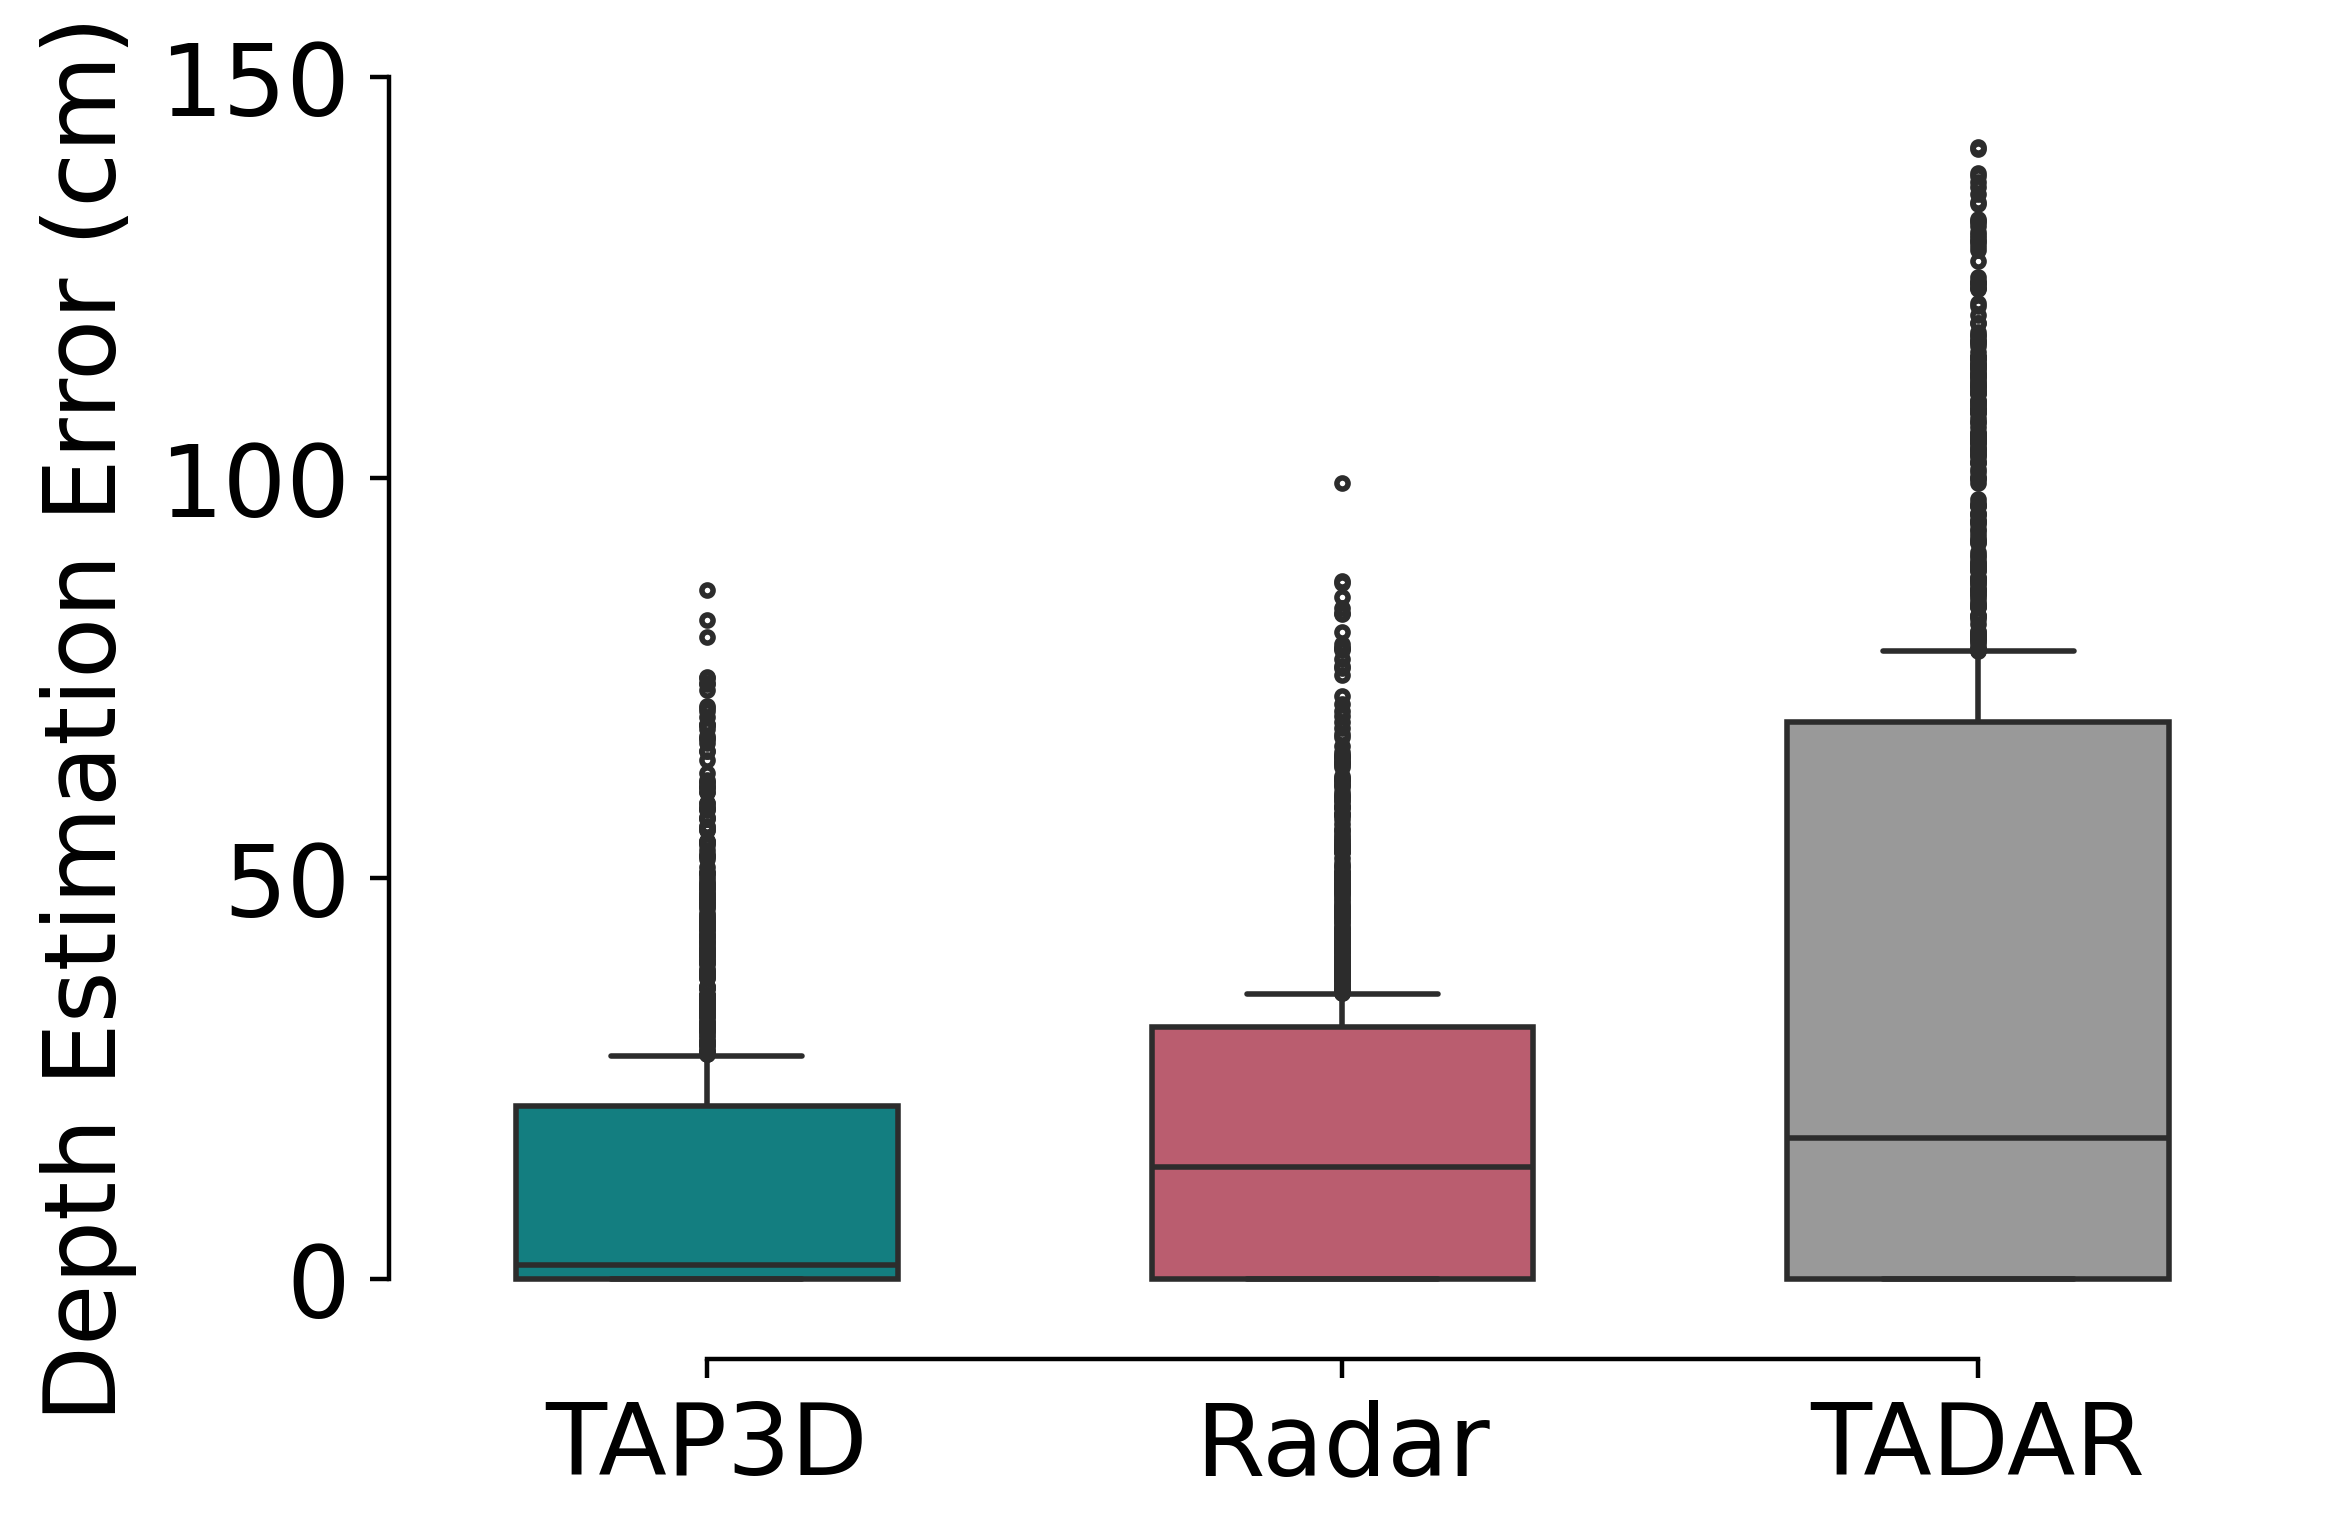

The mean and SEM of the error
radar: 19.097514536319693, 0.6408054320286242
tap3d: 13.043603354516973, 0.5938356813913391
tadar: 36.7359905778102, 1.3225353372165396


In [46]:
compare_results_folder = 'TAP3D_compare2others'

radar_error_all = []
tap3d_error_all = []
tadar_error_all = []

gt_data_list = []
radar_data_list = []
tap3d_data_list = []
tadar_data_list = []

files = [
    'data_m08_0_merged_data.pkl',
    'data_m08_1_merged_data.pkl', 
    'data_m08_2_merged_data.pkl',
    'data_m08_3_merged_data.pkl', 
    'data_m08_4_merged_data.pkl',
    ]


# tolerance to account for user body size (mm)
tolerance_mm = 150

for index, file in enumerate(files):
    compare_results = pickle.load(open(os.path.join(compare_results_folder, file), 'rb'))
    
    # we remove the first and last 5% of the data since the start of TADAR system is not stable
    compare_results = compare_results.iloc[int(len(compare_results) * 0.2):int(len(compare_results) * 0.8)]
    
    compare_results['tadar_depth'] = compare_results['tadar_depth'] - 2000  # remove the constant offset of the TADAR system
    compare_results['radar_depth'] = compare_results['radar_depth'] - 500  # remove the constant offset of the radar system
    compare_results['tadar_depth'] = np.abs(compare_results['tadar_depth'])
    # tadar has a time delay due to its temporal aggregation, so we shift the tadar_depth to earlier for time alignment
    tadar_shift = 10  # Number of rows to shift; adjust as needed for proper alignment
    compare_results['tadar_depth'] = compare_results['tadar_depth'].shift(-tadar_shift)
    # Remove last tadar_shift rows that now contain NaN from the shift
    compare_results = compare_results.iloc[:-tadar_shift] if tadar_shift > 0 else compare_results
    
    
    # only keep the elements with gt data to 4000 
    selected_index = np.where(np.array(compare_results['groundtruth_depth']) < 4000)[0]
    compare_results = compare_results.iloc[selected_index]
    
    # apply tolerance so small offsets within body-size margin are ignored
    radar_error = np.clip(np.abs(compare_results['groundtruth_depth'] - compare_results['radar_depth']) - tolerance_mm, a_min=0, a_max=None)
    tap3d_error = np.clip(np.abs(compare_results['groundtruth_depth'] - compare_results['TAP3D_depth']) - tolerance_mm, a_min=0, a_max=None)
    tadar_error = np.clip(np.abs(compare_results['groundtruth_depth'] - compare_results['tadar_depth']) - tolerance_mm, a_min=0, a_max=None)
    # drop the nan values   
    radar_error = radar_error[np.isfinite(radar_error)]
    tap3d_error = tap3d_error[np.isfinite(tap3d_error)]
    tadar_error = tadar_error[np.isfinite(tadar_error)]
    
    gt_data_list.extend(compare_results['groundtruth_depth'])
    radar_data_list.extend(compare_results['radar_depth'])
    tap3d_data_list.extend(compare_results['TAP3D_depth'])
    tadar_data_list.extend(compare_results['tadar_depth'])
    
    radar_error_all.extend(radar_error)
    tap3d_error_all.extend(tap3d_error)
    tadar_error_all.extend(tadar_error)
    
    bins = [0. , 150. , 200, 250. ,  300. ,  350. ]

    df_results = pd.DataFrame({
        'groundtruth_depth': np.array(compare_results['groundtruth_depth'])/10,
        'radar_depth': np.array(compare_results['radar_depth'])/10,
        'tap3d_depth': np.array(compare_results['TAP3D_depth'])/10,
        'tadar_depth': np.array(compare_results['tadar_depth'])/10,
    })

    # calculate the error and the sem with tolerance converted to cm
    tolerance_cm = tolerance_mm / 10
    radar_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['radar_depth']) - tolerance_cm, a_min=0, a_max=None)
    tap3d_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['tap3d_depth']) - tolerance_cm, a_min=0, a_max=None)
    tadar_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['tadar_depth']) - tolerance_cm, a_min=0, a_max=None)
    radar_error_sem = radar_error.sem()
    tap3d_error_sem = tap3d_error.sem()
    tadar_error_sem = tadar_error.sem()

    df_results['radar_error'] = radar_error
    df_results['tap3d_error'] = tap3d_error
    df_results['tadar_error'] = tadar_error

    final_metrics = df_results.groupby(pd.cut(df_results['groundtruth_depth'], bins=bins)).agg({
        'radar_error': ['mean', 'sem'],
        'tap3d_error': ['mean', 'sem'],
        'tadar_error': ['mean', 'sem'],
    })


df_results = pd.DataFrame({
    # convert the unit to cm
    'groundtruth_depth': np.array(gt_data_list)/10,
    'radar_depth': np.array(radar_data_list)/10,
    'tap3d_depth': np.array(tap3d_data_list)/10,
    'tadar_depth': np.array(tadar_data_list)/10,
})


print(f"The number of samples: {len(gt_data_list)}")
print(f"The subject distance range: {np.min(gt_data_list)}, {np.max(gt_data_list)}")

# apply tolerance so small offsets within body-size margin are ignored
tolerance_cm = tolerance_mm / 10
radar_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['radar_depth']) - tolerance_cm, a_min=0, a_max=None)
tap3d_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['tap3d_depth']) - tolerance_cm, a_min=0, a_max=None)
tadar_error = np.clip(np.abs(df_results['groundtruth_depth'] - df_results['tadar_depth']) - tolerance_cm, a_min=0, a_max=None)

radar_error_sem = radar_error.sem()
tap3d_error_sem = tap3d_error.sem()
tadar_error_sem = tadar_error.sem()

df_results['radar_error'] = radar_error
df_results['tap3d_error'] = tap3d_error
df_results['tadar_error'] = tadar_error

final_metrics = df_results.groupby(pd.cut(df_results['groundtruth_depth'], bins=bins)).agg({
    'tap3d_error': ['mean', 'sem'],
    'radar_error': ['mean', 'sem'],
    'tadar_error': ['mean', 'sem'],
})


method_specs = [
    ('tap3d_error', '#019092', 'TAP3D'),
    ('radar_error', '#C94E65', 'Radar'),
    ('tadar_error', '#999999', 'TADAR'),
]

colors = ['#019092', '#C94E65', '#999999']

# filter out the nan values
radar_error = radar_error[np.isfinite(radar_error)]
tap3d_error = tap3d_error[np.isfinite(tap3d_error)]
tadar_error = tadar_error[np.isfinite(tadar_error)]

# Prepare the data for seaborn
import pandas as pd
df_box = pd.DataFrame({
    'error': np.concatenate([tap3d_error, radar_error, tadar_error]),
    'method': ['TAP3D'] * len(tap3d_error) + ['Radar'] * len(radar_error) + ['TADAR'] * len(tadar_error)
})


plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')
plt.rcParams.update({'font.size': 18})  # Set global font size to 18
sns.set_theme(style="ticks", font_scale=1.0)  # font_scale is additional, keeps style consistent

ax = sns.boxplot(
    data=df_box,
    x='method',
    y='error',
    palette=colors,
    whis=[0, 80],
    width=0.6,
    fliersize=2,
)

ax.set_ylabel("Depth Estimation Error (cm)", fontsize=18)
ax.set_xlabel("", fontsize=18)
ax.set_ylim(-10, 150)

# Set tick label size
ax.tick_params(axis='both', which='major', labelsize=18)

sns.despine(trim=True, left=False)
plt.tight_layout()
plt.show()

print("The mean and SEM of the error")
print(f"radar: {np.mean(radar_error)}, {np.mean(radar_error_sem)}")
print(f"tap3d: {np.mean(tap3d_error)}, {np.mean(tap3d_error_sem)}")
print(f"tadar: {np.mean(tadar_error)}, {np.mean(tadar_error_sem)}")



### Figure 11: Overall performance.

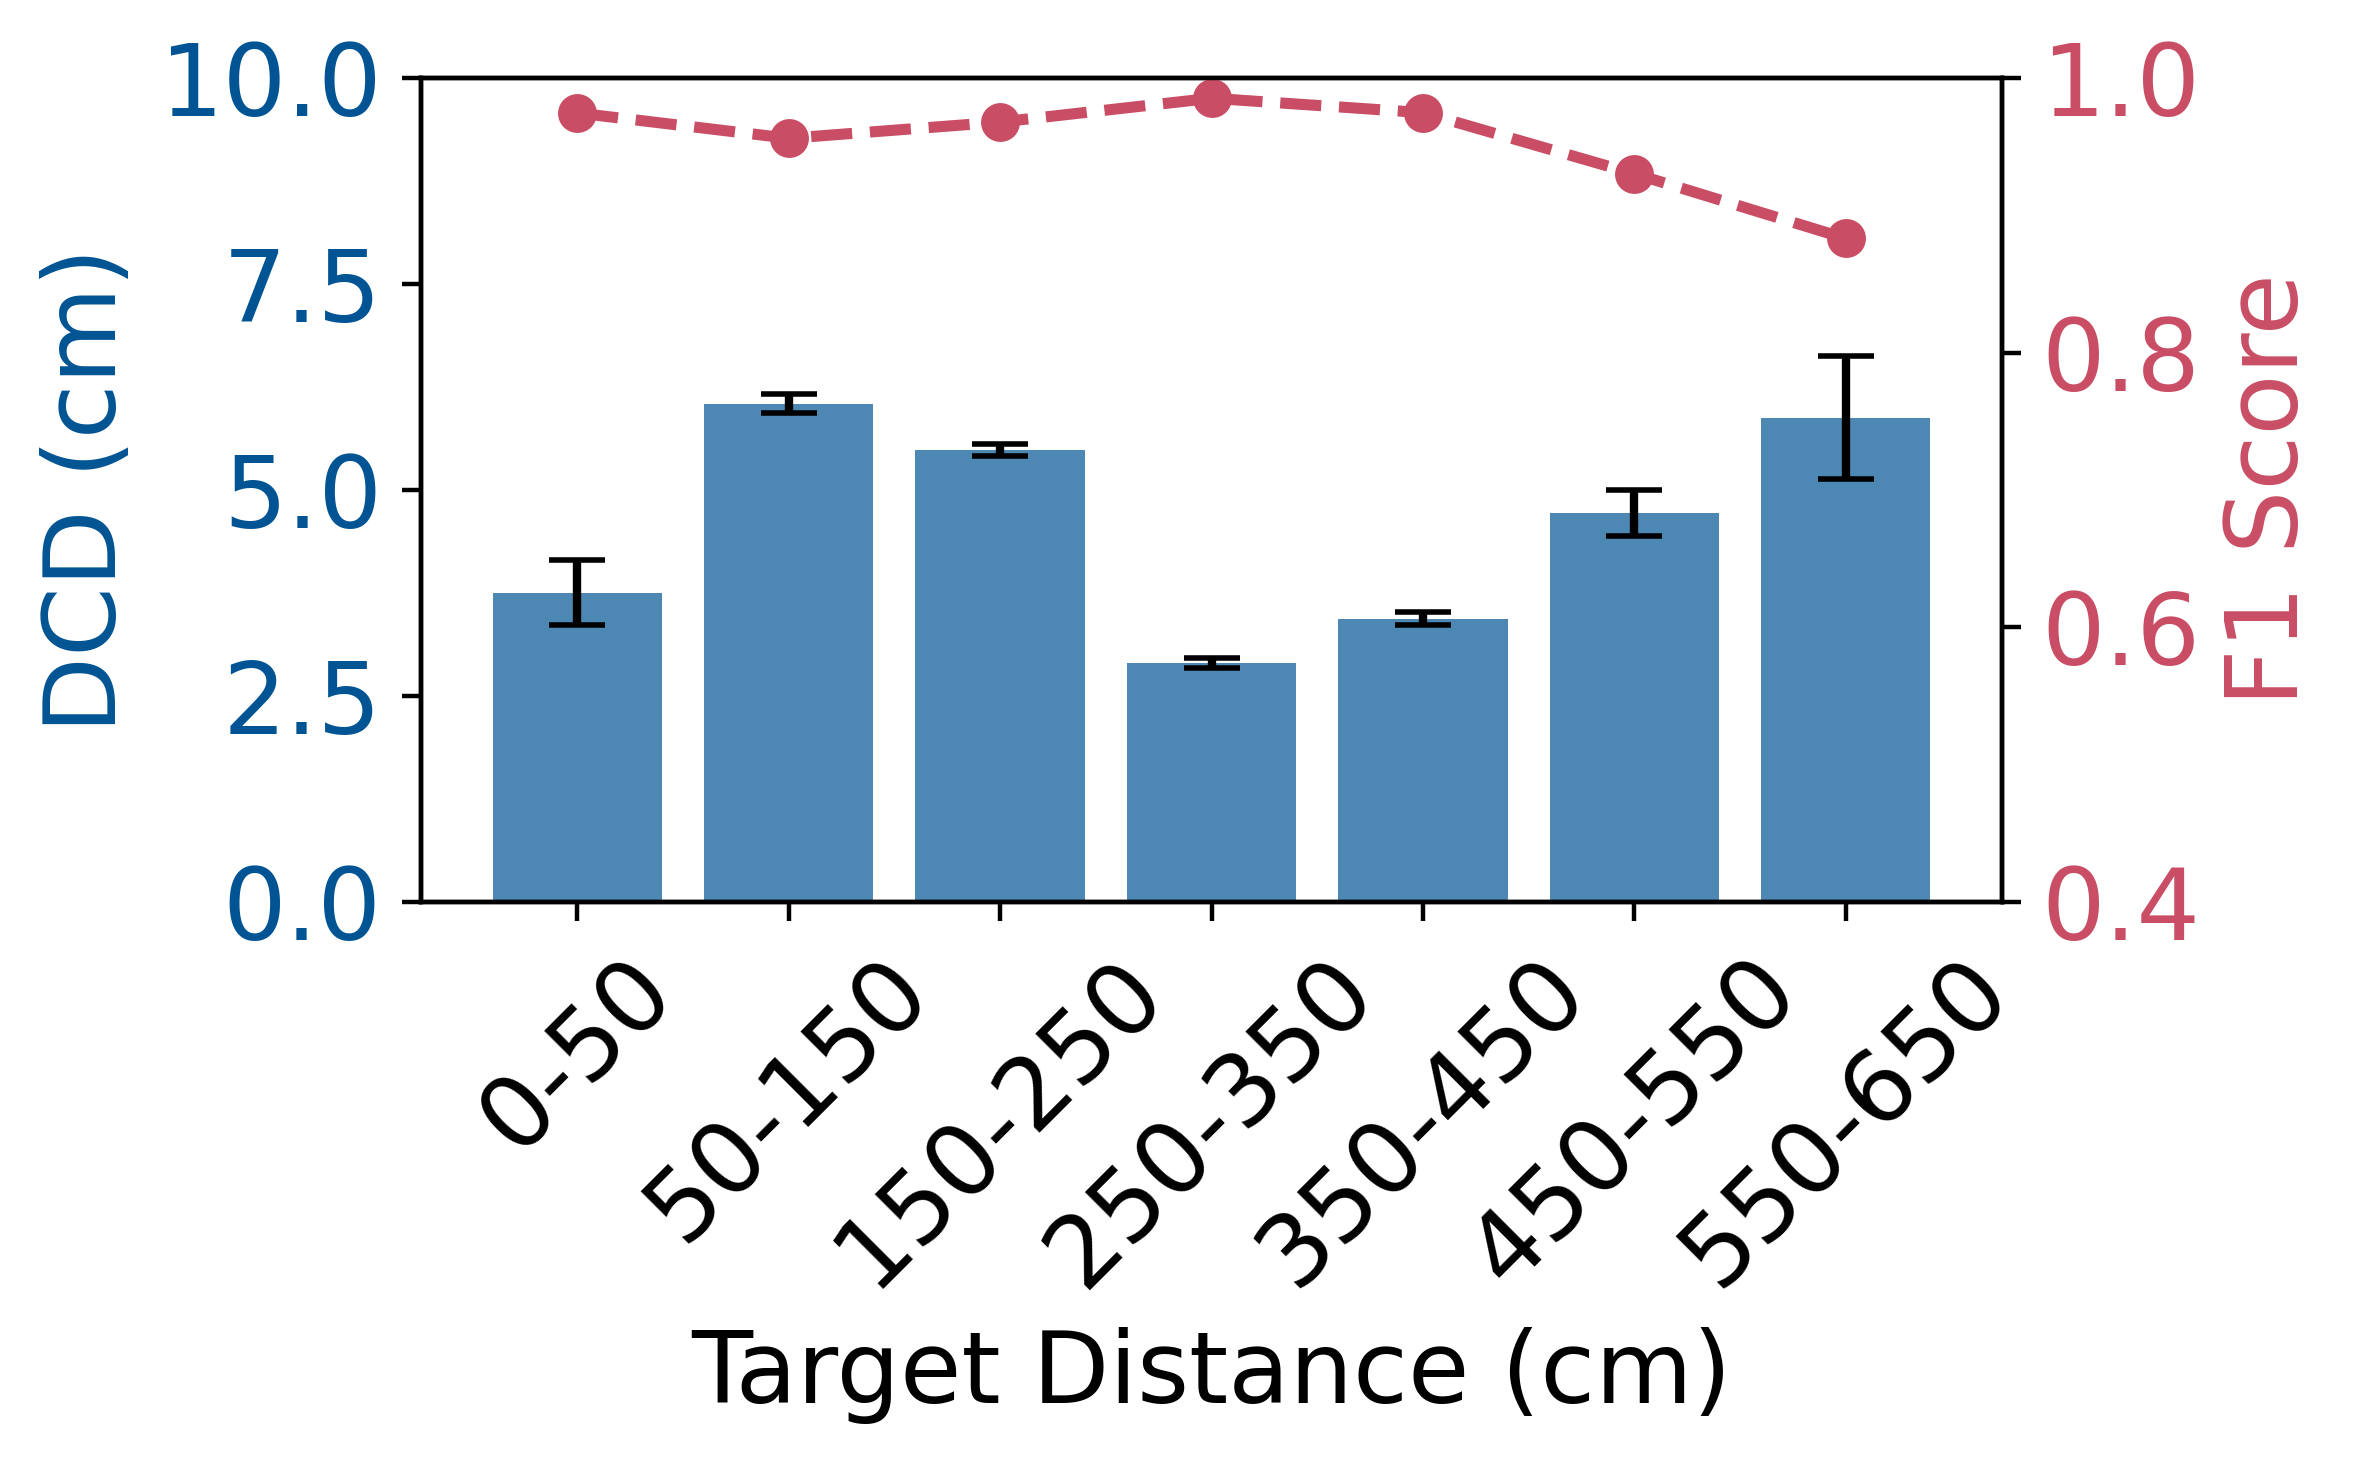

mean f1 score: 0.9531332235567948
mean of DCD: 4.6031101269876995


In [18]:
selected_metrics_df = load_metrics_df_0(TAP3D_Log_folder_path, file_names)

min_distance = 0
max_distance = 6500 # mm
selected_metrics_df = selected_metrics_df[(selected_metrics_df['z_average'] >= min_distance) & (selected_metrics_df['z_average'] <= max_distance)]

# bins=np.linspace(min_distance, max_distance, num_bins+1)
bins = [0. , 500. , 1500. ,  2500. ,  3500. ,  4500. , 5500. , 6500.]
distance_bins = pd.cut(selected_metrics_df['z_average'], bins=bins, include_lowest=True)

distance_metrics = selected_metrics_df.groupby(distance_bins).apply(lambda x: pd.Series({
    'distance_range': f"{x['z_average'].min():.1f}-{x['z_average'].max():.1f}",
    'precision': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_positives'].sum()) if (x['true_positives'].sum() + x['false_positives'].sum()) > 0 else 0,
    'recall': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_negatives'].sum()) if (x['true_positives'].sum() + x['false_negatives'].sum()) > 0 else 0,
    'chamfer_distance': x['chamfer_distance'].mean(),
    'chamfer_distance_std': x['chamfer_distance'].std(),
    'chamfer_distance_sem': x['chamfer_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    'hausdorff_distance': x['hausdorff_distance'].mean(),
    'hausdorff_distance_std': x['hausdorff_distance'].std(),
    'hausdorff_distance_sem': x['hausdorff_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    'point2point_distance': (x['point2point_distance'] / 10).mean(), # unit is cm
    'point2point_distance_std': (x['point2point_distance'] / 10).std(),
    'point2point_distance_sem': (x['point2point_distance'] / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    'sample_count': len(x),
    'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance']/2)/10).mean(), # unit is cm
    'One_directional_Chamfer_Distance_std': (np.sqrt(x['chamfer_distance']/2)/10).std(),
    'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance']/2)/10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
}))

# Calculate F1 score
distance_metrics['f1_score'] = 2 * (distance_metrics['precision'] * distance_metrics['recall']) / (distance_metrics['precision'] + distance_metrics['recall']) if (distance_metrics['precision'] + distance_metrics['recall']).all() > 0 else 0

x_labels = (distance_metrics.index.categories.left / 10).astype(int).astype(str) + '-' + (distance_metrics.index.categories.right / 10).astype(int).astype(str)

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize = (6,4),dpi=400, layout='constrained')

x = range(len(x_labels))

# Bar plot for Chamfer Distance Error (left y-axis)
bars = ax1.bar(
    x,
    distance_metrics['One_directional_Chamfer_Distance'],
    yerr=distance_metrics['One_directional_Chamfer_Distance_sem'],
    capsize=5,
    color='#015493',
    alpha=0.7,
    label="DCD"
)
ax1.set_ylim(0, 10)
ax1.set_xlabel('Target Distance (cm)')
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')

# Second y-axis for F1 score
ax2 = ax1.twinx()
ax2.plot(
    x,
    distance_metrics['f1_score'],
    color='#C94E65',
    marker='o',
    linestyle='--',
    linewidth=2,
    label="F1 Score"
)
ax2.set_ylim(0.4, 1)
ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')

# x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)

# Optional legend combining both plots
lines, labels = [], []
for ax in [ax1, ax2]:
    line, label = ax.get_legend_handles_labels()
    lines += line
    labels += label
plt.tight_layout()

plt.show()

print('mean f1 score:',distance_metrics['f1_score'].mean())
print('mean of DCD:',distance_metrics['One_directional_Chamfer_Distance'].mean())


## 3. Micro-benchmark

### Figure 12: Results across environments

Selected metrics shape: (25456, 16)

Seen Users (n=8):
Average F1 Score: 0.991 ± 0.010
Average one-directional Chamfer Distance: 1.854 ± 0.473

Unseen Users (n=3):
Average F1 Score: 0.996 ± 0.004
Average one-directional Chamfer Distance: 1.895 ± 0.538


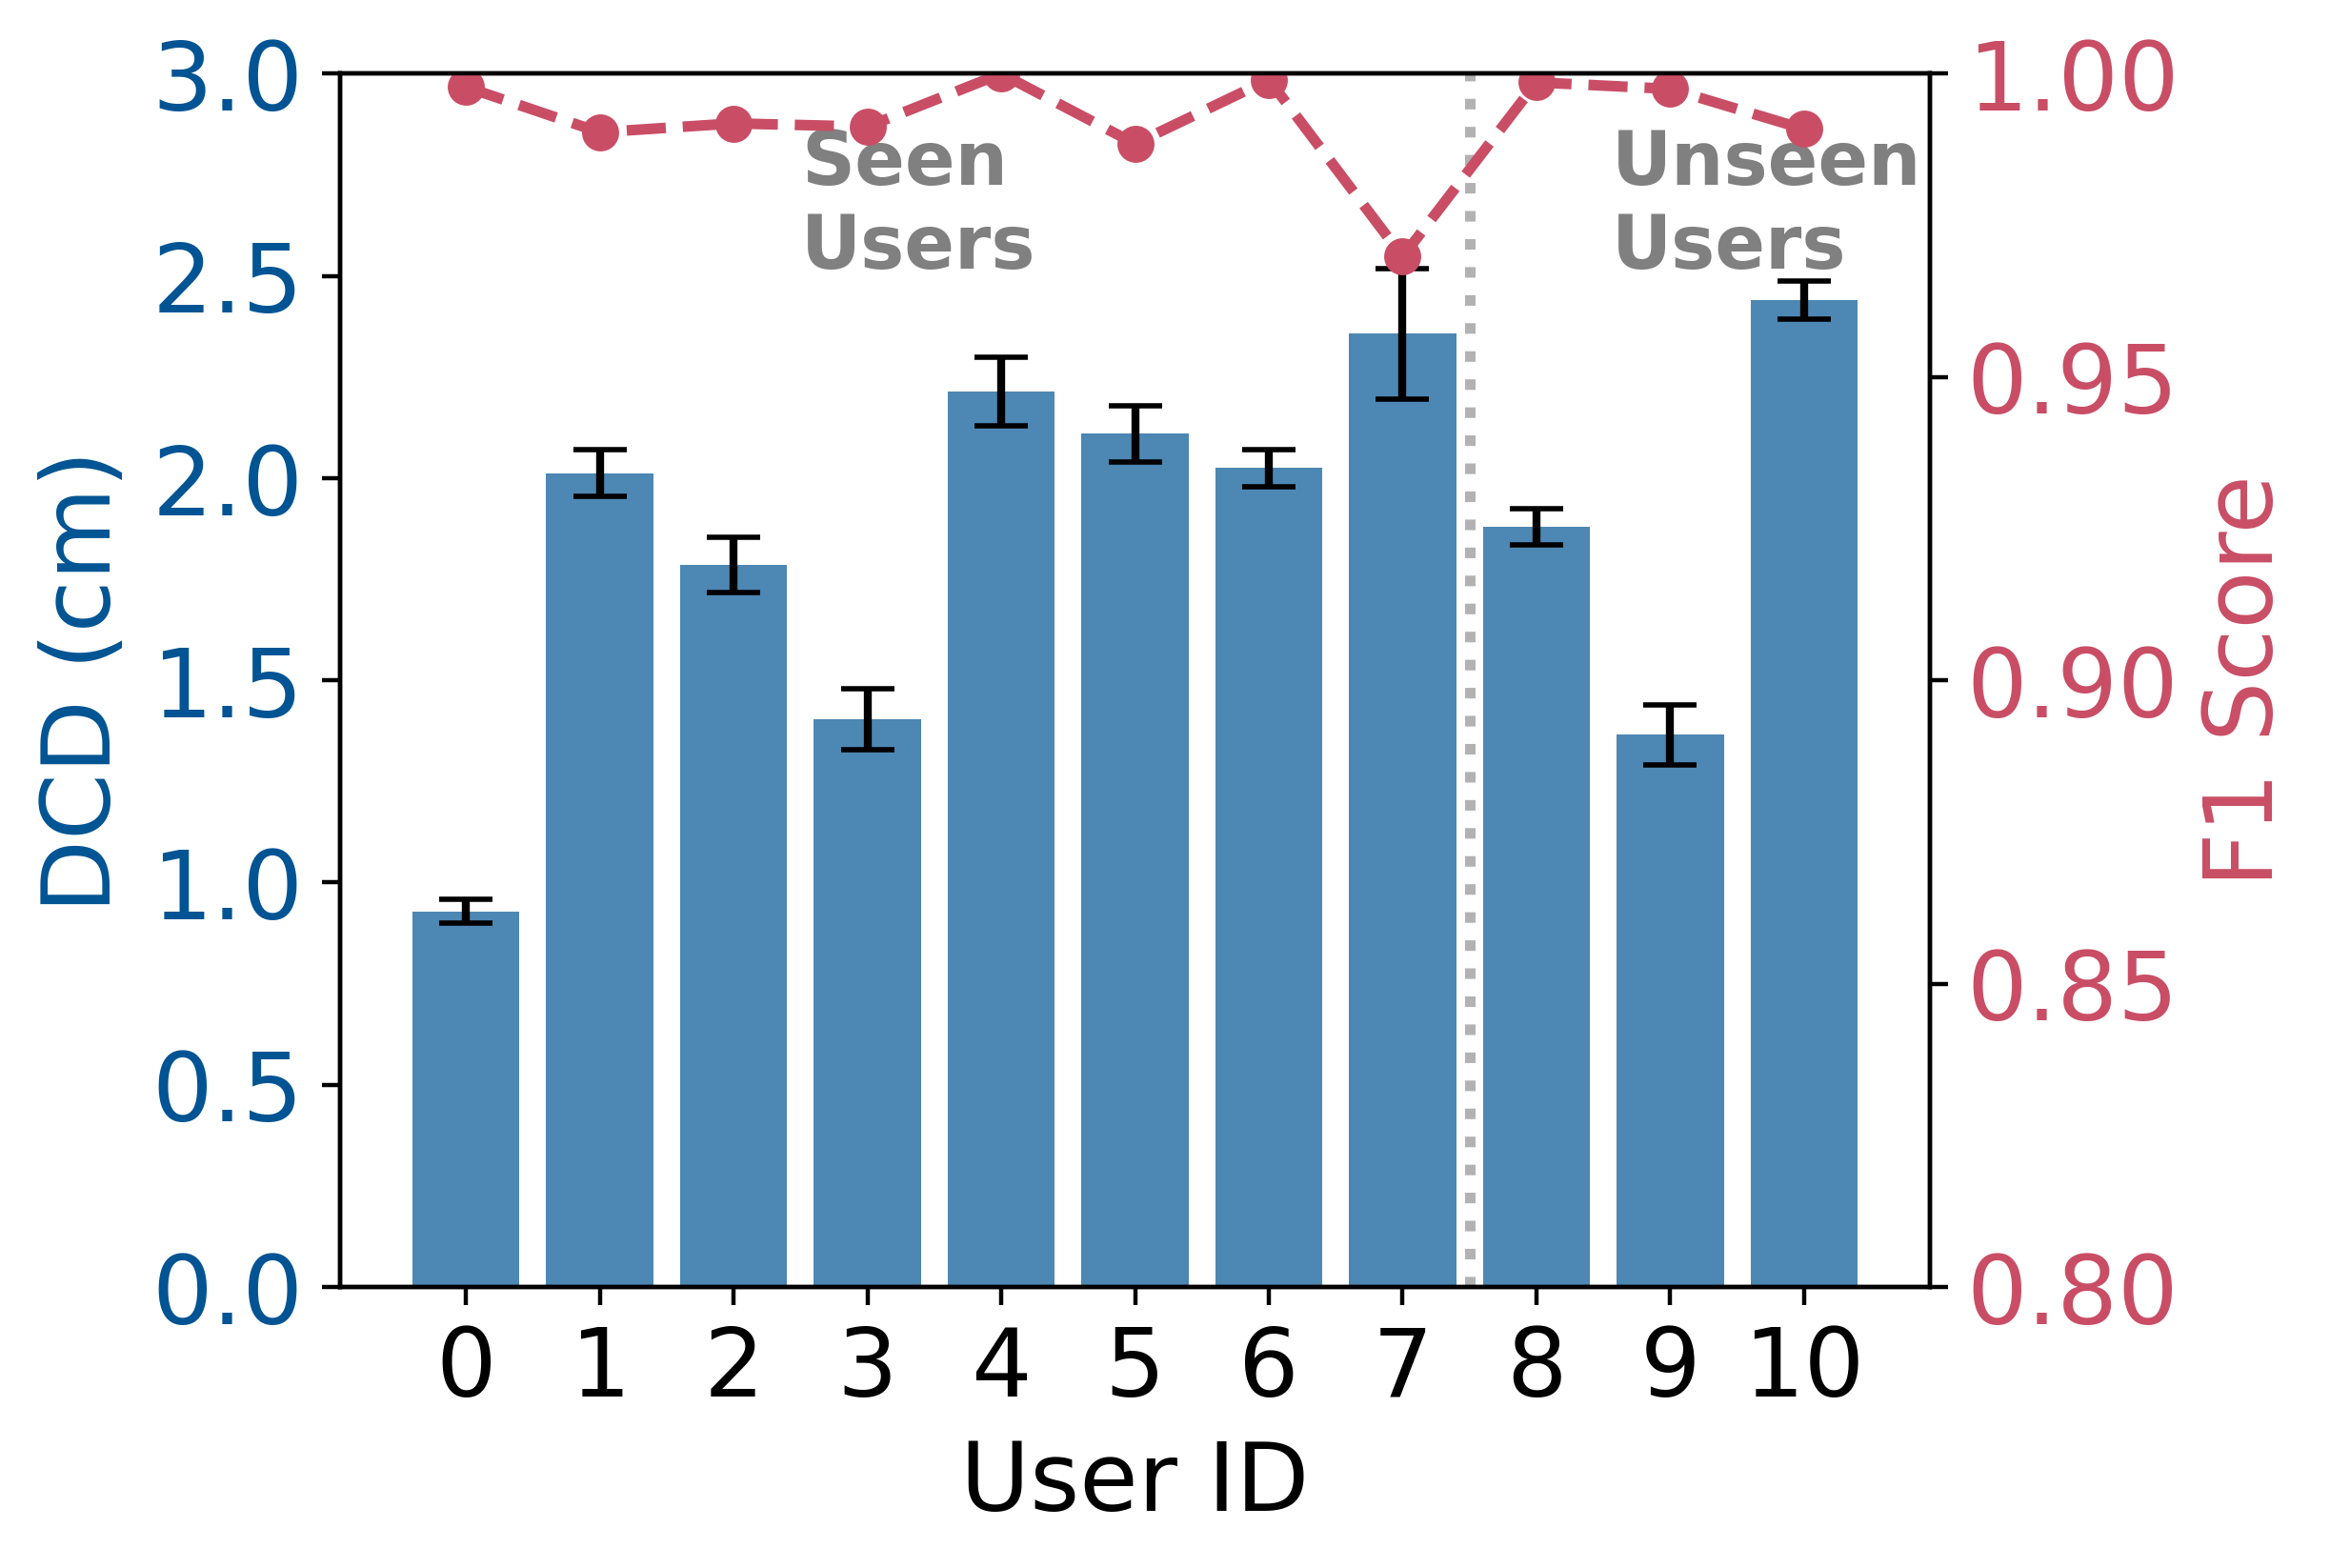

In [21]:
# Select recordings from multiple users in similar environments (E0 and E1) for cross-user analysis.
selected_recordings = [
    'U0_E0_1_standing_1o3_none_1.pkl',  
    'U0_E0_1_walking_1o3_none_3.pkl',
    'U0_E0_1_walking_1o3_none_5.pkl',
    'U0_E0_1_walking_1o3_none_1.pkl',

    'U1_E0_1_standing_1o3_none_2.pkl',
    'U1_E0_1_standing_1o3_none_3.pkl',
    'U1_E0_1_walking_1o3_none_4.pkl',
    'U1_E0_1_walking_1o3_none_5.pkl',
    'U1_E0_1_walking_1o3_none_6.pkl',
    'U1_E2_1_sitting_1o3_none_2.pkl',
    'U1_E2_1_standing_1o3_none_1.pkl',
    'U1_E2_1_walking_1o3_none_0.pkl',
    'U1_E2_1_walking_1o3_none_2.pkl',

    'U2_E0_1_sitting_1o3_none_2.pkl',
    'U2_E0_1_walking_1o3_none_2.pkl',
    'U2_E0_1_walking_1o3_none_3.pkl',
    'U2_E0_1_walking_1o3_none_4.pkl',
    'U2_E0_1_walking_1o3_none_5.pkl',
    'U2_E2_1_sitting_1o3_none_1.pkl',
    'U2_E2_1_walking_1o3_none_0.pkl',

    'U3_E0_1_standing_1o3_none_0.pkl',
    'U3_E0_1_standing_1o3_none_1.pkl',
    'U3_E0_1_walking_1o3_none_4.pkl',

    'U4_E0_1_sitting_1o3_none_0.pkl',
    'U4_E0_1_sitting_1o3_none_1.pkl',
    'U4_E0_1_standing_1o3_none_1.pkl',
    'U4_E0_1_walking_1o3_none_0.pkl',
    'U4_E0_1_walking_1o3_none_2.pkl',
    'U4_E0_1_sitting_1o3_none_2.pkl',
    'U4_E0_1_sitting_1o3_none_3.pkl',
    'U4_E0_1_walking_1o3_none_1.pkl',
    'U4_E0_1_walking_1o3_none_3.pkl',

    'U5_E0_1_sitting_1o3_none_1.pkl',
    'U5_E0_1_walking_1o3_none_1.pkl',

    'U6_E0_1_standing_1o3_none_0.pkl',
    'U6_E0_1_standing_1o3_none_2.pkl',

    'U7_E2_1_sitting_1o3_none_1.pkl',
    'U7_E2_1_walking_1o3_none_2.pkl',
    'U7_E2_1_walking_1o3_none_3.pkl',

    'U8_E2_1_walking_1o3_none_2.pkl',
    'U8_E2_1_lying_1o3_none_2.pkl', 
    'U8_E2_1_sitting_1o3_none_2.pkl',
    'U8_E2_1_walking_1o3_none_3.pkl',
    'U8_E2_1_walking_1o3_none_4.pkl',

    'U9_E2_1_lying_1o3_none_1.pkl',
    'U9_E2_1_lying_1o3_none_3.pkl',
    'U9_E2_1_sitting_1o3_none_3.pkl',
    'U9_E2_1_walking_1o3_none_0.pkl',
    'U9_E2_1_walking_1o3_none_3.pkl',
    'U10_E2_1_sitting_1o3_none_1.pkl',
 ]


for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)

metrics_df = load_metrics_df_0(TAP3D_Log_folder_path, selected_recordings)

# Define seen and unseen users
Seen = [0, 1, 2, 3, 6, 7, 9, 10]
Unseen = [4, 5, 8]

def create_performance_visualization(selected_metrics_df):
    """
    Create performance visualization with different colors for seen and unseen users
    """
    print(f"Selected metrics shape: {selected_metrics_df.shape}")
    # Group by user_id and calculate metrics for each user
    user_metrics = selected_metrics_df.groupby('user_id').apply(
        lambda x: pd.Series({
            'user_id': x['user_id'].iloc[0],
            'true_positives': x['true_positives'].sum(),
            'false_positives': x['false_positives'].sum(),
            'false_negatives': x['false_negatives'].sum(),
            'chamfer_distance': x['chamfer_distance'].mean(),
            'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
            'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        })
    ).reset_index(drop=True)
    user_metrics['f1_score'] = 2 * user_metrics['true_positives'] / (2 * user_metrics['true_positives'] + user_metrics['false_positives'] + user_metrics['false_negatives'])

    # Print summary statistics for seen vs unseen
    seen_metrics = user_metrics[user_metrics['user_id'].isin(Seen)]
    unseen_metrics = user_metrics[user_metrics['user_id'].isin(Unseen)]
    
    print(f"\nSeen Users (n={len(seen_metrics)}):")
    print(f"Average F1 Score: {seen_metrics['f1_score'].mean():.3f} ± {seen_metrics['f1_score'].std():.3f}")
    print(f"Average one-directional Chamfer Distance: {seen_metrics['One_directional_Chamfer_Distance'].mean():.3f} ± {seen_metrics['One_directional_Chamfer_Distance'].std():.3f}")
    
    print(f"\nUnseen Users (n={len(unseen_metrics)}):")
    print(f"Average F1 Score: {unseen_metrics['f1_score'].mean():.3f} ± {unseen_metrics['f1_score'].std():.3f}")
    print(f"Average one-directional Chamfer Distance: {unseen_metrics['One_directional_Chamfer_Distance'].mean():.3f} ± {unseen_metrics['One_directional_Chamfer_Distance'].std():.3f}")


    df = user_metrics.copy()

    # Split & order: Seen first (sorted), then Unseen (sorted)
    df_seen   = df[df['user_id'].isin(Seen)].sort_values('user_id')
    df_unseen = df[df['user_id'].isin(Unseen)].sort_values('user_id')
    df_plot   = pd.concat([df_seen, df_unseen], ignore_index=True)

    # To make the indication clear, we use 0 - 10 for the user label, not follow the user_id !!!!!!!!
    x_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
    x = np.arange(len(x_labels))

    # Optional error bars if present
    cd_err = df_plot['One_directional_Chamfer_Distance_sem'] if 'One_directional_Chamfer_Distance_sem' in df_plot.columns else None
    f1_err = df_plot['f1_sem'] if 'f1_sem' in df_plot.columns else None

    plt.rcParams.update({'font.size': 18})
    fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

    # --- Bars: Directed Chamfer Distance (left y-axis) ---
    bars = ax1.bar(
        x,
        df_plot['One_directional_Chamfer_Distance'],
        yerr=cd_err,
        capsize=5 if cd_err is not None else 0,
        color='#015493',
        alpha=0.7,
        label='DCD'
    )
    ax1.set_ylabel('DCD (cm)', color='#015493')
    ax1.tick_params(axis='y', labelcolor='#015493')

    # Set a sensible y-limit
    if df_plot['One_directional_Chamfer_Distance'].notna().any():
        ymax = float(np.nanmax(df_plot['One_directional_Chamfer_Distance'])) * 1.15
        ax1.set_ylim(0, 3)

    # --- Line: F1 Score (right y-axis) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        df_plot['f1_score'],
        marker='o',
        linestyle='--',
        linewidth=2,
        color='#C94E65',
        label='F1 Score'
    )
    if f1_err is not None:
        ax2.fill_between(x, df_plot['f1_score'] - f1_err, df_plot['f1_score'] + f1_err, alpha=0.15)
    ax2.set_ylabel('F1 Score', color='#C94E65')
    ax2.tick_params(axis='y', labelcolor='#C94E65')
    ax2.set_ylim(0.8, 1.0)

    # --- X ticks & label coloring ---
    ax1.set_xlabel('User ID')
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=0, ha='center')

    seen_color   = '#2E86AB'  # blue for Seen
    unseen_color = '#A23B72'  # purple for Unseen
    seen_count = len(df_seen)

    # Optional separator between Seen and Unseen groups
    if seen_count > 0 and seen_count < len(df_plot):
        ax1.axvline(seen_count - 0.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)
        
    # add to text boxs, left is 'Seen' and right is 'Unseen'
    ax1.text(0.29, 0.84, 'Seen\nUsers', transform=ax1.transAxes, color='gray', fontsize=14, fontweight='bold')
    ax1.text(0.8, 0.84, 'Unseen\nUsers', transform=ax1.transAxes, color='gray', fontsize=14, fontweight='bold')
    plt.show()
    return user_metrics

user_metrics = create_performance_visualization(metrics_df)


### Figure 13: Cross-user performance.

Selected metrics shape: (36225, 16)
Seen Environments: 0-4
Mean Directed Chamfer Distance:  2.3016550352131917
Mean F1 Score:  0.985217347168429
Unseen Environments: 5-7
Mean Directed Chamfer Distance:  3.34052555197702
Mean F1 Score:  0.9668115601134849


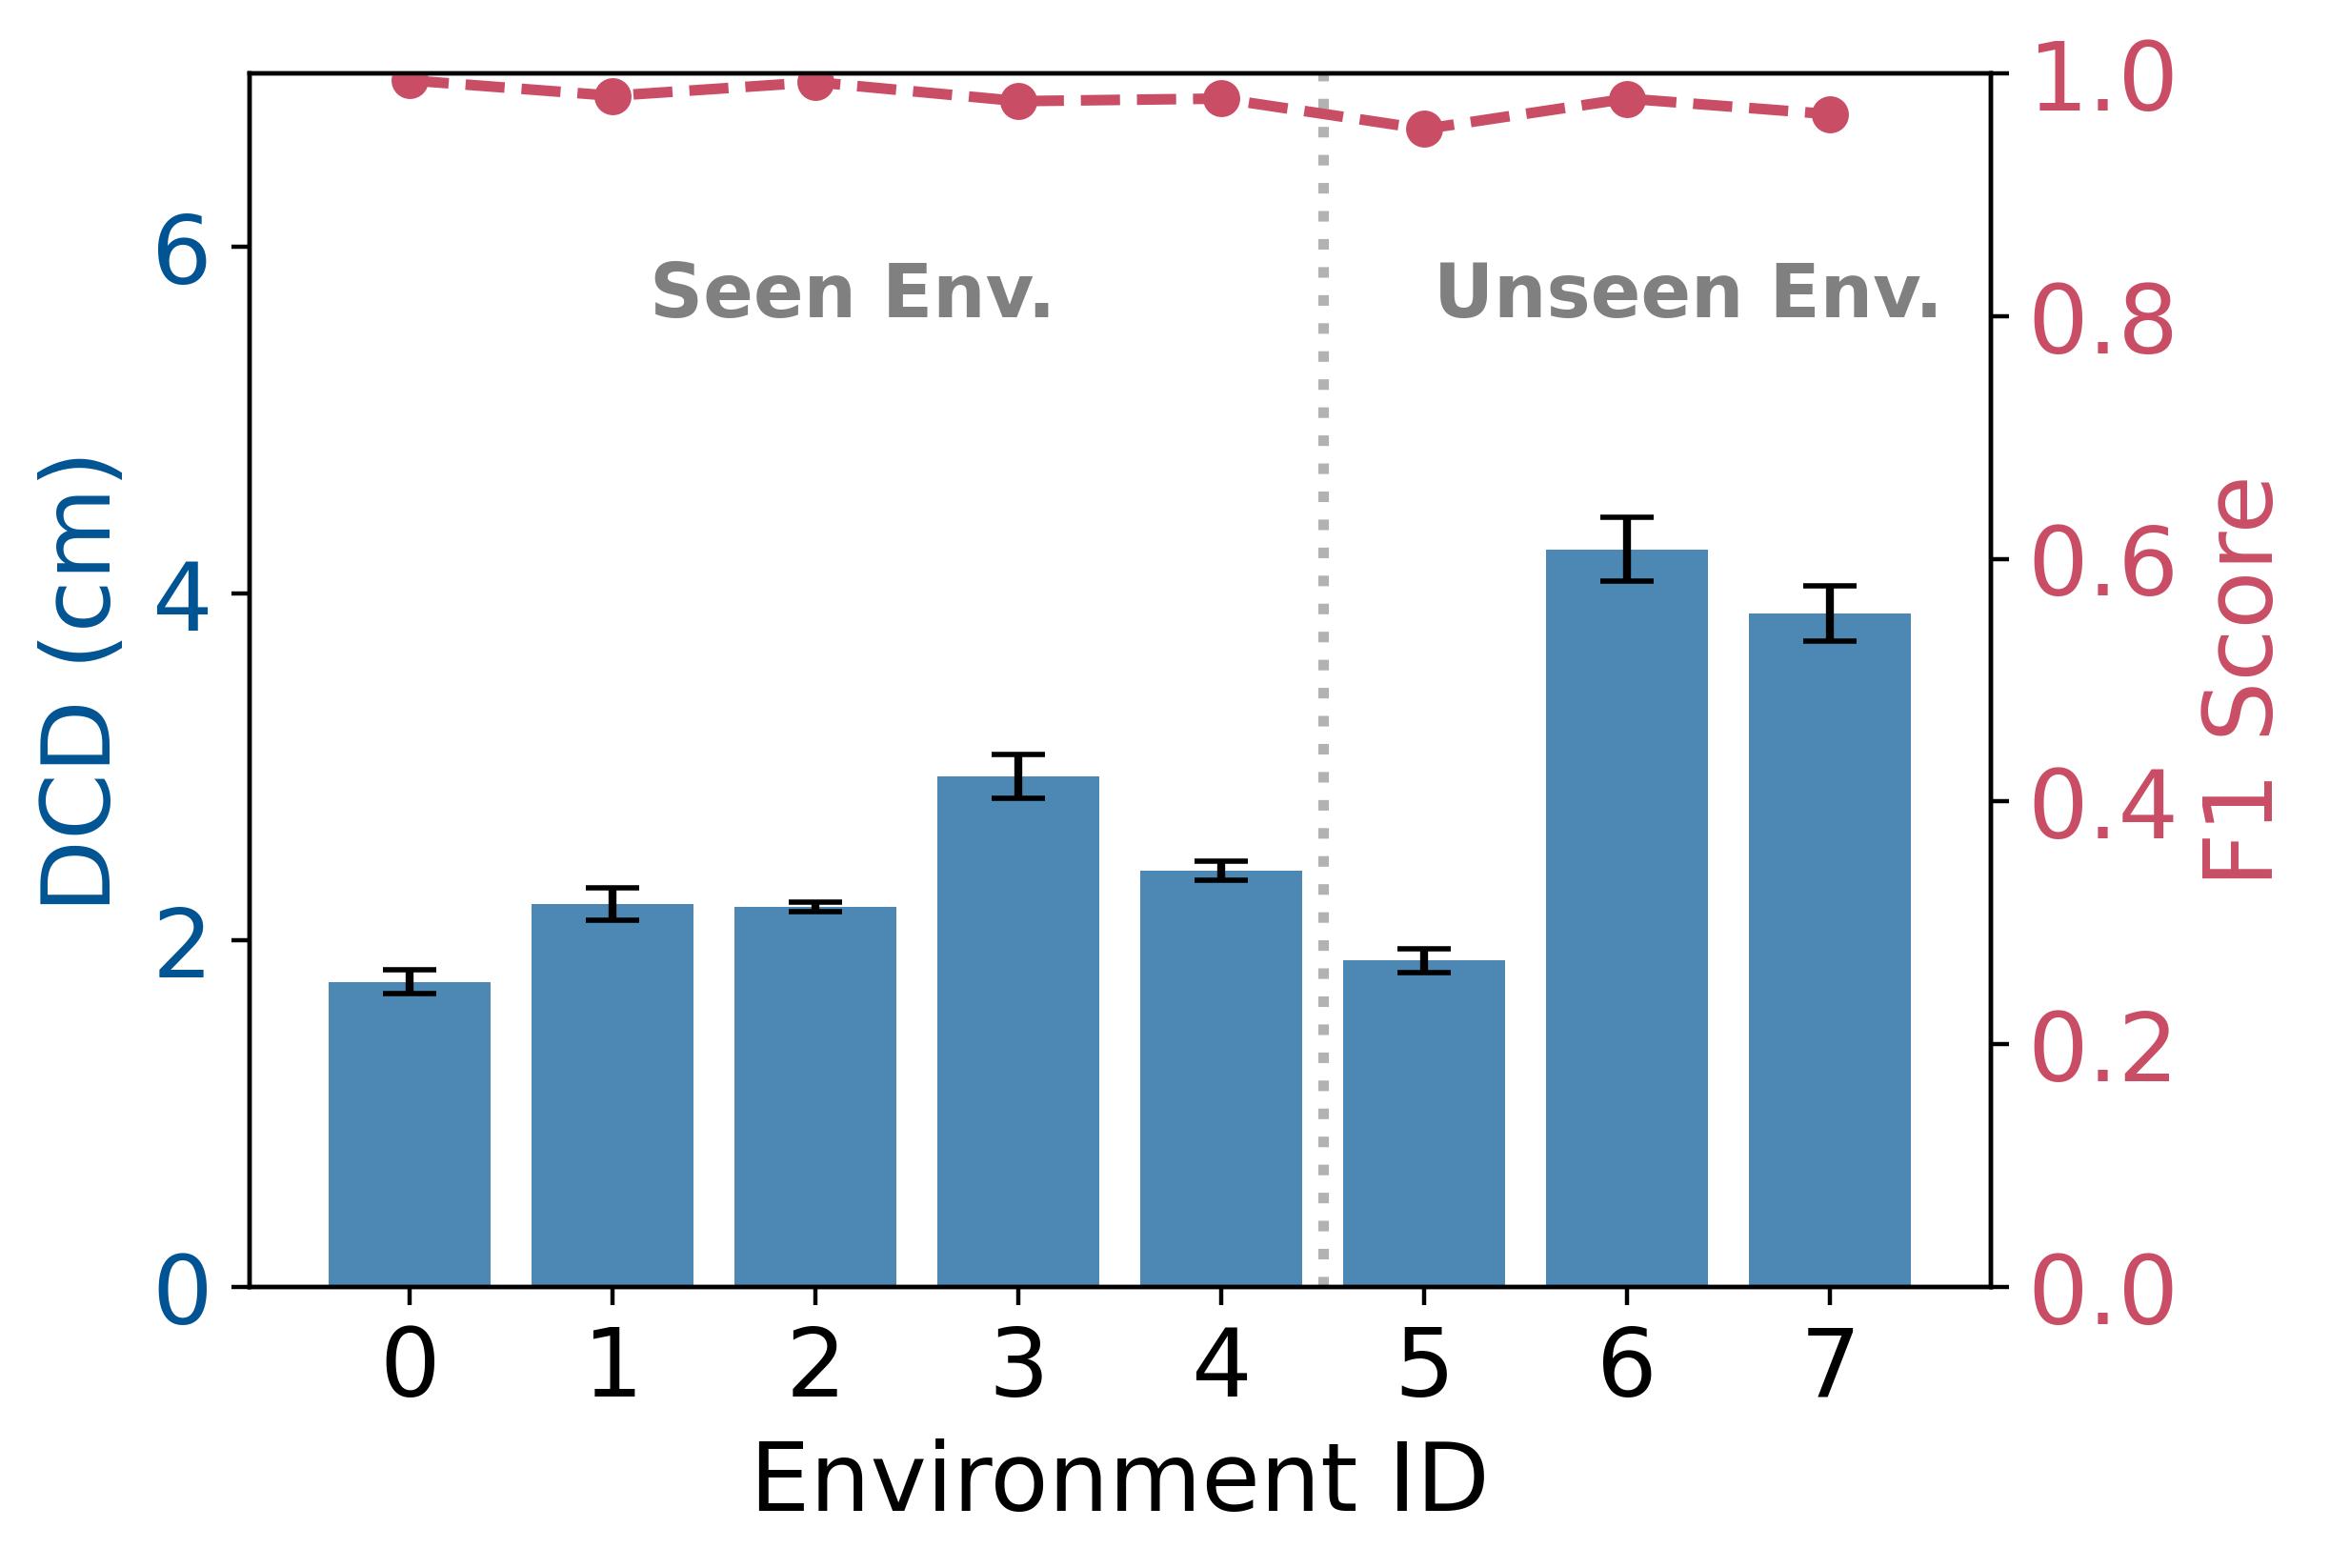

In [23]:
selected_recordings = [
    'U0_E0_1_standing_1o3_none_1.pkl',
    'U0_E0_1_walking_0o7_OLBP-0_1.pkl',
    'U0_E0_1_walking_1o3_none_5.pkl',
    'U1_E0_1_standing_1o3_none_3.pkl',
    'U1_E0_1_walking_1o3_none_4.pkl',
    'U1_E0_1_walking_1o3_none_5.pkl',
    'U1_E0_1_walking_1o3_none_6.pkl',
    'U2_E0_1_sitting_1o3_none_2.pkl',
    'U2_E0_1_walking_1o3_none_2.pkl',
    'U2_E0_1_walking_1o3_none_3.pkl',
    'U2_E0_1_walking_1o3_none_4.pkl',
    'U2_E0_1_walking_1o3_none_5.pkl',

    'U2_E1_1_walking_1o3_none_1.pkl',
    'U2_E1_1_walking_1o3_none_2.pkl',

    'U1_E2_1_sitting_1o3_none_2.pkl',
    'U1_E2_1_standing_1o3_none_1.pkl',
    'U1_E2_1_walking_1o3_none_2.pkl',
    'U2_E2_1_sitting_1o3_none_1.pkl',
    'U2_E2_1_walking_1o3_none_0.pkl',

    'U0_E3_1_walking_0o3_DH_0.pkl',
    'U0_E3_1_walking_0o3_DH_1.pkl',
    'U0_E3_1_walking_0o7_DH_1.pkl',
    'U0_E3_1_walking_1o0_AI-PC_1.pkl',
    'U0_E3_1_walking_1o0_AI-PT_2.pkl',
    'U0_E3_1_walking_1o0_C-C_2.pkl',
    'U0_E3_1_walking_1o0_C-D_1.pkl',
    'U0_E3_1_walking_1o0_C-D_2.pkl',
    'U0_E3_1_walking_1o0_HMG-CH_1.pkl',
    'U0_E3_1_walking_1o0_HMG-M_1.pkl',
    'U0_E3_1_walking_1o0_HMG-M_2.pkl',
    'U0_E3_1_walking_1o0_UO150_2.pkl',
    'U0_E3_1_walking_1o0_WS-0_1.pkl',
    'U0_E3_1_walking_1o0_WS-0_2.pkl',
    'U0_E3_1_walking_1o0_WS-1_2.pkl',
    'U0_E3_1_walking_1o0_WS-2_2.pkl',
    'U0_E3_1_walking_1o0_WS-3_2.pkl',
    'U0_E3_1_walking_1o4_DH_2.pkl',

    'U0_E4_1_standing_1o2_AI-SC_0.pkl',
    'U0_E4_1_standing_1o2_AI-ST_0.pkl',
    'U0_E4_1_walking_1o2_AI-SC_0.pkl',
    'U0_E4_1_walking_1o2_AI-SC_1.pkl',
    'U0_E4_1_walking_1o2_AI-SC_2.pkl',
    'U0_E4_1_walking_1o2_AI-ST_0.pkl',
    'U0_E4_1_walking_1o2_AI-ST_1.pkl',
    'U0_E4_1_walking_1o2_AI-ST_2.pkl',

    'U0_E7_1_cooking_1o0_AI-CC_2.pkl',
    'U0_E7_1_cooking_1o0_AI-CC_3.pkl',
    'U0_E7_1_cooking_1o0_AI-CT_5.pkl',
    'U0_E7_1_cooking_1o0_AI-CT_7.pkl',
    'U0_E7_1_walking_1o0_C-S_3.pkl',
    'U0_E7_1_walking_1o0_IA-0_2.pkl',
    'U0_E7_1_walking_1o0_IA-15_2.pkl',
    'U0_E7_1_walking_1o0_IA-30_1.pkl',
    'U0_E7_1_walking_1o0_IA-45_2.pkl',

    'U2_E11_1_walking_0o8_none_4.pkl',
    'U2_E11_1_walking_1o3_none_0.pkl',
    'U2_E11_1_walking_1o3_none_1.pkl',
    'U2_E11_1_walking_1o3_none_2.pkl',
    'U2_E11_1_walking_1o3_none_3.pkl',
    'U1_E11_1_standing_1o3_IA-15_2.pkl',
    'U1_E11_1_standing_1o3_IA-45_0.pkl',
    'U1_E11_1_standing_1o3_IA-45_1.pkl',
    'U1_E11_1_standing_1o3_UO30_2.pkl',
    'U1_E11_1_walking_1o3_none_0.pkl',
    'U1_E11_1_walking_1o3_none_1.pkl',
    'U1_E11_1_walking_1o3_none_2.pkl',
    'U1_E11_1_walking_1o3_none_4.pkl',

    'U0_E12_1_walking_1o3_none_0.pkl',
    'U0_E12_1_walking_1o3_none_5.pkl',
    'U1_E12_1_walking_1o3_none_1.pkl',
    'U1_E12_1_walking_1o3_none_2.pkl',
    'U1_E12_1_walking_1o3_none_4.pkl',
]

for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)

metrics_df = load_metrics_df_0(TAP3D_Log_folder_path, selected_recordings)

# Define seen and unseen environments
Seen = [0, 2, 3, 7,  11]  # Seen environment IDs
Unseen = [1, 4, 12, ]  # Unseen environment IDs

def create_performance_visualization(selected_metrics_df):
    """
    Create performance visualization with different colors for seen and unseen users
    """
    print(f"Selected metrics shape: {selected_metrics_df.shape}")
    
    # Extract environment ID from file names
    def extract_env_id(filename):
        # Remove .pkl extension
        filename = filename.replace('.pkl', '')
        # Extract environment ID (E followed by number)
        import re
        match = re.search(r'E(\d+)', filename)
        if match:
            return int(match.group(1))
        return None
    
    selected_metrics_df['env_id'] = selected_metrics_df['file_name'].apply(extract_env_id)
    
    # Group by user_id and calculate metrics for each user
    metrics = selected_metrics_df.groupby('env_id').apply(
        lambda x: pd.Series({
            'env_id': x['env_id'].iloc[0],
            'true_positives': x['true_positives'].sum(),
            'false_positives': x['false_positives'].sum(),
            'false_negatives': x['false_negatives'].sum(),
            'chamfer_distance': x['chamfer_distance'].mean(),
            'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
            'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        })
    ).reset_index(drop=True)
    metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])

    # Print summary statistics for seen vs unseen
    seen_metrics = metrics[metrics['env_id'].isin(Seen)]
    unseen_metrics = metrics[metrics['env_id'].isin(Unseen)]
    

    df = metrics.copy()

    # Split & order: Seen first (sorted), then Unseen (sorted)
    df_seen   = df[df['env_id'].isin(Seen)].sort_values('env_id')
    df_unseen = df[df['env_id'].isin(Unseen)].sort_values('env_id')
    print('Seen Environments: 0-4')
    print('Mean Directed Chamfer Distance: ', df_seen['One_directional_Chamfer_Distance'].mean())
    print('Mean F1 Score: ', df_seen['f1_score'].mean())
    print('Unseen Environments: 5-7')
    print('Mean Directed Chamfer Distance: ', df_unseen['One_directional_Chamfer_Distance'].mean())
    print('Mean F1 Score: ', df_unseen['f1_score'].mean())
    df_plot   = pd.concat([df_seen, df_unseen], ignore_index=True)

    x_labels = ['0', '1', '2', '3', '4', '5', '6', '7',]
    x = np.arange(len(x_labels))

    # Optional error bars if present
    cd_err = df_plot['One_directional_Chamfer_Distance_sem'] if 'One_directional_Chamfer_Distance_sem' in df_plot.columns else None
    f1_err = df_plot['f1_sem'] if 'f1_sem' in df_plot.columns else None

    plt.rcParams.update({'font.size': 18})
    fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

    # --- Bars: Directed Chamfer Distance (left y-axis) ---
    bars = ax1.bar(
        x,
        df_plot['One_directional_Chamfer_Distance'],
        yerr=cd_err,
        capsize=5 if cd_err is not None else 0,
        color='#015493',
        alpha=0.7,
        label='DCD'
    )
    ax1.set_ylabel('DCD (cm)', color='#015493')
    ax1.tick_params(axis='y', labelcolor='#015493')

    # Set a sensible y-limit
    if df_plot['One_directional_Chamfer_Distance'].notna().any():
        ymax = float(np.nanmax(df_plot['One_directional_Chamfer_Distance'])) * 1.15
        ax1.set_ylim(0, 7)

    # --- Line: F1 Score (right y-axis) ---
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        df_plot['f1_score'],
        marker='o',
        linestyle='--',
        linewidth=2,
        color='#C94E65',
        label='F1 Score'
    )
    if f1_err is not None:
        ax2.fill_between(x, df_plot['f1_score'] - f1_err, df_plot['f1_score'] + f1_err, alpha=0.15)
    ax2.set_ylabel('F1 Score', color='#C94E65')
    ax2.tick_params(axis='y', labelcolor='#C94E65')
    ax2.set_ylim(0, 1.0)

    # --- X ticks & label coloring ---
    ax1.set_xlabel('Environment ID')
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=0, ha='center')

    seen_color   = '#2E86AB'  # blue for Seen
    unseen_color = '#A23B72'  # purple for Unseen
    seen_count = len(df_seen)
    # Optional separator between Seen and Unseen groups
    if seen_count > 0 and seen_count < len(df_plot):
        ax1.axvline(seen_count - 0.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)

    # add to text boxs, left is 'Seen' and right is 'Unseen'
    ax1.text(0.23, 0.8, 'Seen Env.', transform=ax1.transAxes, color='gray', fontsize=14, fontweight='bold')
    ax1.text(0.68, 0.8, 'Unseen Env.', transform=ax1.transAxes, color='gray', fontsize=14, fontweight='bold')
    plt.show()
    # print(metrics_df['env_id'].value_counts())
    # print(metrics_df['env_id'].value_counts().sum())
    return metrics

metrics = create_performance_visualization(metrics_df)

### Figure 14: Impact of activity

One_directional_Chamfer_Distance:  0    6.216956
1    2.445624
2    1.375247
3    3.002063
4    1.983239
Name: One_directional_Chamfer_Distance, dtype: float64
f1_score:  0    0.960271
1    0.982808
2    0.997807
3    1.000000
4    0.991615
Name: f1_score, dtype: float64
x_labels:  ['Walking', 'Standing', 'Sitting', 'Lying', 'Cooking']


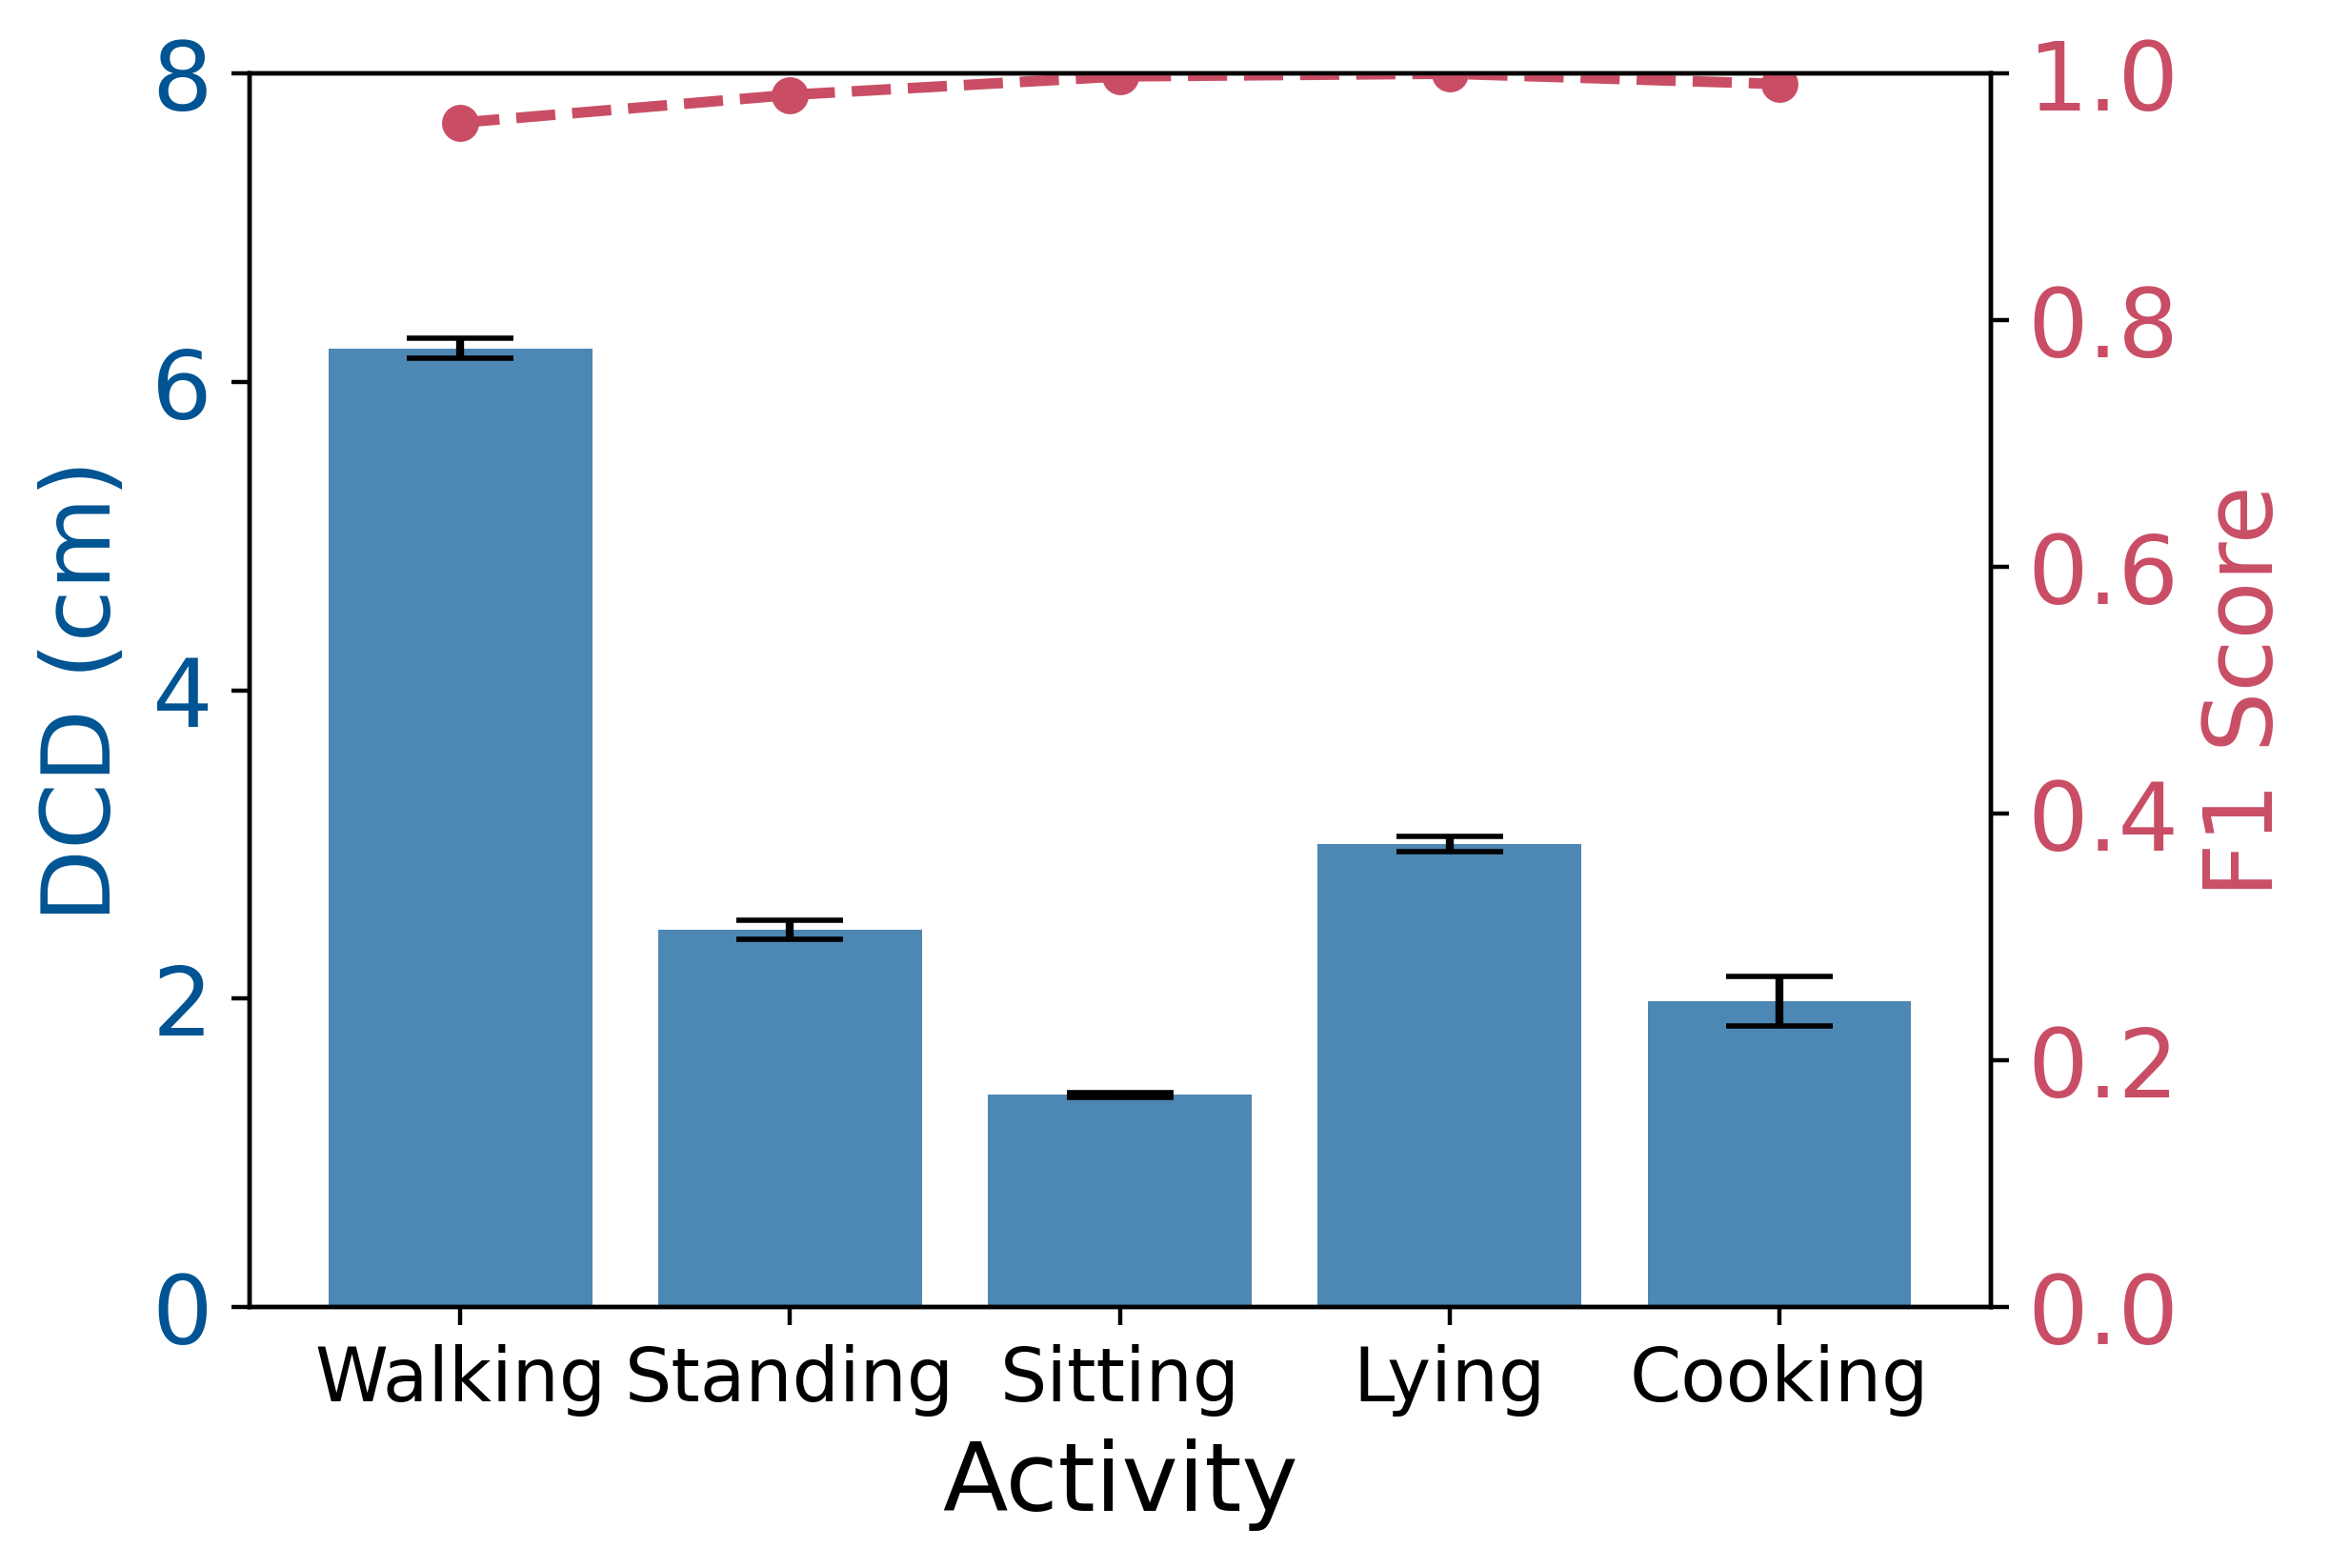

In [24]:
selected_recordings = [
    'U0_E0_1_walking_1o3_none_3',
    'U0_E0_1_walking_1o3_none_5',
    'U0_E0_1_walking_0o7_OLBP-0_1',
    'U0_E0_1_walking_1o3_none_5',

    'U2_E0_1_sitting_1o3_none_2',
    'U2_E2_1_sitting_1o3_none_1',
    'U4_E0_1_sitting_1o3_none_0',
    'U7_E2_1_sitting_1o3_none_1',

    'U0_E0_1_standing_1o3_none_1',
    'U0_E4_1_standing_1o2_AI-ST_0',
    'U0_E4_1_standing_1o2_AI-SC_0',
    'U1_E0_1_standing_1o3_none_2',
    'U1_E0_1_standing_1o3_none_3',
    'U3_E0_1_standing_1o3_none_0',
    'U3_E0_1_standing_1o3_none_1',

    'U9_E2_1_lying_1o3_none_1',
    'U9_E2_1_lying_1o3_none_3',
    'U8_E2_1_lying_1o3_none_2',

    'U0_E7_1_cooking_1o0_AI-CC_2',
    'U0_E7_1_cooking_1o0_AI-CC_3',
    'U0_E7_1_cooking_1o0_AI-CT_5',
    'U0_E7_1_cooking_1o0_AI-CT_7',
  
]

for i in range(len(selected_recordings)):
    selected_recordings[i] = selected_recordings[i] + '.pkl'

for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)

metrics_df = load_metrics_df_0(TAP3D_Log_folder_path, selected_recordings)

# Get activity distribution
activity_counts = selected_metrics_df['activity_id'].value_counts().sort_index()
activity_names = {
    0: 'Walking',
    1: 'Standing',
    2: 'Sitting',
    3: 'Lying',
    4: 'Cooking'
}

# Map activity IDs to names for better readability
activity_labels = [activity_names.get(act_id, f'Activity {act_id}') for act_id in activity_counts.index]

# Group by activity_id and calculate metrics for each activity
metrics = selected_metrics_df.groupby('activity_id').apply(
    lambda x: pd.Series({
        'activity_id': x['activity_id'].iloc[0],
        'true_positives': x['true_positives'].sum(),
        'false_positives': x['false_positives'].sum(),
        'false_negatives': x['false_negatives'].sum(),
        'chamfer_distance': x['chamfer_distance'].mean(),
        'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
        'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    })
).reset_index(drop=True)
metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])


df = metrics.copy()

# print(df)

df_plot   = df
# print(df_plot)

x_labels = [activity_names.get(act_id, f'Activity {act_id}') for act_id in activity_counts.index]
x = np.arange(len(x_labels))

# Optional error bars if present
cd_err = df_plot['One_directional_Chamfer_Distance_sem'] if 'One_directional_Chamfer_Distance_sem' in df_plot.columns else None
f1_err = df_plot['f1_sem'] if 'f1_sem' in df_plot.columns else None

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    df_plot['One_directional_Chamfer_Distance'],
    yerr=cd_err,
    # error_kw=dict(lw=9),  # Set error bar line width
    capsize=10 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')

print('One_directional_Chamfer_Distance: ', df_plot['One_directional_Chamfer_Distance'])
# Set a sensible y-limit
if df_plot['One_directional_Chamfer_Distance'].notna().any():
    ymax = float(np.nanmax(df_plot['One_directional_Chamfer_Distance'])) * 1.15
    ax1.set_ylim(0, 8)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    df_plot['f1_score'],
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)
if f1_err is not None:
    ax2.fill_between(x, df_plot['f1_score'] - f1_err, df_plot['f1_score'] + f1_err, alpha=0.15)
ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0, 1.0)

print('f1_score: ', df_plot['f1_score'])

# --- X ticks & label coloring ---
ax1.set_xlabel('Activity')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=14)
print('x_labels: ', x_labels)
plt.show()

### Figure 15: Impact of clothing

direct_chamfer_distance_list:  [np.float64(2.272143416172112), np.float64(2.3034282059209428), np.float64(1.863610957935333), np.float64(2.5425703917931632), np.float64(2.416723957974046), np.float64(1.977787599602029), np.float64(2.7129554978234)]
f1_score_list:  [np.float64(0.9795081967213115), np.float64(0.9711934156378601), np.float64(0.9970845481049563), np.float64(0.9940828402366864), np.float64(0.999000999000999), np.float64(0.9970559371933267), np.float64(0.9865005192107996)]
x_labels:  ['Coat+Hat', 'Jacket+Hat', 'Coat+Mask', 'Shirt', 'Coat', 'Jacket', 'T-shirt']


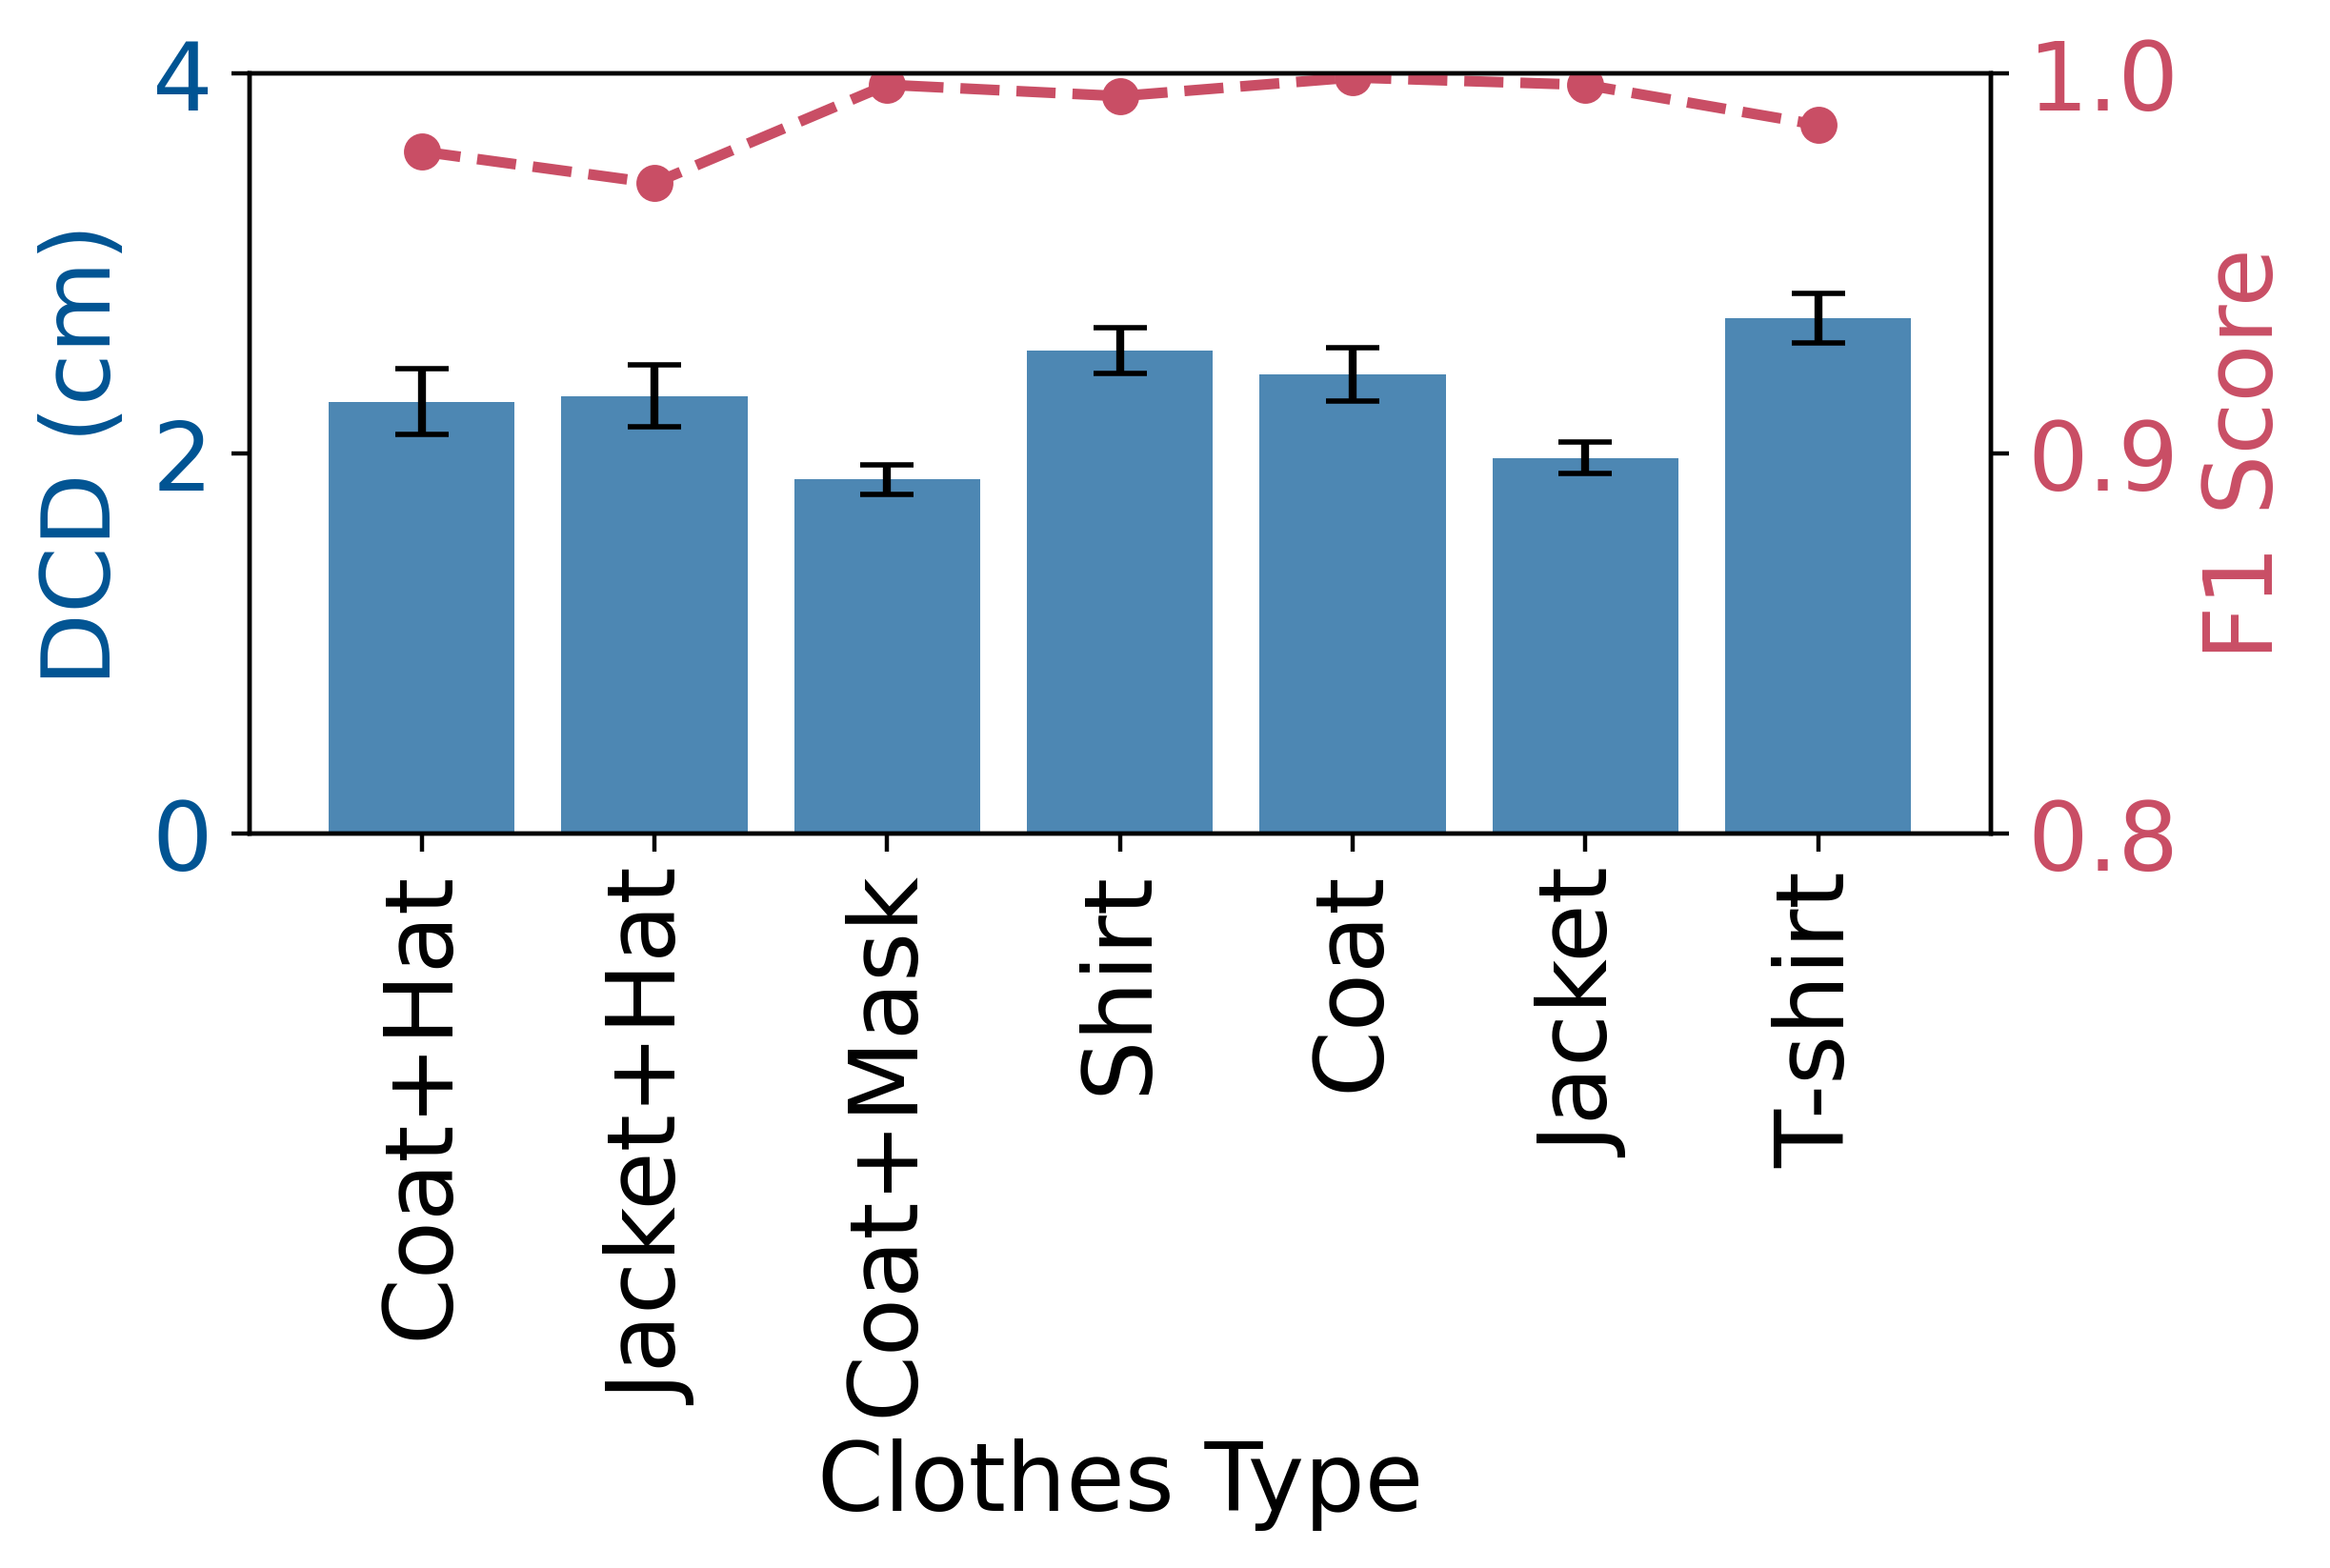

In [27]:
clothes_CH_file_list = [
  'U0_E3_1_walking_1o0_HMG-CH_1.pkl', #coat-hat
]
clothes_DH_file_list = [
  'U0_E3_1_walking_1o0_HMG-DH_2.pkl', #down jacket-hat
]
clothes_M_file_list = [
  'U0_E3_1_walking_1o0_HMG-M_1.pkl', #coat-mask
]
clothes_S_file_list = [
  'U0_E7_1_walking_1o0_C-S_3.pkl', #shirt
]
clothes_C_file_list = [
  'U0_E3_1_walking_1o0_C-C_2.pkl', #coat
]
clothes_D_file_list = [
  'U0_E3_1_walking_1o0_C-D_1.pkl', #down jacket
]
clothes_T_file_list = [
  'U0_E3_1_walking_1o0_C-T_2.pkl', #T-shirt 
]

selected_recordings = clothes_CH_file_list + clothes_DH_file_list + clothes_M_file_list + clothes_S_file_list + clothes_C_file_list + clothes_D_file_list + clothes_T_file_list

    
for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)
        
clothes_dict = {
    'Coat+Hat': load_metrics_df_0(TAP3D_Log_folder_path, clothes_CH_file_list),
    'Jacket+Hat': load_metrics_df_0(TAP3D_Log_folder_path, clothes_DH_file_list),
    'Coat+Mask': load_metrics_df_0(TAP3D_Log_folder_path, clothes_M_file_list),
    'Shirt': load_metrics_df_0(TAP3D_Log_folder_path, clothes_S_file_list),
    'Coat': load_metrics_df_0(TAP3D_Log_folder_path, clothes_C_file_list),
    'Jacket': load_metrics_df_0(TAP3D_Log_folder_path, clothes_D_file_list),
    'T-shirt': load_metrics_df_0(TAP3D_Log_folder_path, clothes_T_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in clothes_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())


x_labels = [key for key in clothes_dict.keys()]
x = np.arange(len(x_labels))

# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=5 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493', ha='center')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 4)

print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.8, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('Clothes Type')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=90, ha='center')

plt.show()

### Figure 16: Impact of the occlusion.

direct_chamfer_distance_list:  [np.float64(1.407261748110299), np.float64(1.1136553967690448), np.float64(1.540396158719445), np.float64(1.2927528908959798), np.float64(2.232228311769957)]
f1_score_list:  [np.float64(1.0), np.float64(0.9995121951219512), np.float64(0.9985308521057786), np.float64(1.0), np.float64(0.9889678956306187)]
x_labels:  ['0', '20', '40', '60', '80']


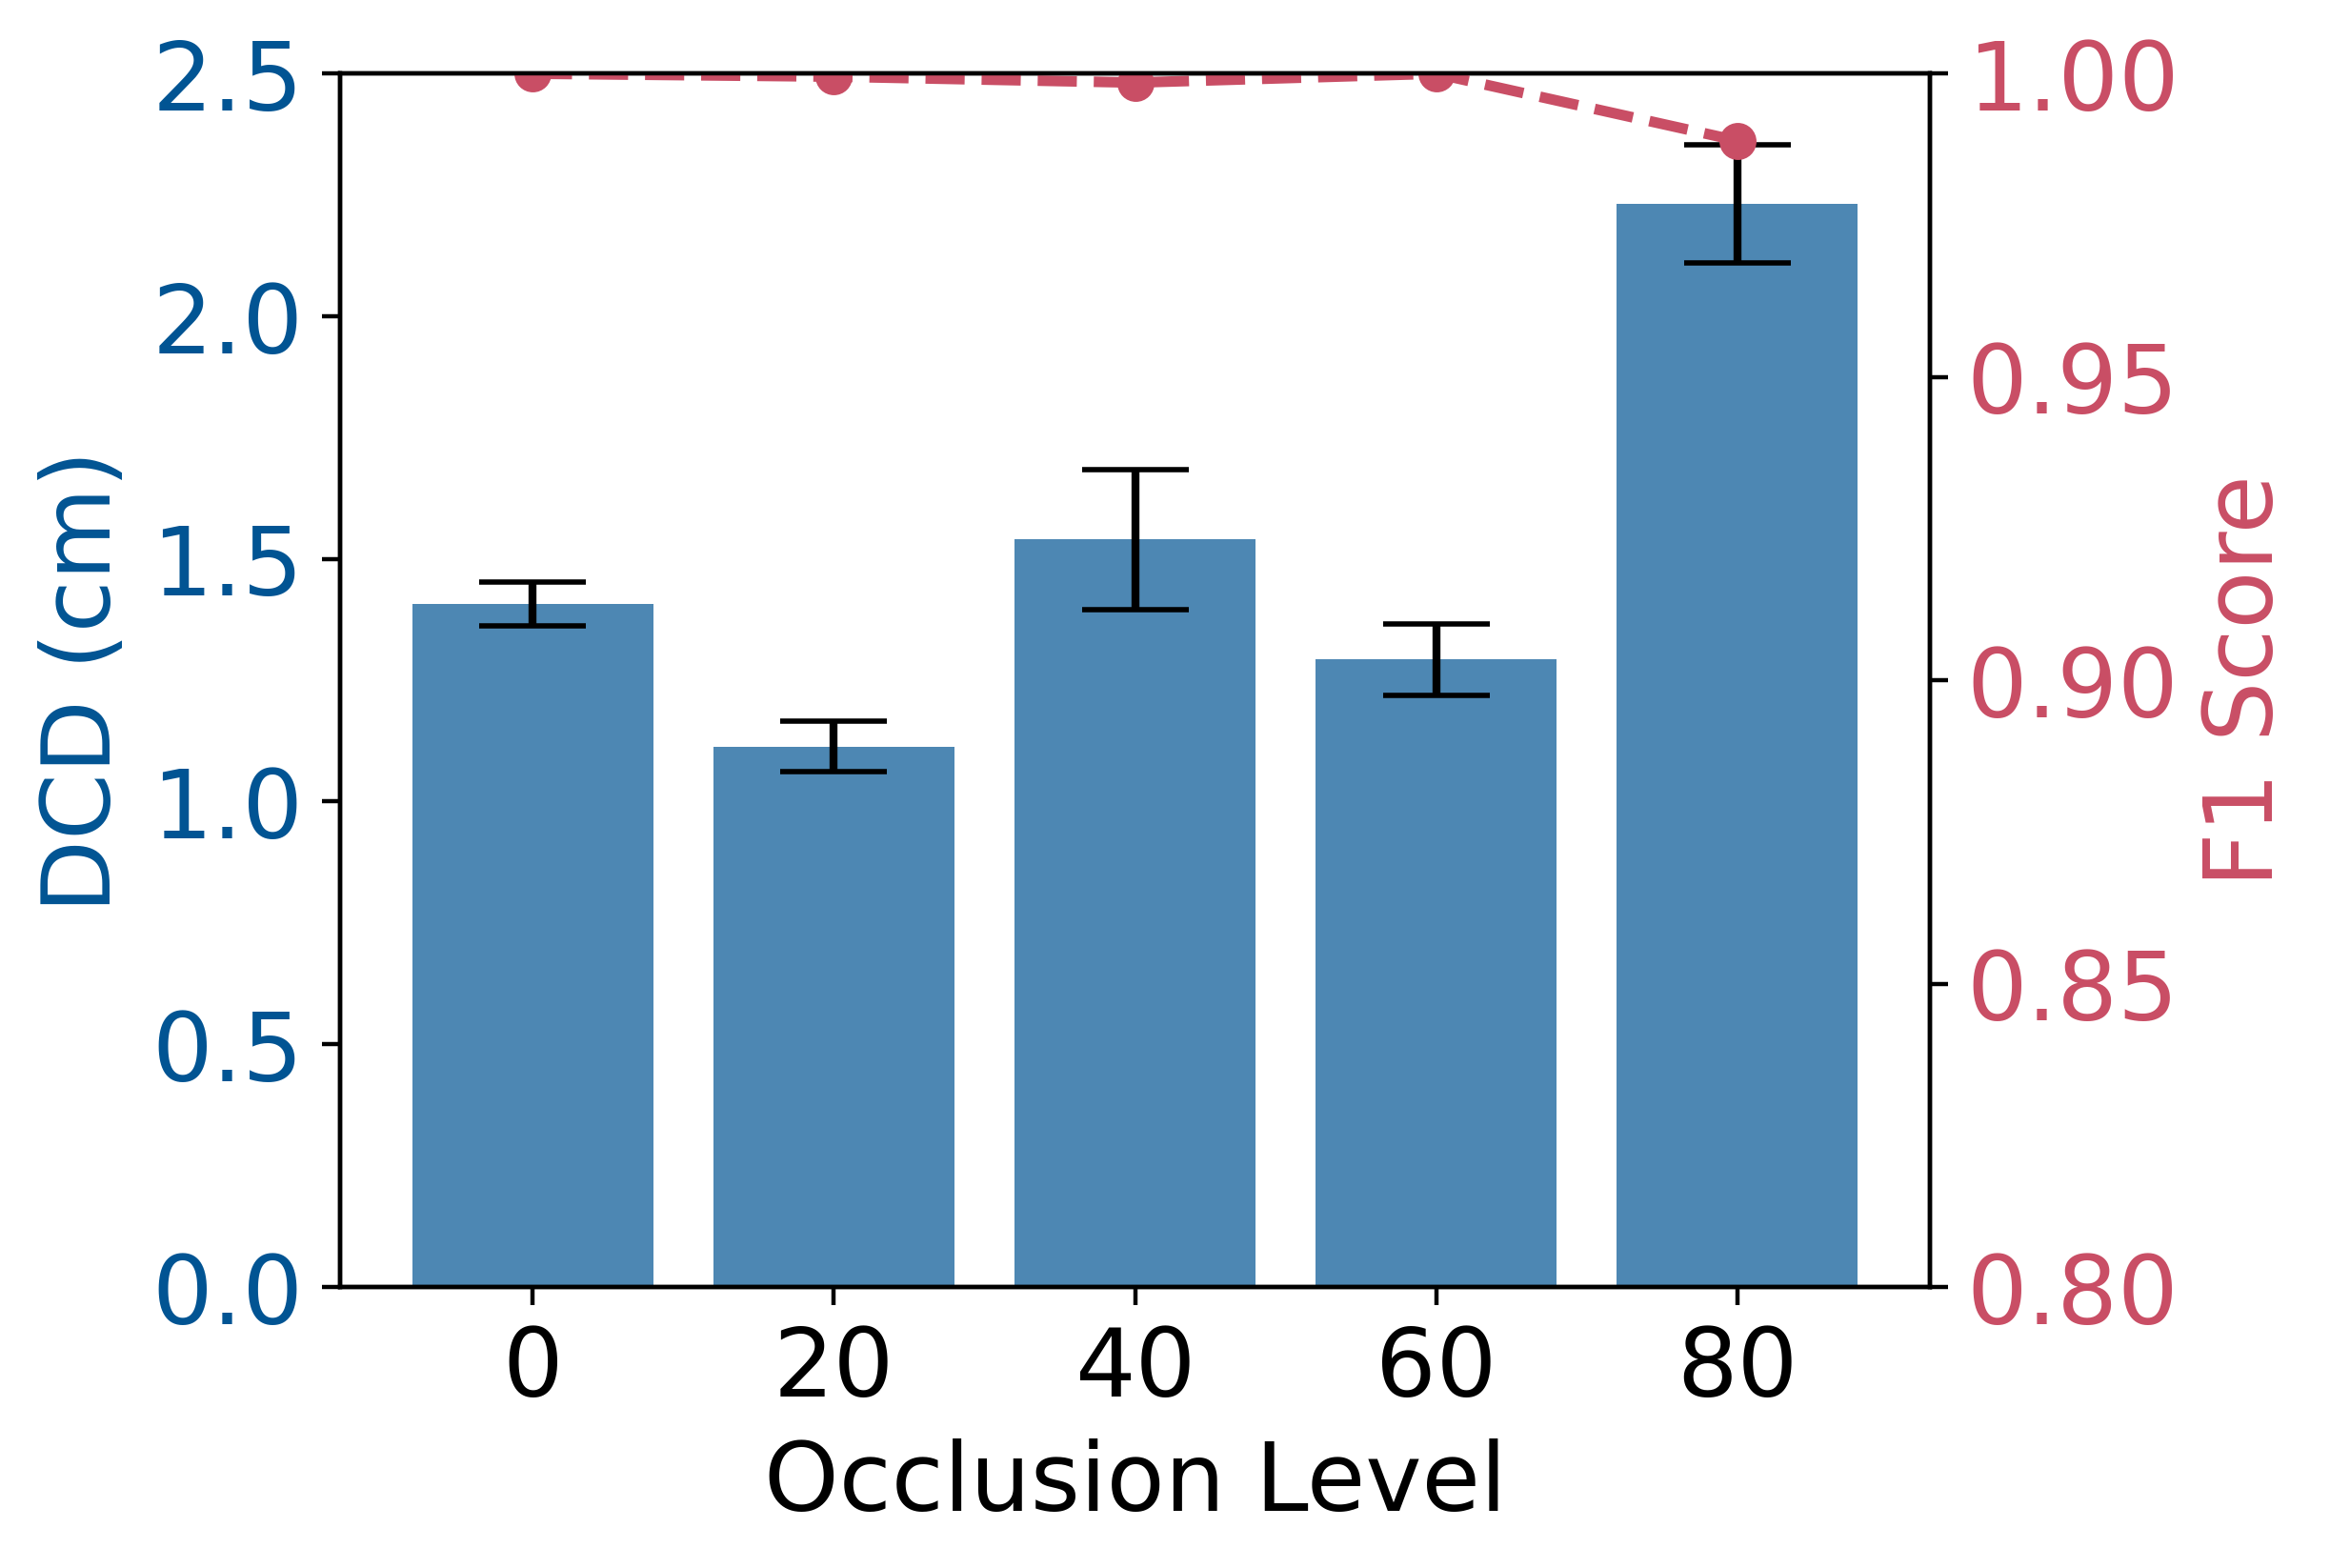

In [28]:
occlusion_0_file_list = [   
'U0_E11_1_walking_1o3_OLBP-0_2.pkl',
]
occlusion_20_file_list = [
'U0_E11_1_walking_1o3_OLBP-20_2.pkl',
'U0_E11_1_walking_1o3_OLBP-20_3.pkl',
]

occlusion_40_file_list = [
'U0_E11_1_walking_1o3_OLBP-40_2.pkl',
'U0_E11_1_walking_1o3_OLBP-40_3.pkl',
]

occlusion_60_file_list = [
'U0_E11_1_walking_1o3_OLBP-60_3.pkl',
'U0_E11_1_walking_1o3_OLBP-60_4.pkl',
]

occlusion_80_file_list = [
'U0_E11_1_walking_1o3_OLBP-80_3.pkl',
'U0_E11_1_walking_1o3_OLBP-80_4.pkl',
]

selected_recordings = occlusion_0_file_list + occlusion_20_file_list + occlusion_40_file_list + occlusion_60_file_list + occlusion_80_file_list

    
for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)
        

occlusion_dict = {
    '0': load_metrics_df_0(TAP3D_Log_folder_path, occlusion_0_file_list),
    '20': load_metrics_df_0(TAP3D_Log_folder_path, occlusion_20_file_list),
    '40': load_metrics_df_0(TAP3D_Log_folder_path, occlusion_40_file_list),
    '60': load_metrics_df_0(TAP3D_Log_folder_path, occlusion_60_file_list),
    '80': load_metrics_df_0(TAP3D_Log_folder_path, occlusion_80_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in occlusion_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())


x_labels = [key for key in occlusion_dict.keys()]
x = np.arange(len(x_labels))


# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=10 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 2.5)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.8, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('Occlusion Level')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center')

print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

plt.show()

### Figure 17: Walking speed robustness.

direct_chamfer_distance_list:  [np.float64(1.7820826526498301), np.float64(1.3948291080034139), np.float64(1.4719058486085097), np.float64(1.7482665619836704)]
f1_score_list:  [np.float64(0.9985163175687586), np.float64(1.0), np.float64(0.9995024875621891), np.float64(0.9995073891625617)]
x_labels:  ['0', '1', '2', '3']


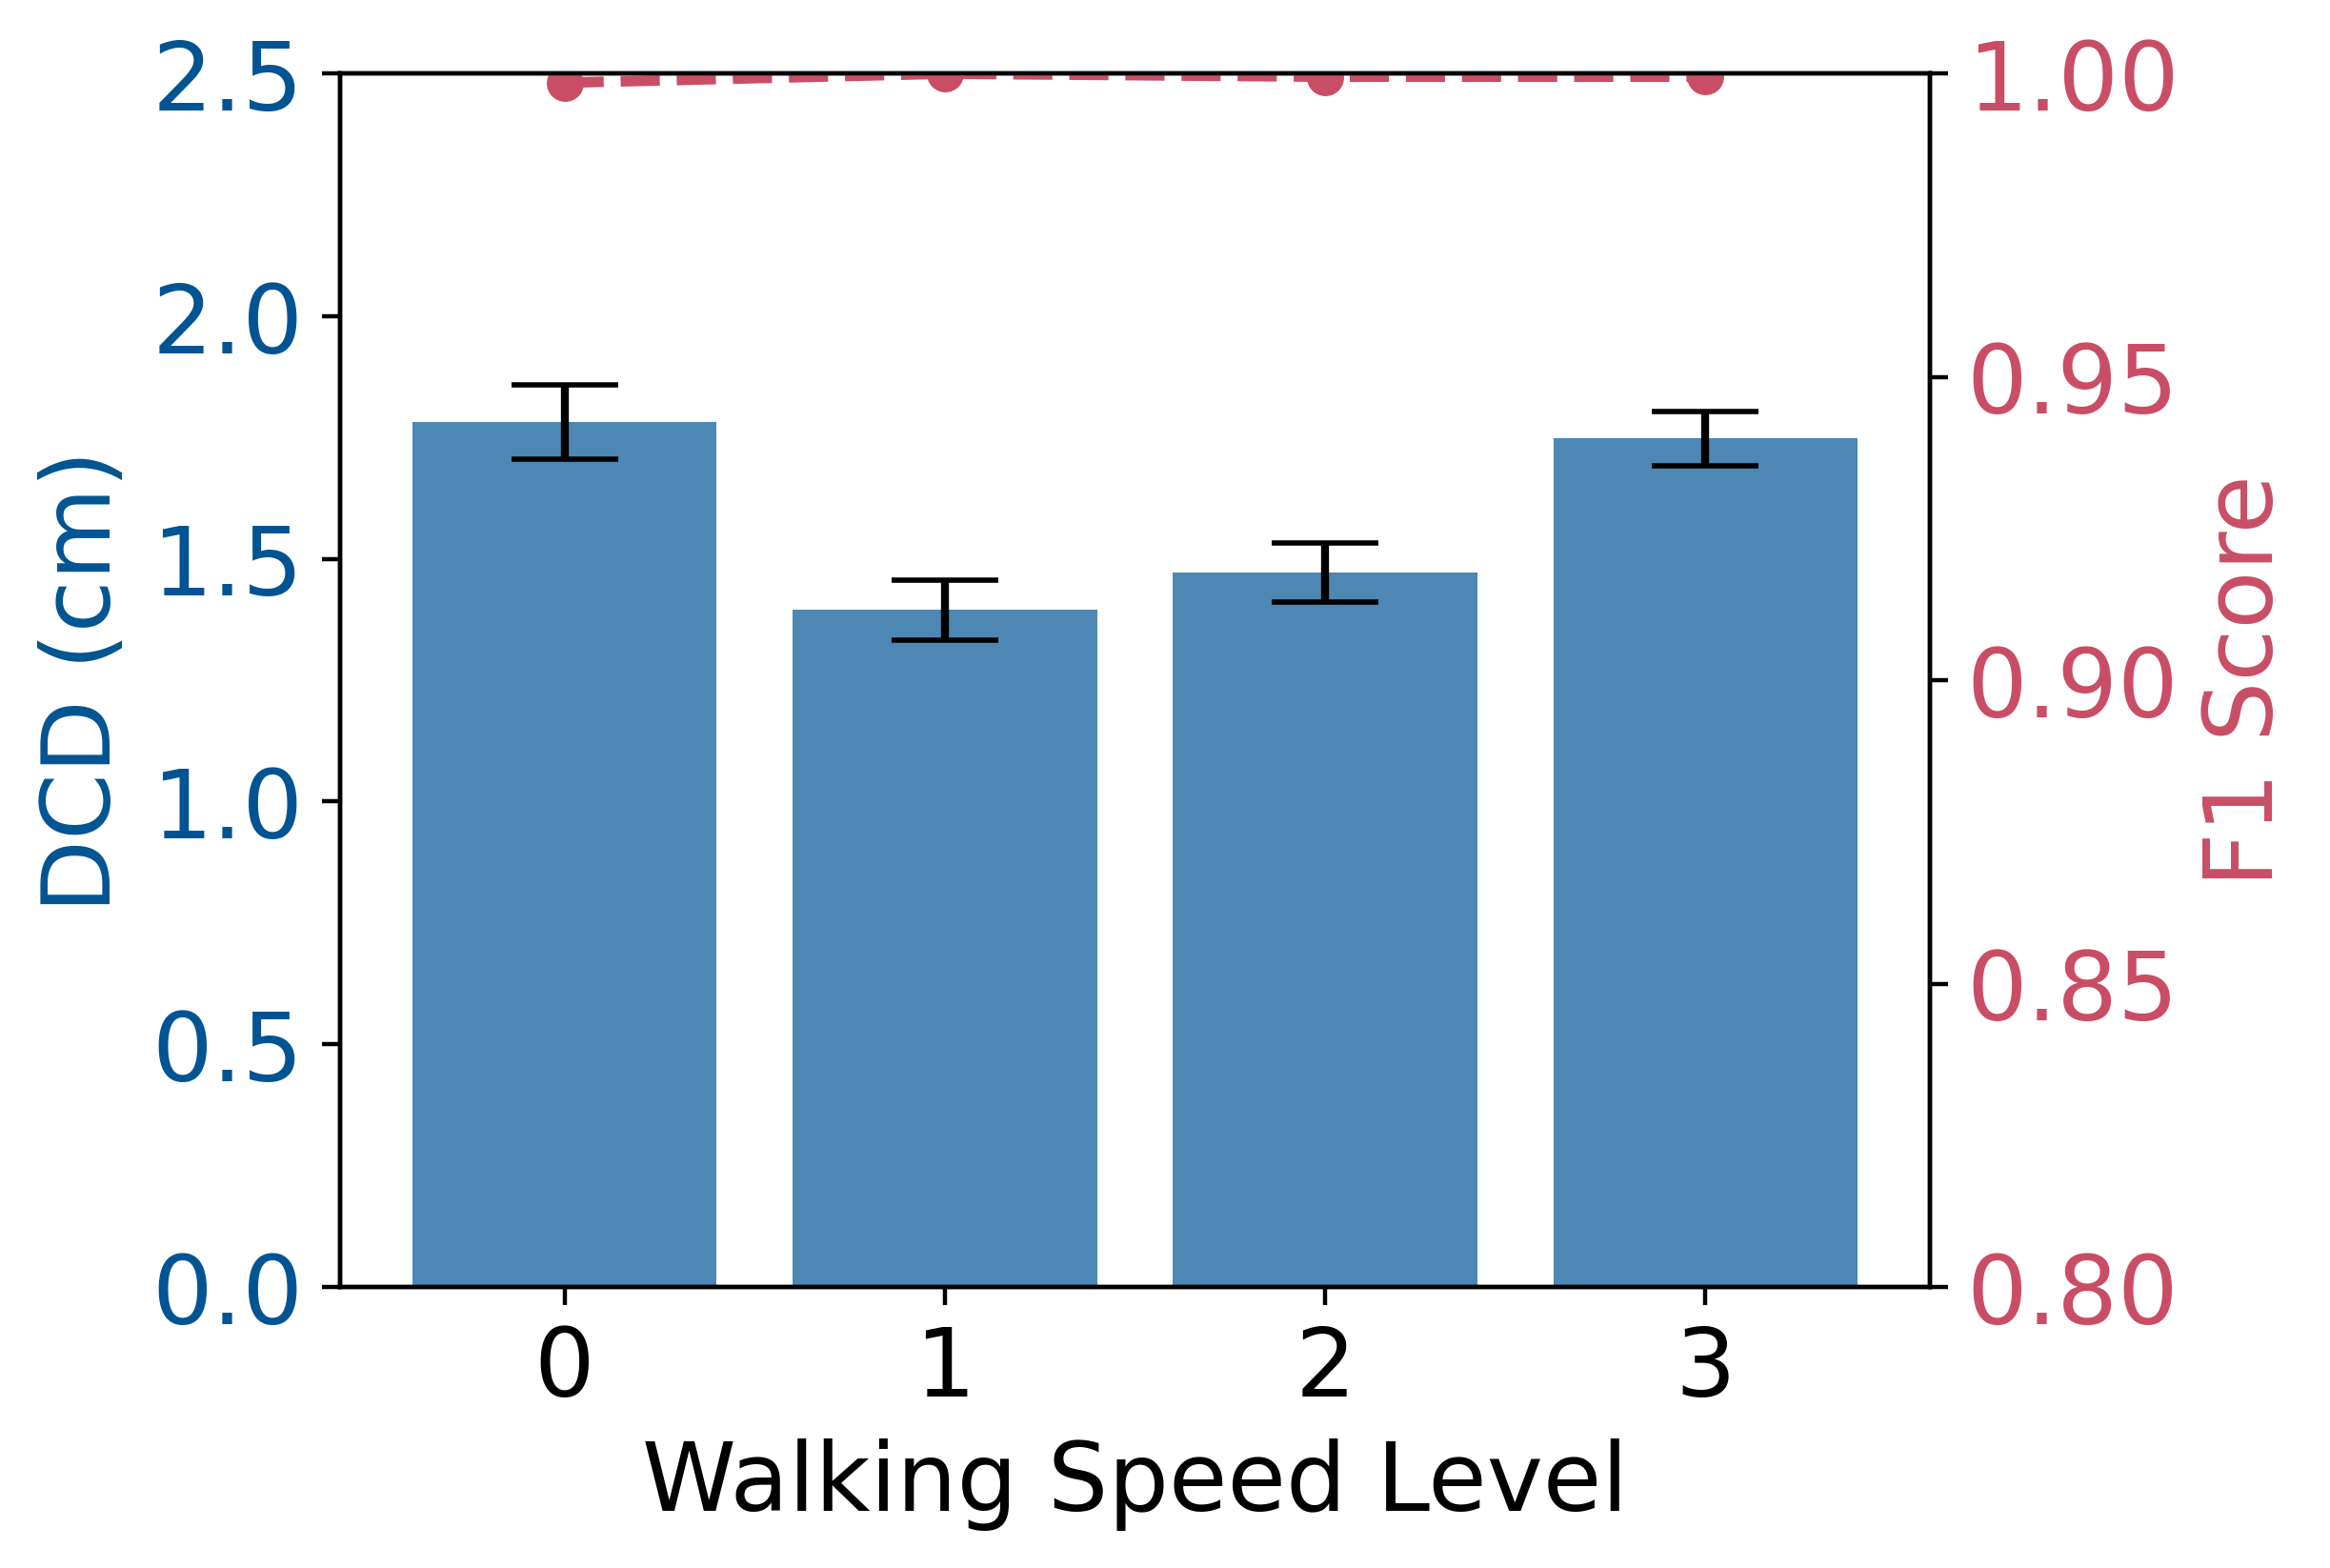

In [30]:
walking_speed_0_file_list = [
  'U0_E3_1_walking_1o0_WS-0_1.pkl',
  'U0_E3_1_walking_1o0_WS-0_2.pkl',
]

walking_speed_1_file_list = [
  'U0_E3_1_walking_1o0_WS-1_1.pkl',
  'U0_E3_1_walking_1o0_WS-1_2.pkl',
]

walking_speed_2_file_list = [
  'U0_E3_1_walking_1o0_WS-2_1.pkl',
  'U0_E3_1_walking_1o0_WS-2_2.pkl',
]

walking_speed_3_file_list = [
  'U0_E3_1_walking_1o0_WS-3_1.pkl',
  'U0_E3_1_walking_1o0_WS-3_2.pkl',
]

selected_recordings = walking_speed_0_file_list + walking_speed_1_file_list + walking_speed_2_file_list + walking_speed_3_file_list

for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)
        

walking_speed_dict = {
    '0': load_metrics_df_0(TAP3D_Log_folder_path, walking_speed_0_file_list),
    '1': load_metrics_df_0(TAP3D_Log_folder_path, walking_speed_1_file_list),
    '2': load_metrics_df_0(TAP3D_Log_folder_path, walking_speed_2_file_list),
    '3': load_metrics_df_0(TAP3D_Log_folder_path, walking_speed_3_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in walking_speed_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())

x_labels = [key for key in walking_speed_dict.keys()]
x = np.arange(len(x_labels))

# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=10 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 2.5)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.8, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('Walking Speed Level')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center')

print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

plt.show()

### Figure 18: Incident angle impact.

direct_chamfer_distance_list:  [np.float64(1.3447817813584966), np.float64(1.317821568626277), np.float64(1.994391840219052), np.float64(4.68359853971088)]
f1_score_list:  [np.float64(1.0), np.float64(0.9970472440944882), np.float64(0.99800796812749), np.float64(0.9258799810856745)]
x_labels:  ['0°', '15°', '30°', '45°']


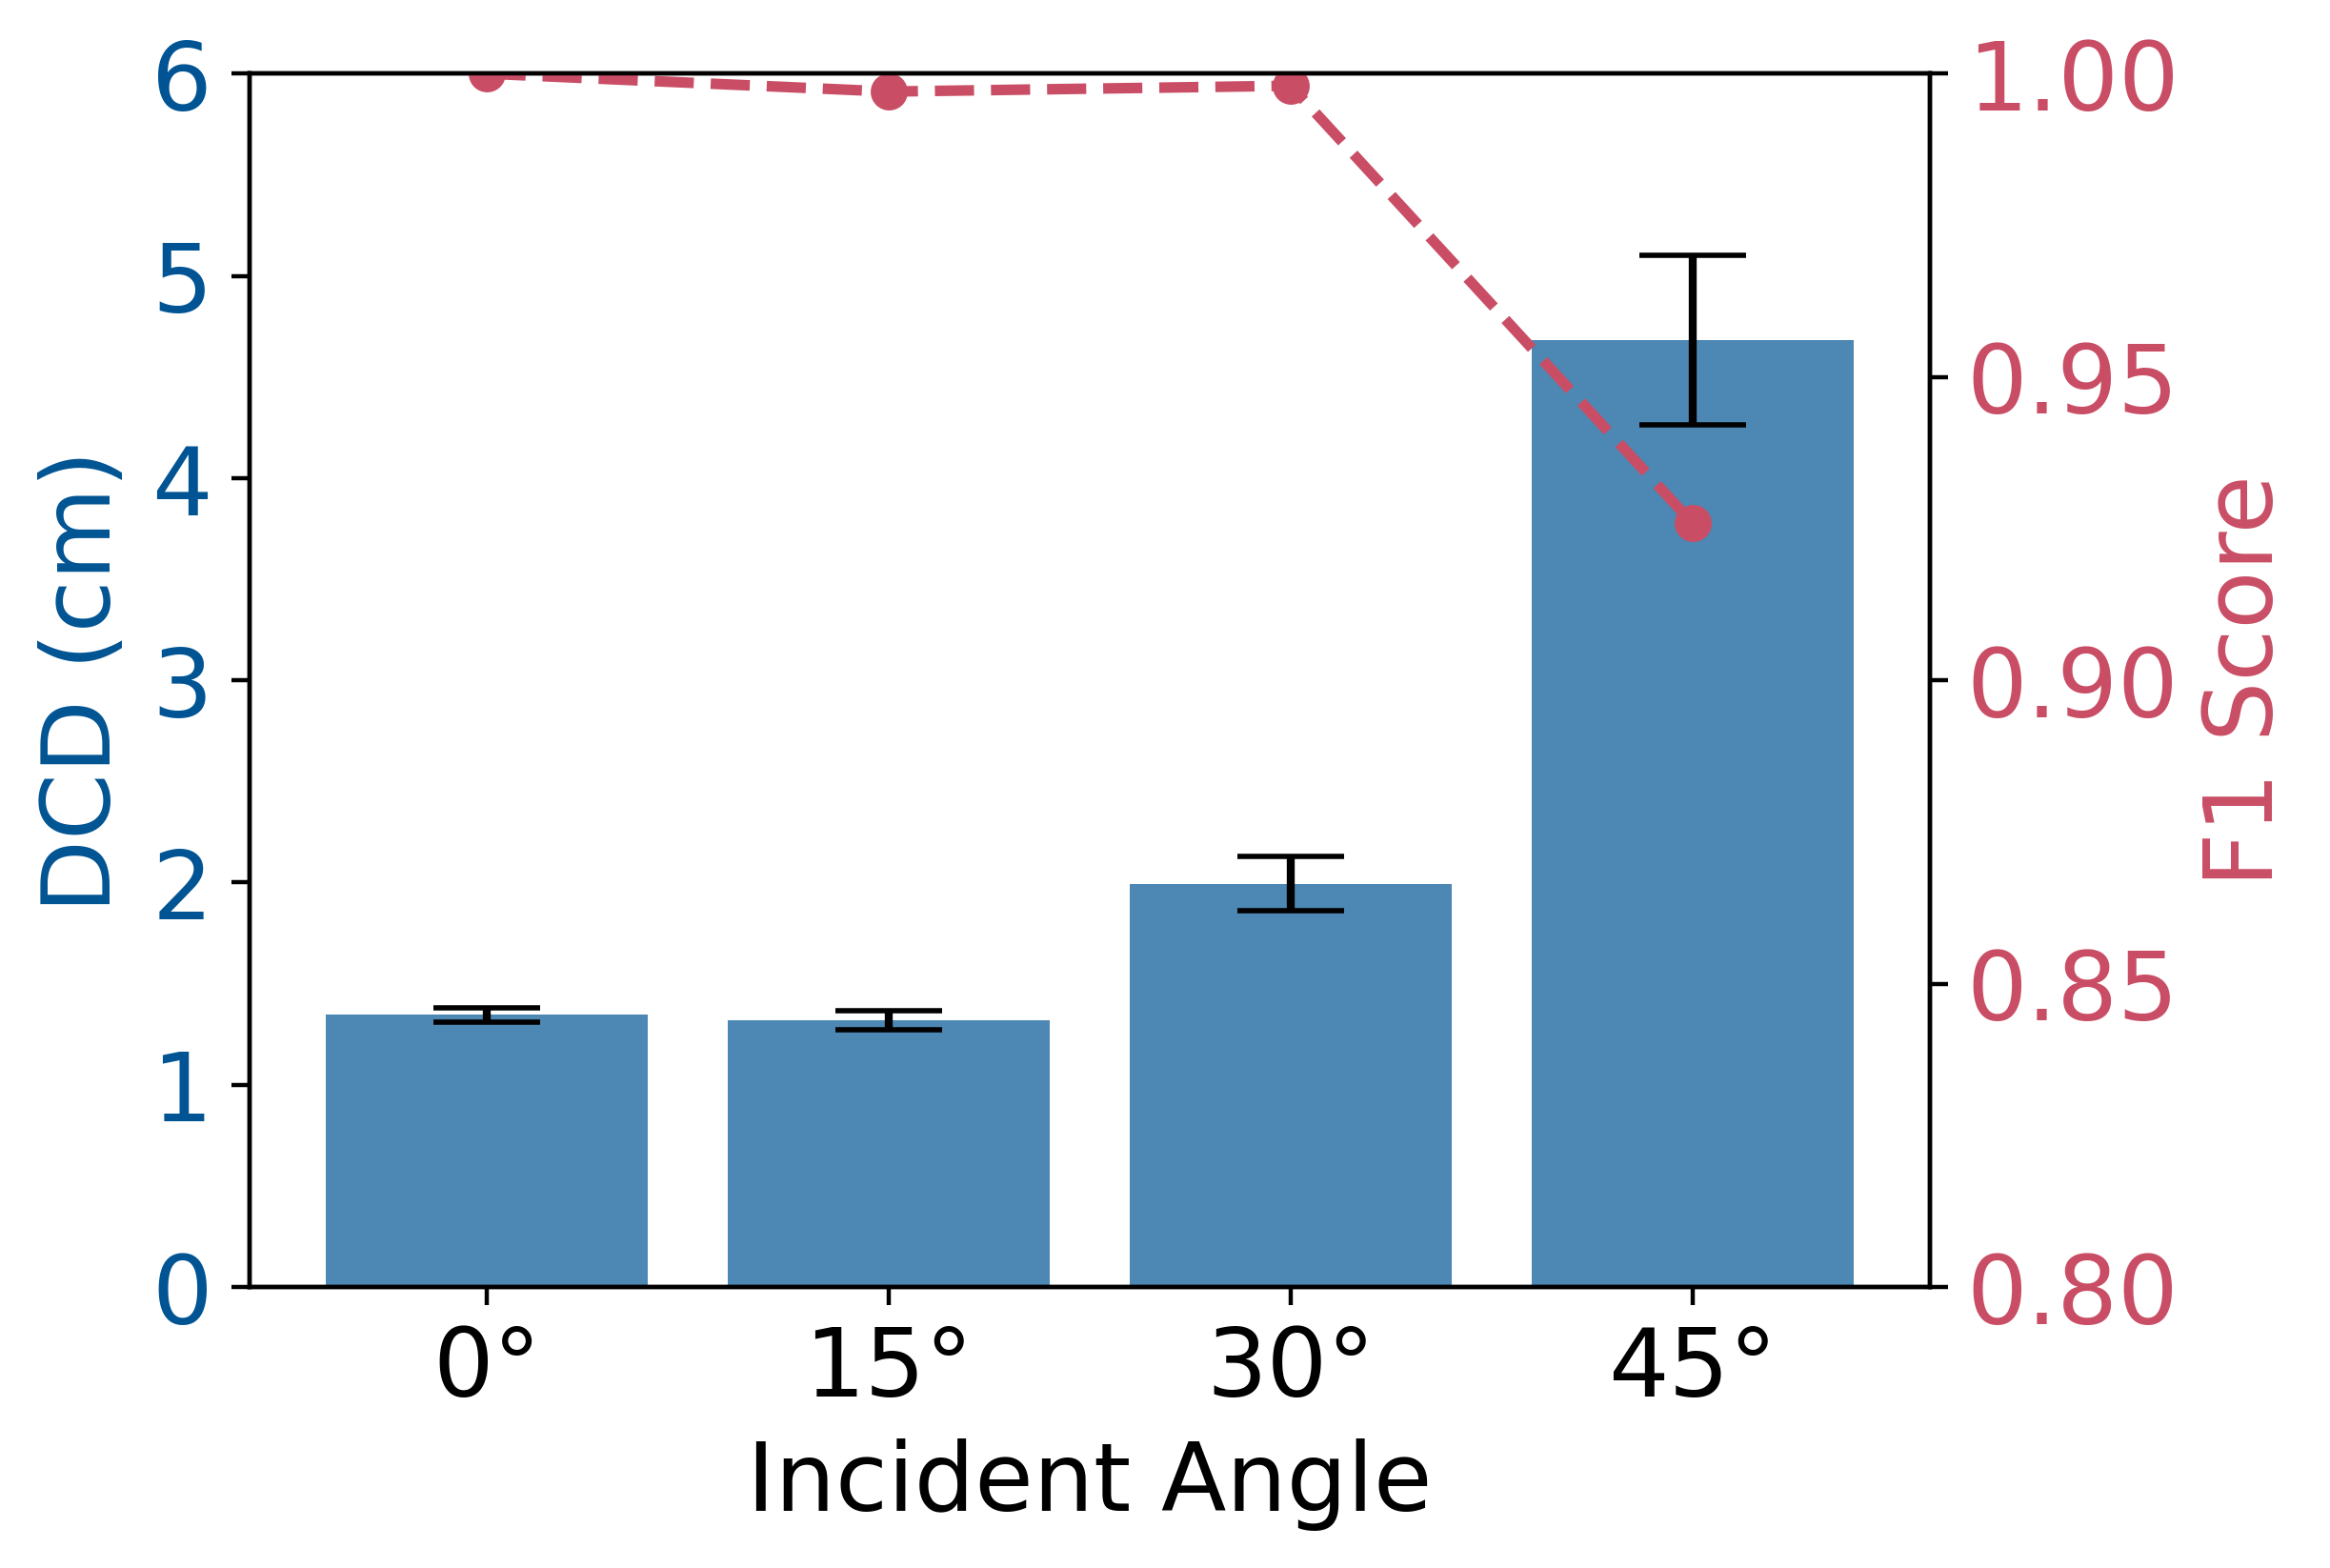

In [31]:
incident_angle_0_deg_file_list = [
  'U0_E7_1_walking_1o0_IA-0_2.pkl',
  'U1_E11_1_standing_1o3_IA-0_2.pkl',
 ]
incident_angle_15_deg_file_list = [
  'U0_E7_1_walking_1o0_IA-15_2.pkl',
    'U1_E11_1_standing_1o3_IA-15_2.pkl',
    ]
incident_angle_30_deg_file_list = [
  'U0_E7_1_walking_1o0_IA-30_1.pkl',
  'U1_E11_1_standing_1o3_IA-30_2.pkl',
    ]
incident_angle_45_deg_file_list = [

  'U0_E7_1_walking_1o0_IA-45_2.pkl',
  'U1_E11_1_standing_1o3_IA-45_0.pkl',
  'U1_E11_1_standing_1o3_IA-45_1.pkl',
    ]


selected_recordings = incident_angle_0_deg_file_list + incident_angle_15_deg_file_list + incident_angle_30_deg_file_list + incident_angle_45_deg_file_list

    
for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)
        

incident_angle_dict = {
    '0°': load_metrics_df_0(TAP3D_Log_folder_path, incident_angle_0_deg_file_list),
    '15°': load_metrics_df_0(TAP3D_Log_folder_path, incident_angle_15_deg_file_list),
    '30°': load_metrics_df_0(TAP3D_Log_folder_path, incident_angle_30_deg_file_list),
    '45°': load_metrics_df_0(TAP3D_Log_folder_path, incident_angle_45_deg_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in incident_angle_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())


x_labels = [key for key in incident_angle_dict.keys()]
x = np.arange(len(x_labels))


# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=10 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 6)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.8, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('Incident Angle')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center')

print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

plt.show()


### Figure 19: User orientation robustness.

direct_chamfer_distance_list:  [np.float64(1.08017833665753), np.float64(1.3775649202251834), np.float64(1.2243978585647606), np.float64(1.2432587817867196), np.float64(1.1258898504301258), np.float64(1.226585694751511), np.float64(1.1900908970558441)]
f1_score_list:  [np.float64(1.0), np.float64(0.9960552268244576), np.float64(0.9994686503719448), np.float64(0.994675701839303), np.float64(0.9946236559139785), np.float64(1.0), np.float64(0.9966052376333656)]
x_labels:  ['0°', '30°', '60°', '90°', '120°', '150°', '180°']


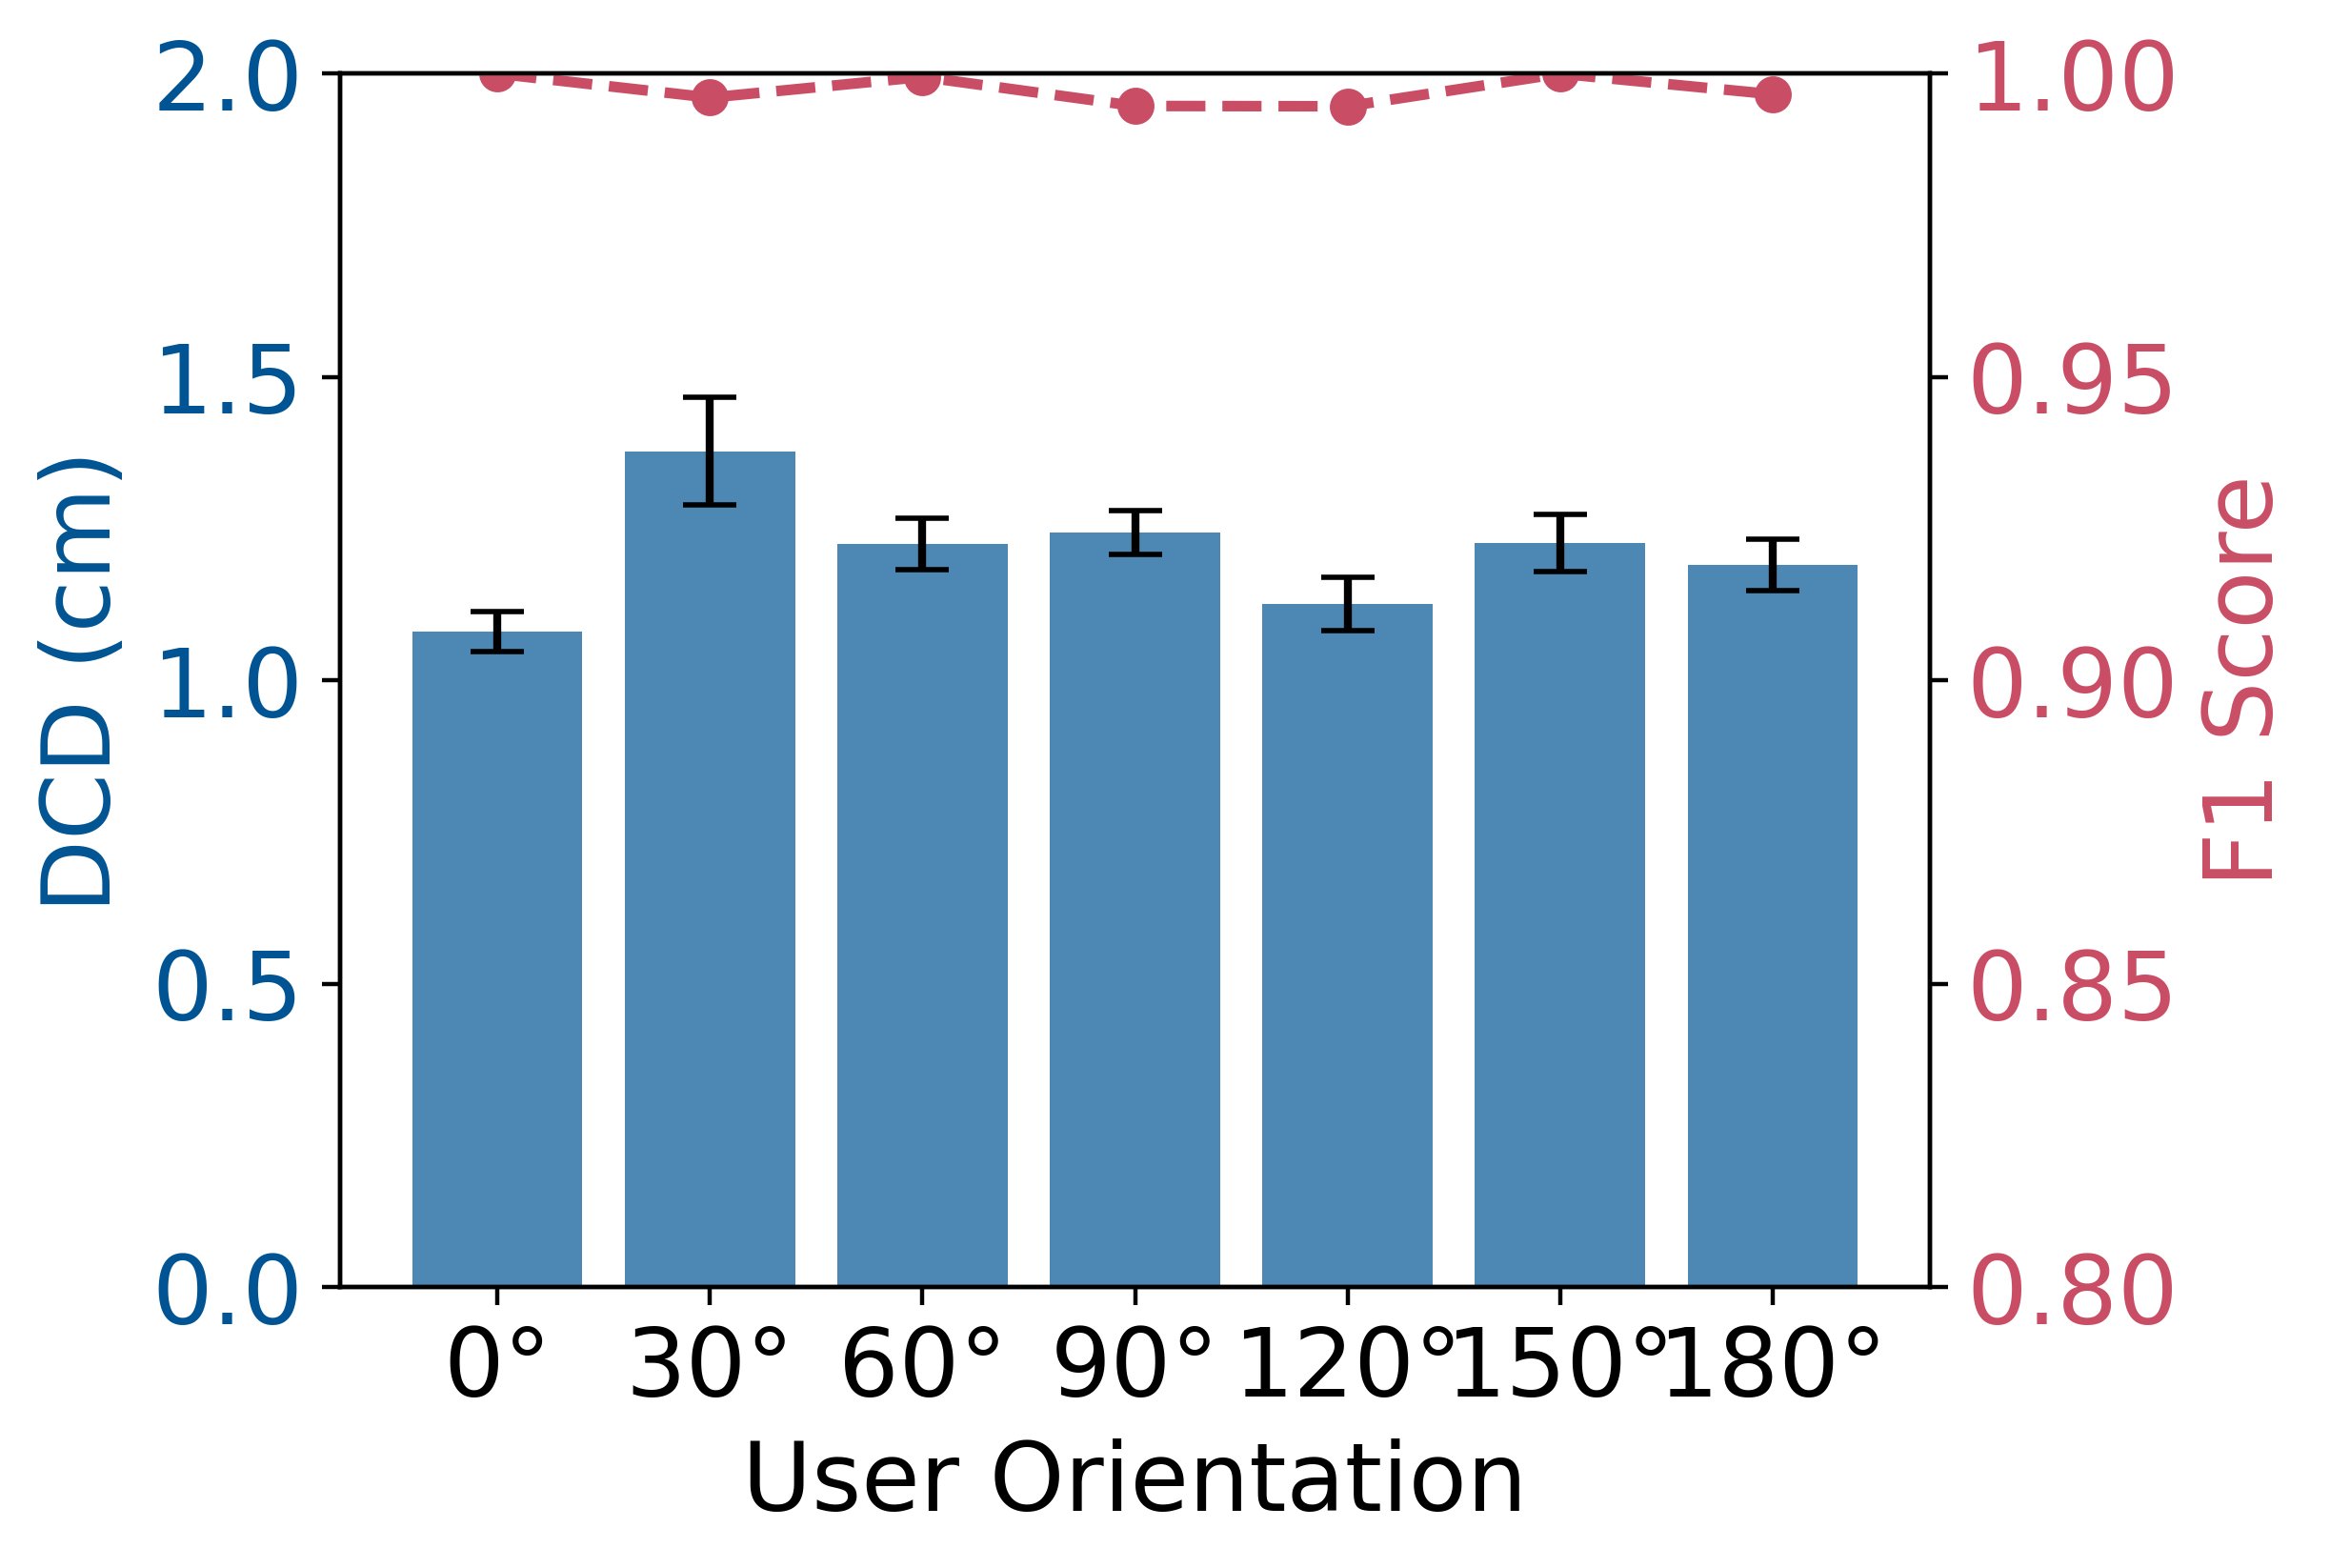

In [32]:
user_orientation_0_deg_file_list = [
  'U1_E11_1_standing_1o3_UO0_2.pkl',
 ]
user_orientation_30_deg_file_list = [
  'U0_E3_1_walking_1o0_UO30_2.pkl',
  'U1_E11_1_standing_1o3_UO30_2.pkl',
 ]
user_orientation_60_deg_file_list = [
  'U0_E3_1_walking_1o0_UO60_2.pkl',
  'U1_E11_1_standing_1o3_UO60_2.pkl',
 ]
user_orientation_90_deg_file_list = [
  'U0_E3_1_walking_1o0_UO90_2.pkl',
  'U1_E11_1_standing_1o3_UO90_2.pkl',
 ]
user_orientation_120_deg_file_list = [

  'U0_E3_1_walking_1o0_UO120_2.pkl',
  'U1_E11_1_standing_1o3_UO120_2.pkl',
 ]
user_orientation_150_deg_file_list = [
  'U0_E3_1_walking_1o0_UO150_2.pkl',
  'U1_E11_1_standing_1o3_UO150_2.pkl',
 ]
user_orientation_180_deg_file_list = [
  'U0_E3_1_walking_1o0_UO180_2.pkl',
  'U1_E11_1_standing_1o3_UO180_2.pkl',
 ]


selected_recordings = user_orientation_0_deg_file_list + user_orientation_30_deg_file_list + user_orientation_60_deg_file_list + user_orientation_90_deg_file_list + user_orientation_120_deg_file_list + user_orientation_150_deg_file_list + user_orientation_180_deg_file_list

    
for ele in selected_recordings:
    if ele not in file_names:
        print('not found', ele)
        

orientation_dict = {
    '0°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_0_deg_file_list),
    '30°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_30_deg_file_list),
    '60°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_60_deg_file_list),
    '90°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_90_deg_file_list),
    '120°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_120_deg_file_list),
    '150°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_150_deg_file_list),
    '180°': load_metrics_df_0(TAP3D_Log_folder_path, user_orientation_180_deg_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in orientation_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())


x_labels = [key for key in orientation_dict.keys()]
x = np.arange(len(x_labels))

# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=5 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 2)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.8, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('User Orientation')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center')


print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

plt.show()

### Figure 20: Temperature perturbation testing.


perturbation levels: ['-4', '-3', '-2', '-1', '0', '+1', '+2', '+3', '+4']
chamfer means: [4.344249691118627, 4.342725449394047, 4.334713032500519, 4.333568410335765, 4.335700508945683, 4.33970804294184, 4.348738848068819, 4.391702956226068, 4.454173865549954]
chamfer sems: [0.05959919341320762, 0.05955992361410822, 0.05870498225239639, 0.05873533022874549, 0.058786766437973176, 0.058813375750464775, 0.05893119416686278, 0.059943706599790814, 0.0612974981752763]
f1 means: [0.9694292052609663, 0.9695921584430622, 0.9696109294633048, 0.9696067117637628, 0.9695795940151343, 0.9695098574055411, 0.9694014996961458, 0.9686631396147227, 0.9676246320386228]


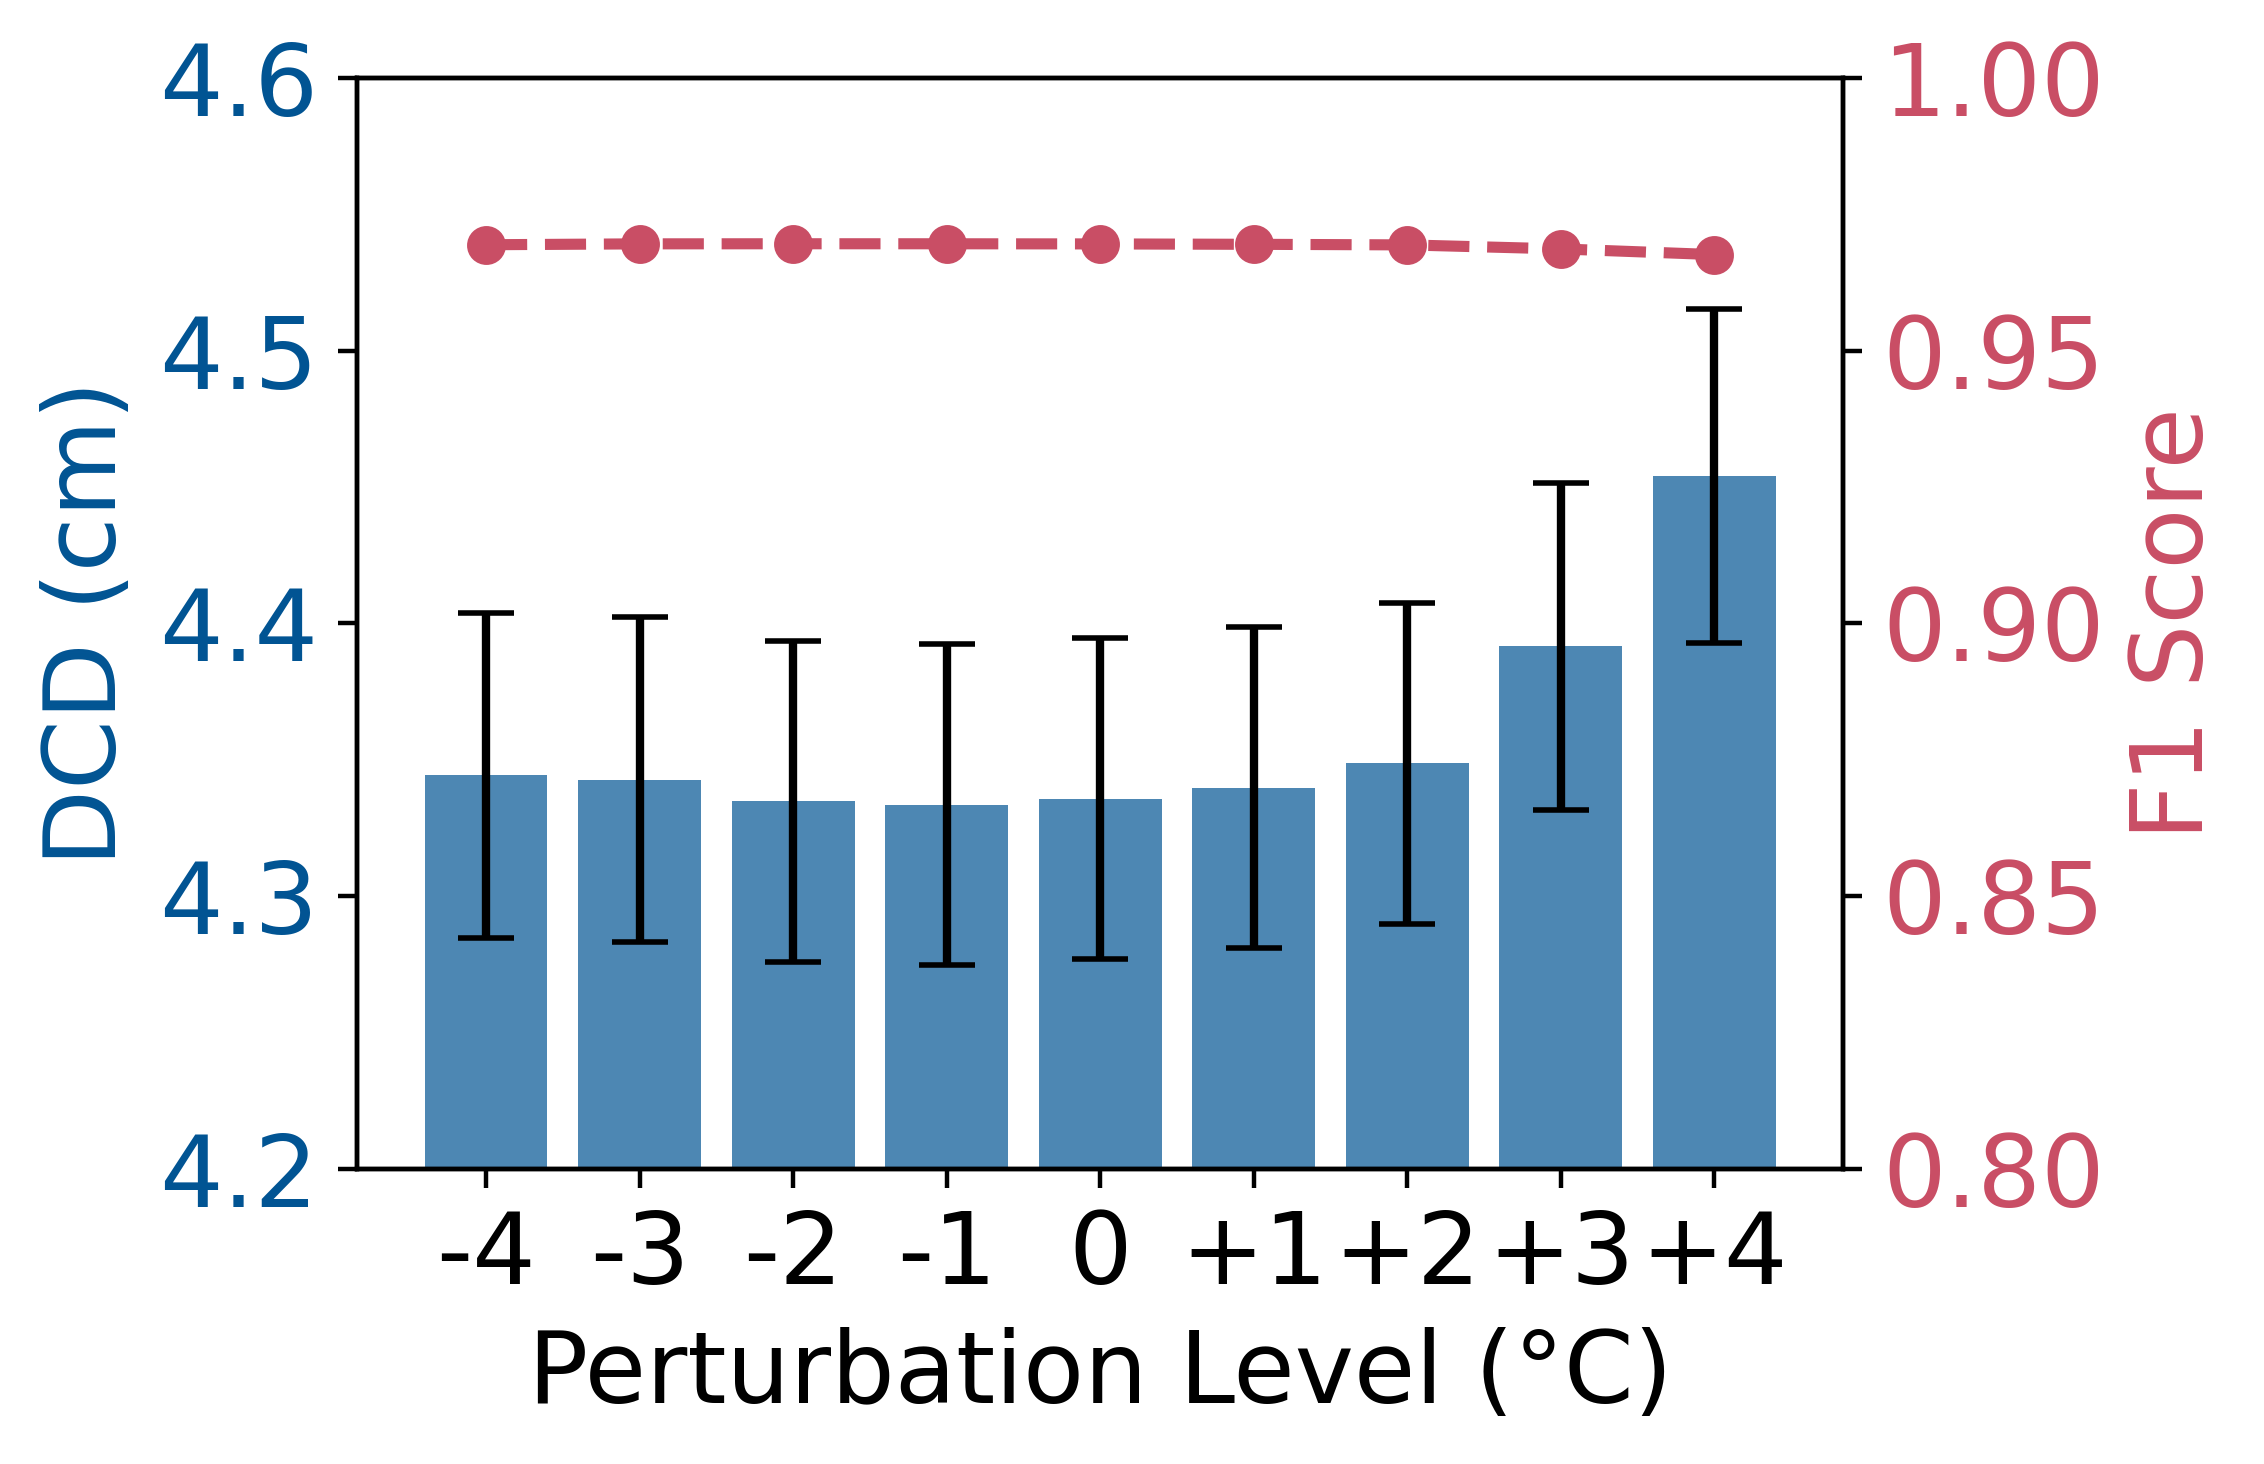

In [33]:
no_perturbation_folder_path = 'logs/m08/model3_m08_thermo_pt_1223164517_test/final_metric.pickle'
perturbation_1_folder_path = 'logs/m08/model3_m08_thermo_pt_1226111122_test_pertureb_1/final_metric.pickle'
perturbation_2_folder_path = 'logs/m08/model3_m08_thermo_pt_1226112512_test_pertureb_2/final_metric.pickle'
perturbation_3_folder_path = 'logs/m08/model3_m08_thermo_pt_1226113424_test_pertureb_3/final_metric.pickle'
perturbation_4_folder_path = 'logs/m08/model3_m08_thermo_pt_1226112529_test_pertureb_4/final_metric.pickle'

perturbation_minus_1_folder_path = 'logs/m08/model3_m08_thermo_pt_1226111839_test_pertureb_-1/final_metric.pickle'
perturbation_minus_2_folder_path = 'logs/m08/model3_m08_thermo_pt_1226113512_test_pertureb_-2/final_metric.pickle'
perturbation_minus_3_folder_path = 'logs/m08/model3_m08_thermo_pt_1226112550_test_pertureb_-3/final_metric.pickle'
perturbation_minus_4_folder_path = 'logs/m08/model3_m08_thermo_pt_1226113450_test_pertureb_-4/final_metric.pickle'

def get_the_measurement(log_path, file_names):
    selected_metrics_df = load_metrics_df_0(log_path, file_names)
    min_distance = 0
    max_distance = 6500 # mm
    # only consider the targets that are within the sensing range
    selected_metrics_df = selected_metrics_df[(selected_metrics_df['z_average'] >= min_distance) & (selected_metrics_df['z_average'] <= max_distance)]

    # bins=np.linspace(min_distance, max_distance, num_bins+1)
    bins = [0. , 3000. , 6500.]
    distance_bins = pd.cut(selected_metrics_df['z_average'], bins=bins, include_lowest=True)

    distance_metrics = selected_metrics_df.groupby(distance_bins, observed=False).apply(lambda x: pd.Series({
        'distance_range': f"{x['z_average'].min():.1f}-{x['z_average'].max():.1f}",
        'precision': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_positives'].sum()) if (x['true_positives'].sum() + x['false_positives'].sum()) > 0 else 0,
        'recall': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_negatives'].sum()) if (x['true_positives'].sum() + x['false_negatives'].sum()) > 0 else 0,
        'chamfer_distance': x['chamfer_distance'].mean(),
        'chamfer_distance_std': x['chamfer_distance'].std(),
        'chamfer_distance_sem': x['chamfer_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'hausdorff_distance': x['hausdorff_distance'].mean(),
        'hausdorff_distance_std': x['hausdorff_distance'].std(),
        'hausdorff_distance_sem': x['hausdorff_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'point2point_distance': (x['point2point_distance'] / 10).mean(), # unit is cm
        'point2point_distance_std': (x['point2point_distance'] / 10).std(),
        'point2point_distance_sem': (x['point2point_distance'] / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'sample_count': len(x),
        'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance']/2)/10).mean(), # unit is cm
        'One_directional_Chamfer_Distance_std': (np.sqrt(x['chamfer_distance']/2)/10).std(),
        'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance']/2)/10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    }))
    # Calculate F1 score
    distance_metrics['f1_score'] = 2 * (distance_metrics['precision'] * distance_metrics['recall']) / (distance_metrics['precision'] + distance_metrics['recall']) if (distance_metrics['precision'] + distance_metrics['recall']).all() > 0 else 0
    return distance_metrics['f1_score'].to_numpy(), distance_metrics['One_directional_Chamfer_Distance'].to_numpy(), distance_metrics['One_directional_Chamfer_Distance_sem'].to_numpy()


no_perturbation_f1_score, no_perturbation_One_directional_Chamfer_Distance, no_perturbation_One_directional_Chamfer_Distance_sem = get_the_measurement(no_perturbation_folder_path, file_names)
perturbation_1_f1_score, perturbation_1_One_directional_Chamfer_Distance, perturbation_1_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_1_folder_path, file_names)
perturbation_2_f1_score, perturbation_2_One_directional_Chamfer_Distance, perturbation_2_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_2_folder_path, file_names)
perturbation_3_f1_score, perturbation_3_One_directional_Chamfer_Distance, perturbation_3_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_3_folder_path, file_names)
perturbation_4_f1_score, perturbation_4_One_directional_Chamfer_Distance, perturbation_4_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_4_folder_path, file_names)
perturbation_minus_1_f1_score, perturbation_minus_1_One_directional_Chamfer_Distance, perturbation_minus_1_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_minus_1_folder_path, file_names)
perturbation_minus_2_f1_score, perturbation_minus_2_One_directional_Chamfer_Distance, perturbation_minus_2_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_minus_2_folder_path, file_names)
perturbation_minus_3_f1_score, perturbation_minus_3_One_directional_Chamfer_Distance, perturbation_minus_3_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_minus_3_folder_path, file_names)
perturbation_minus_4_f1_score, perturbation_minus_4_One_directional_Chamfer_Distance, perturbation_minus_4_One_directional_Chamfer_Distance_sem = get_the_measurement(perturbation_minus_4_folder_path, file_names)



chamfer_means = [
    np.mean(perturbation_minus_4_One_directional_Chamfer_Distance),
    np.mean(perturbation_minus_3_One_directional_Chamfer_Distance),
    np.mean(perturbation_minus_2_One_directional_Chamfer_Distance),
    np.mean(perturbation_minus_1_One_directional_Chamfer_Distance),
    np.mean(no_perturbation_One_directional_Chamfer_Distance),
    np.mean(perturbation_1_One_directional_Chamfer_Distance),
    np.mean(perturbation_2_One_directional_Chamfer_Distance),
    np.mean(perturbation_3_One_directional_Chamfer_Distance),
    np.mean(perturbation_4_One_directional_Chamfer_Distance)
]

chamfer_sems = [
    np.mean(perturbation_minus_4_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_minus_3_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_minus_2_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_minus_1_One_directional_Chamfer_Distance_sem),
    np.mean(no_perturbation_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_1_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_2_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_3_One_directional_Chamfer_Distance_sem),
    np.mean(perturbation_4_One_directional_Chamfer_Distance_sem)
]


f1_means = [
    np.mean(perturbation_minus_4_f1_score),
    np.mean(perturbation_minus_3_f1_score),
    np.mean(perturbation_minus_2_f1_score),
    np.mean(perturbation_minus_1_f1_score),
    np.mean(no_perturbation_f1_score),
    np.mean(perturbation_1_f1_score),
    np.mean(perturbation_2_f1_score),
    np.mean(perturbation_3_f1_score),
    np.mean(perturbation_4_f1_score)
]


x_labels = ['-4', '-3', '-2', '-1', '0', '+1', '+2', '+3', '+4']
plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize = (6,4),dpi=400, layout='constrained')

x = range(len(x_labels))

# Bar plot for Chamfer Distance Error (left y-axis)
bars = ax1.bar(
    x,
    chamfer_means,
    yerr=chamfer_sems,
    capsize=5,
    color='#015493',
    alpha=0.7,
    label="Directed Chamfer Distance"
)
ax1.set_ylim(4.2, 4.6)
ax1.set_xlabel('Perturbation Level (°C)')
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')

# Second y-axis for F1 score
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_means,
    color='#C94E65',
    marker='o',
    linestyle='--',
    linewidth=2,
    label="F1 Score"
)
ax2.set_ylim(0.8, 1)
ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')

# x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)

# Optional legend combining both plots
lines, labels = [], []
for ax in [ax1, ax2]:
    line, label = ax.get_legend_handles_labels()
    lines += line
    labels += label
plt.tight_layout()


print('perturbation levels:', x_labels)
print('chamfer means:', [float(ele) for ele in chamfer_means])
print('chamfer sems:', [float(ele) for ele in chamfer_sems])
print('f1 means:', [float(ele) for ele in f1_means])

### Figure 21: Room temperature robustness

direct_chamfer_distance_list:  [np.float64(2.9907549561046913), np.float64(4.661426465023258), np.float64(5.408127836592118), np.float64(3.9403328725600892), np.float64(4.248546152791403), np.float64(4.563323232059775)]
f1_score_list:  [np.float64(0.9418066653266761), np.float64(0.8674687539458321), np.float64(0.8623956593690224), np.float64(0.8664542631041826), np.float64(0.8095953632649645), np.float64(0.8227841943256285)]
x_labels:  ['20', '22', '24', '26', '28', '30']
the average DCD is:  4.302085252521889
the average F1 score is:  0.861750816556051
num_samples:  16187


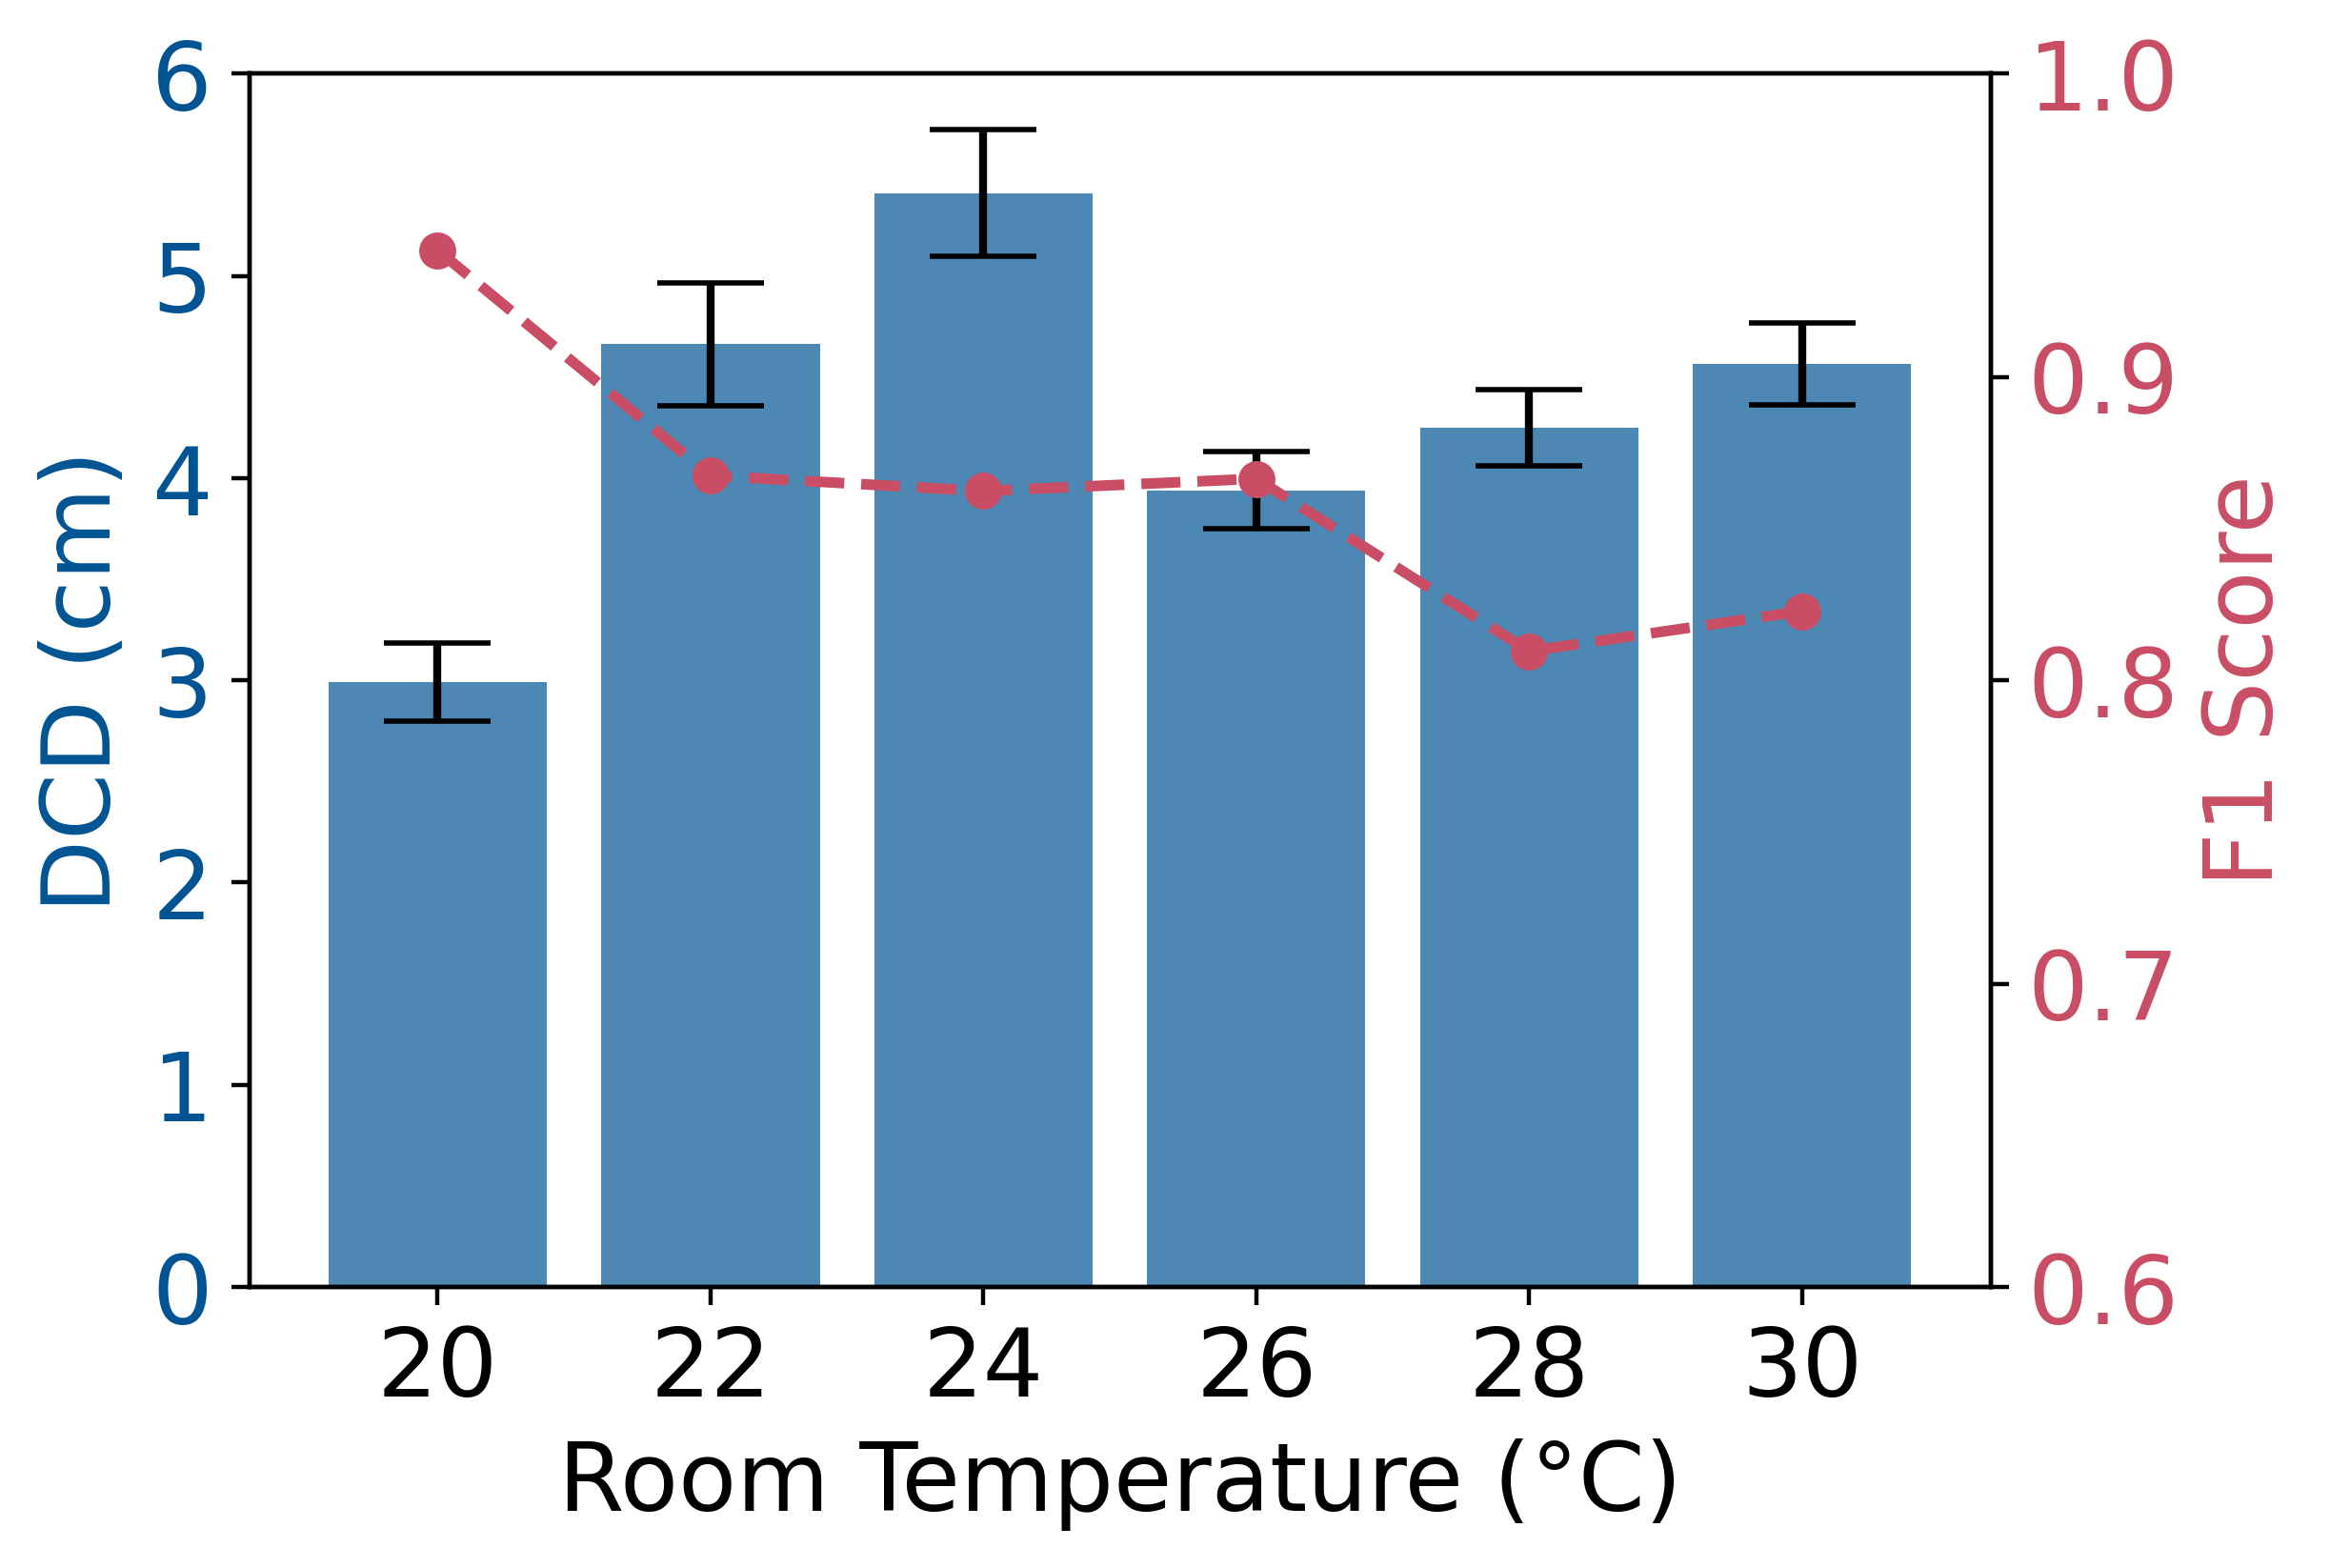

In [35]:
room_temperature_change_exp_folder_path = 'logs/m08/TAP3D_m08_add_RT_exp_thermo_pt_0609235152_test/final_metric.pickle'

num_samples = 0

room_temp_20_file_list = [
    'x_E17_1_standing_1o3_t20_0.pkl',
  'x_E17_1_standing_1o3_t20_1.pkl',
  'x_E17_1_standing_1o3_t20_2.pkl',
]

room_temp_22_file_list = [
    'x_E17_1_standing_1o3_t22_0.pkl',
  'x_E17_1_standing_1o3_t22_1.pkl',
  'x_E17_1_standing_1o3_t22_2.pkl',
]

room_temp_24_file_list = [
    'x_E17_1_standing_1o3_t24_0.pkl',
  'x_E17_1_standing_1o3_t24_1.pkl',
  'x_E17_1_standing_1o3_t24_2.pkl',
]

room_temp_26_file_list = [
    'x_E17_1_standing_1o3_t26_0.pkl',
  'x_E17_1_standing_1o3_t26_1.pkl',
  'x_E17_1_standing_1o3_t26_2.pkl',
]

room_temp_28_file_list = [
    'x_E17_1_standing_1o3_t28_0.pkl', 
  'x_E17_1_standing_1o3_t28_1.pkl',
  'x_E17_1_standing_1o3_t28_2.pkl',
]

room_temp_30_file_list = [
    'x_E17_1_standing_1o3_t30_0.pkl',
  # 'x_E17_1_standing_1o3_t30_1.pkl',  # this is not used since the data recording is interfered by the falling of the sensor
  'x_E17_1_standing_1o3_t30_2.pkl',
  'x_E17_1_standing_1o3_t30_3.pkl',
]

all_file_names = room_temp_20_file_list + room_temp_22_file_list + room_temp_24_file_list + room_temp_26_file_list + room_temp_28_file_list + room_temp_30_file_list
num_samples = len(load_metrics_df_0(room_temperature_change_exp_folder_path, all_file_names))
        

temperature_dict = {
    '20': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_20_file_list),
    '22': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_22_file_list),
    '24': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_24_file_list),
    '26': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_26_file_list),
    '28': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_28_file_list),
    '30': load_metrics_df_0(room_temperature_change_exp_folder_path, room_temp_30_file_list)
}

direct_chamfer_distance_list = []
direct_chamfer_distance_sem_list = []
f1_score_list = []

for key, value in temperature_dict.items():
  metrics = value.groupby('file_name').apply(
      lambda x: pd.Series({
          'file_name': x['file_name'].iloc[0],
          'true_positives': x['true_positives'].sum(),
          'false_positives': x['false_positives'].sum(),
          'false_negatives': x['false_negatives'].sum(),
          'chamfer_distance': x['chamfer_distance'].mean(),
          'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance'] / 2) / 10).mean(),
          'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance'] / 2) / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
      })
  ).reset_index(drop=True)
  metrics['f1_score'] = 2 * metrics['true_positives'] / (2 * metrics['true_positives'] + metrics['false_positives'] + metrics['false_negatives'])
  direct_chamfer_distance_list.append(metrics['One_directional_Chamfer_Distance'].mean())
  direct_chamfer_distance_sem_list.append(metrics['One_directional_Chamfer_Distance_sem'].mean())
  f1_score_list.append(metrics['f1_score'].mean())
  metrics['temperature'] = key


x_labels = [key for key in temperature_dict.keys()]
x = np.arange(len(x_labels))

# Optional error bars if present
cd_err = direct_chamfer_distance_sem_list
f1_err = f1_score_list

plt.rcParams.update({'font.size': 18})
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

# --- Bars: Directed Chamfer Distance (left y-axis) ---
bars = ax1.bar(
    x,
    direct_chamfer_distance_list,
    yerr=cd_err,
    capsize=10 if cd_err is not None else 0,
    color='#015493',
    alpha=0.7,
    label='DCD'
)
ax1.set_ylabel('DCD (cm)', color='#015493')
ax1.tick_params(axis='y', labelcolor='#015493')
ax1.set_ylim(0, 6)

# --- Line: F1 Score (right y-axis) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    f1_score_list,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='#C94E65',
    label='F1 Score'
)

ax2.set_ylabel('F1 Score', color='#C94E65')
ax2.tick_params(axis='y', labelcolor='#C94E65')
ax2.set_ylim(0.6, 1.0)

# --- X ticks & label coloring ---
ax1.set_xlabel('Room Temperature (°C)')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=0, ha='center')

print('direct_chamfer_distance_list: ', direct_chamfer_distance_list)
print('f1_score_list: ', f1_score_list)
print('x_labels: ', x_labels)

print("the average DCD is: ", np.mean(direct_chamfer_distance_list))
print("the average F1 score is: ", np.mean(f1_score_list))
print('num_samples: ', num_samples)


plt.show()


## 4. Ablation Study

### Figure 22: Impact of DIM parameters.

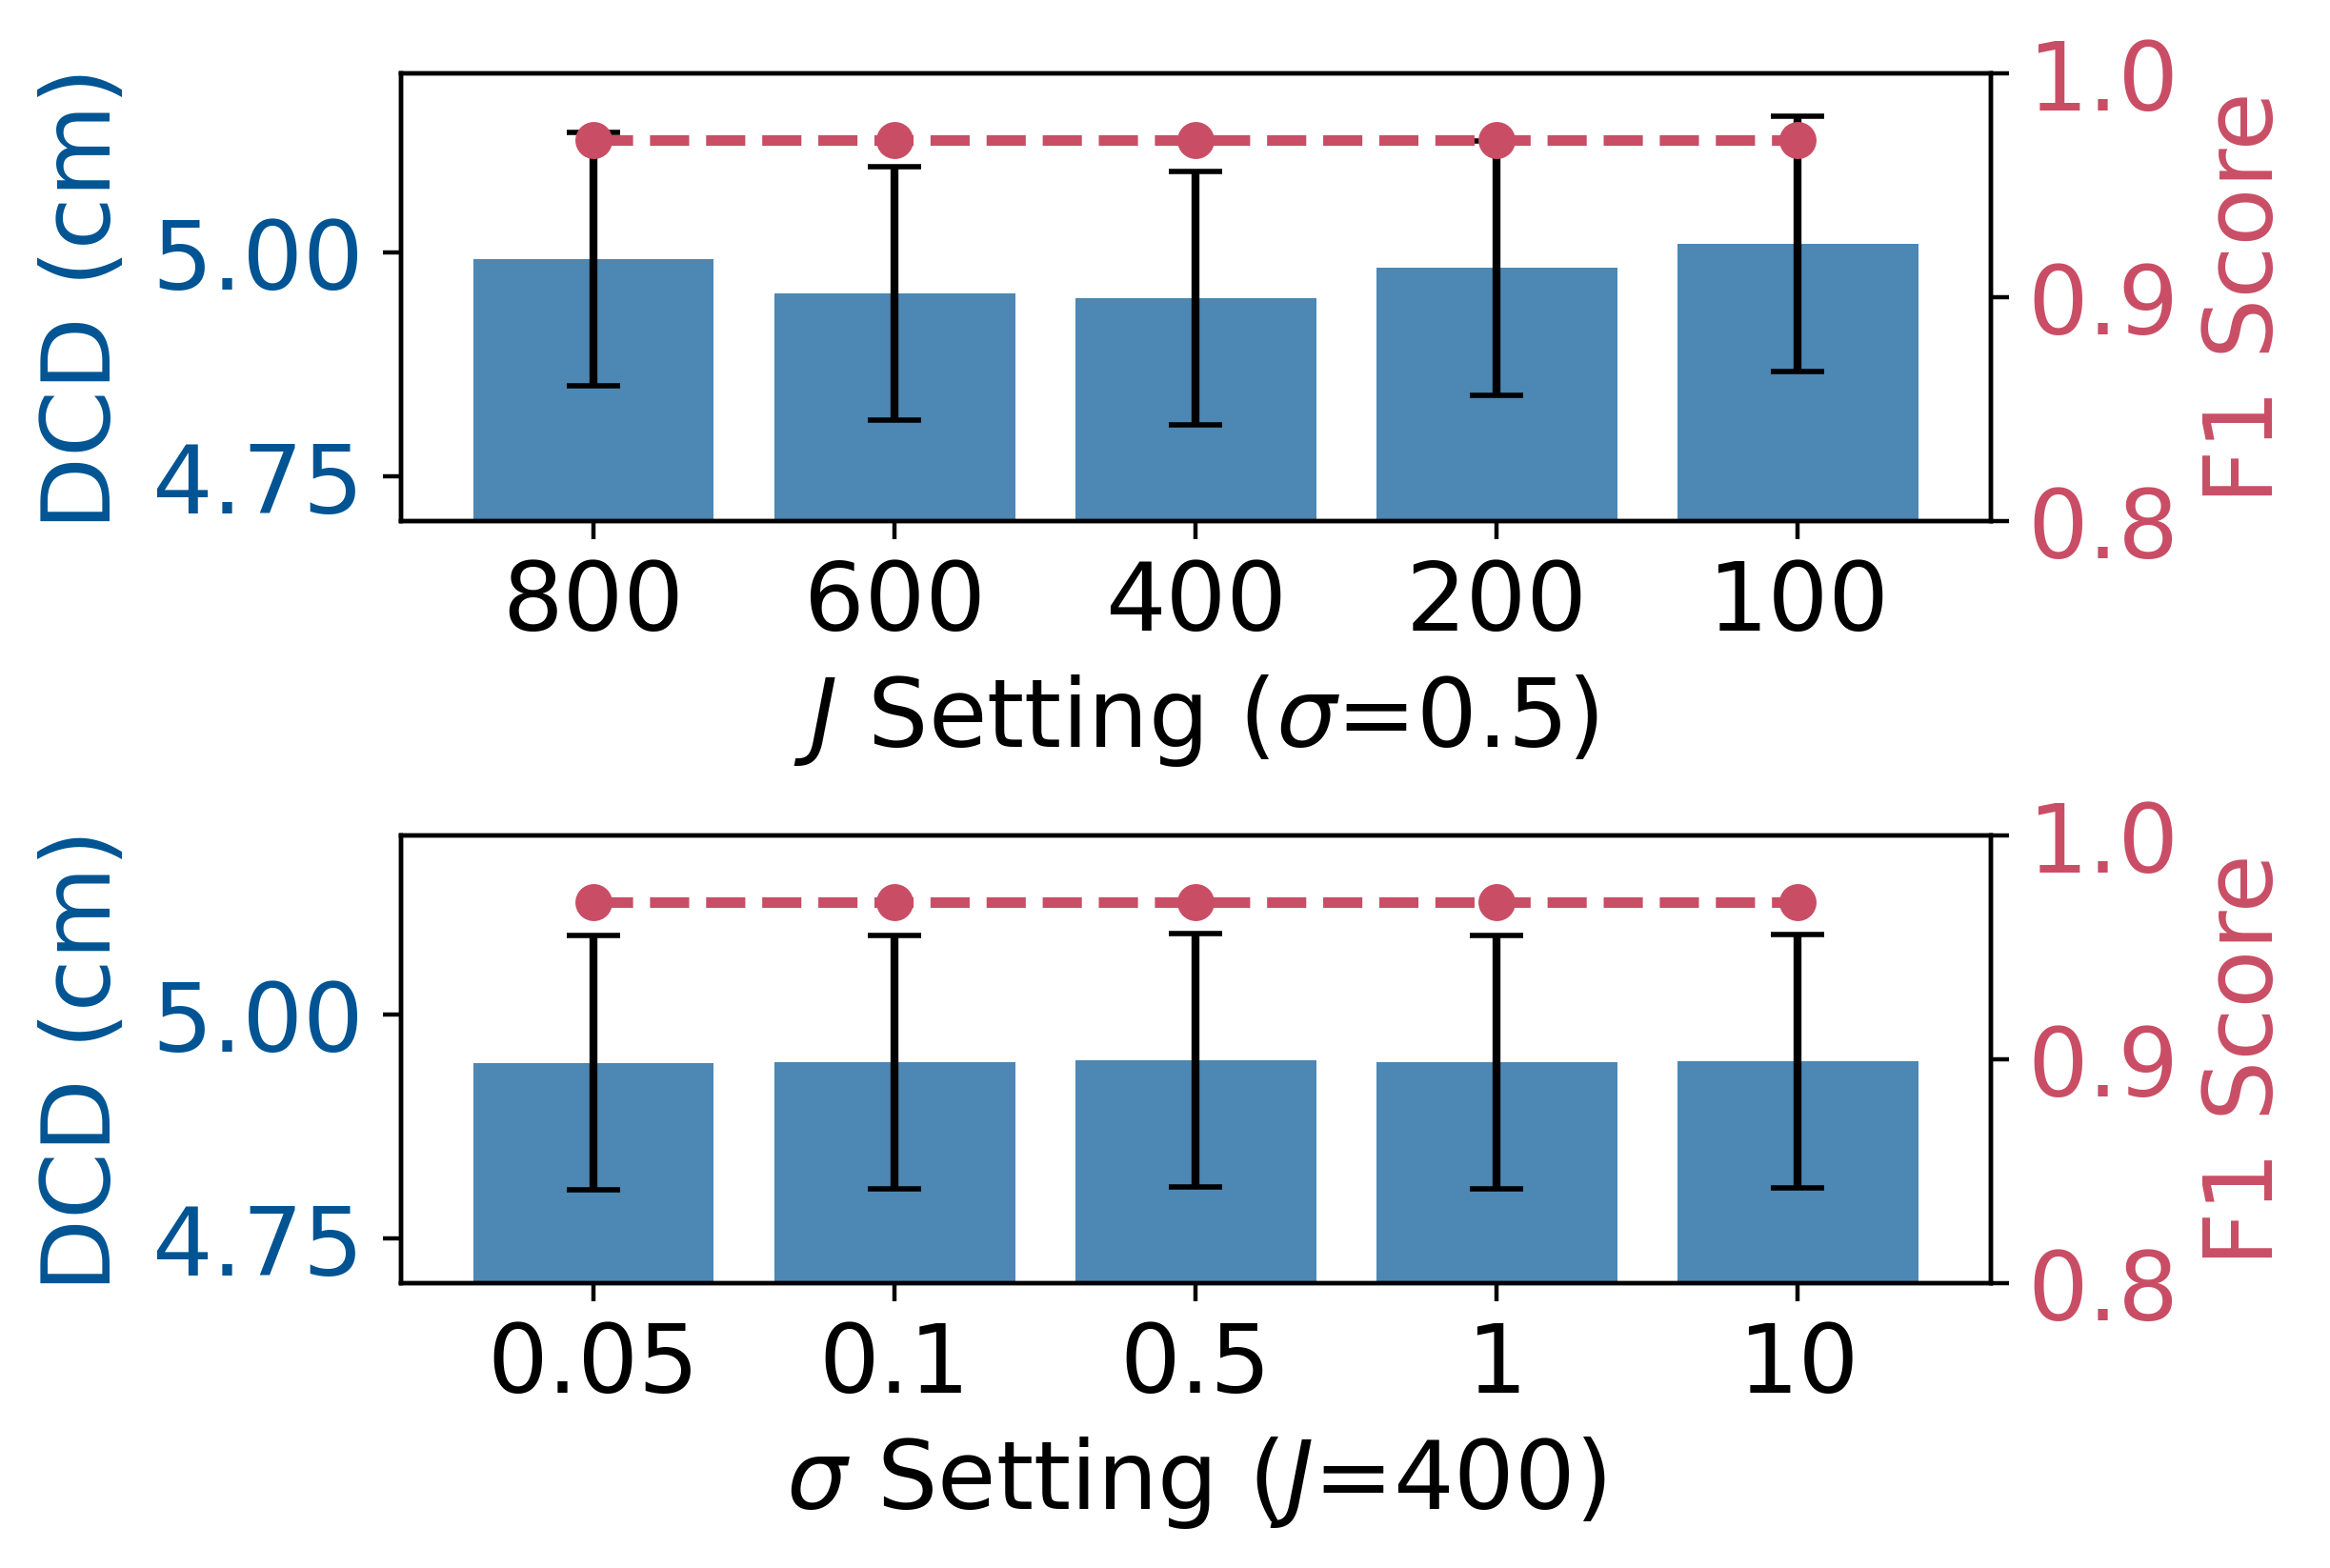

DIM levels: ['20', '22', '24', '26', '28', '30']
chamfer means: [4.948858676784651, 4.992888067483273, 4.954690630652656, 4.9826593279524545, 5.00948025720811, 4.9468439593397635, 4.946338037944789, 4.946631351374634, 4.947814049973318]
chamfer sems: [0.14175606806122237, 0.1417021057585609, 0.14177513135568937, 0.1420654910672946, 0.1429491275542106, 0.14173347972664796, 0.1417318432836451, 0.14173925975751692, 0.1416309642554967]
f1 means: [0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905, 0.9703964025868905]


In [36]:

default_config_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724123208_test/final_metric.pickle'
dim_j_600_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724142905_test_DIM_sensitivity_evaluation_14_0_8000_0_0_5/final_metric.pickle'
dim_j_800_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124244_test_DIM_sensitivity_evaluation_10_0_8000_0_0_5/final_metric.pickle'
dim_j_200_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124405_test_DIM_sensitivity_evaluation_40_0_8000_0_0_5/final_metric.pickle'
dim_j_100_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124523_test_DIM_sensitivity_evaluation_80_0_8000_0_0_5/final_metric.pickle'
dim_sig_01_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124638_test_DIM_sensitivity_evaluation_20_0_8000_0_0_1/final_metric.pickle'
dim_sig_005_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124800_test_DIM_sensitivity_evaluation_20_0_8000_0_0_05/final_metric.pickle'
dim_sig_1_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724124914_test_DIM_sensitivity_evaluation_20_0_8000_0_1_0/final_metric.pickle'
dim_sig_10_folder_path = 'logs/m08/TAP3D_m08_add_DIM_Sensitivity_thermo_pt_0724135105_test_DIM_sensitivity_evaluation_20_0_8000_0_10_0/final_metric.pickle'


default_f1_score, default_One_directional_Chamfer_Distance, default_One_directional_Chamfer_Distance_sem = get_the_measurement(default_config_folder_path, file_names)
dim_j_600_f1_score, dim_j_600_One_directional_Chamfer_Distance, dim_j_600_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_j_600_folder_path, file_names)
dim_j_800_f1_score, dim_j_800_One_directional_Chamfer_Distance, dim_j_800_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_j_800_folder_path, file_names)
dim_j_200_f1_score, dim_j_200_One_directional_Chamfer_Distance, dim_j_200_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_j_200_folder_path, file_names)
dim_j_100_f1_score, dim_j_100_One_directional_Chamfer_Distance, dim_j_100_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_j_100_folder_path, file_names)
dim_sig_01_f1_score, dim_sig_01_One_directional_Chamfer_Distance, dim_sig_01_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_sig_01_folder_path, file_names)
dim_sig_005_f1_score, dim_sig_005_One_directional_Chamfer_Distance, dim_sig_005_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_sig_005_folder_path, file_names)
dim_sig_1_f1_score, dim_sig_1_One_directional_Chamfer_Distance, dim_sig_1_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_sig_1_folder_path, file_names)
dim_sig_10_f1_score, dim_sig_10_One_directional_Chamfer_Distance, dim_sig_10_One_directional_Chamfer_Distance_sem = get_the_measurement(dim_sig_10_folder_path, file_names)


chamfer_means = [
    np.mean(default_One_directional_Chamfer_Distance),
    np.mean(dim_j_800_One_directional_Chamfer_Distance),
    np.mean(dim_j_600_One_directional_Chamfer_Distance),
    np.mean(dim_j_200_One_directional_Chamfer_Distance),
    np.mean(dim_j_100_One_directional_Chamfer_Distance),
    np.mean(dim_sig_01_One_directional_Chamfer_Distance),
    np.mean(dim_sig_005_One_directional_Chamfer_Distance),
    np.mean(dim_sig_1_One_directional_Chamfer_Distance),
    np.mean(dim_sig_10_One_directional_Chamfer_Distance)
]

chamfer_sems = [
    np.mean(default_One_directional_Chamfer_Distance_sem),
    np.mean(dim_j_800_One_directional_Chamfer_Distance_sem),
    np.mean(dim_j_600_One_directional_Chamfer_Distance_sem),
    np.mean(dim_j_200_One_directional_Chamfer_Distance_sem),
    np.mean(dim_j_100_One_directional_Chamfer_Distance_sem),
    np.mean(dim_sig_01_One_directional_Chamfer_Distance_sem),
    np.mean(dim_sig_005_One_directional_Chamfer_Distance_sem),
    np.mean(dim_sig_1_One_directional_Chamfer_Distance_sem),
    np.mean(dim_sig_10_One_directional_Chamfer_Distance_sem)
]


f1_means = [
    np.mean(default_f1_score),
    np.mean(dim_j_800_f1_score),
    np.mean(dim_j_600_f1_score),
    np.mean(dim_j_200_f1_score),
    np.mean(dim_j_100_f1_score),
    np.mean(dim_sig_01_f1_score),
    np.mean(dim_sig_005_f1_score),
    np.mean(dim_sig_1_f1_score),
    np.mean(dim_sig_10_f1_score)
]


plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(2, 1, figsize=(6, 4), dpi=400, layout='constrained')

def plot_dim_panel(ax, idx, labels, xlabel):
    x = np.arange(len(idx))

    chamfer_vals = [chamfer_means[i] for i in idx]
    chamfer_errs = [chamfer_sems[i] for i in idx]
    f1_vals = [f1_means[i] for i in idx]

    # Left y-axis: DCD bars
    bars = ax.bar(
        x,
        chamfer_vals,
        yerr=chamfer_errs,
        capsize=5,
        color='#015493',
        alpha=0.7,
        label='Directed Chamfer Distance'
    )
    ax.set_ylim(4.7, 5.2)
    ax.set_ylabel('DCD (cm)', color='#015493')
    ax.tick_params(axis='y', labelcolor='#015493')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)

    # Right y-axis: F1 line
    ax_r = ax.twinx()
    ax_r.plot(
        x,
        f1_vals,
        color='#C94E65',
        marker='o',
        linestyle='--',
        linewidth=2,
        label='F1 Score'
    )
    ax_r.set_ylim(0.8, 1.0)
    ax_r.set_ylabel('F1 Score', color='#C94E65')
    ax_r.tick_params(axis='y', labelcolor='#C94E65')

    return ax, ax_r

# Top subplot: sensitivity to J (sigma fixed at 0.5)
idx_j = [1, 2, 0, 3, 4]
labels_j = ['800', '600', '400' ,'200', '100']
ax1, ax1r = plot_dim_panel(axes[0], idx_j, labels_j, '$J$ Setting ($\sigma$=0.5)')

# Bottom subplot: sensitivity to sigma (J fixed at 400)
# Reordered sigma values for readability: 0.05, 0.1, 1, 10
idx_s = [6, 5, 0, 7, 8]
labels_s = ['0.05', '0.1', '0.5','1', '10']
ax2, ax2r = plot_dim_panel(axes[1], idx_s, labels_s, '$\sigma$ Setting ($J$=400)')

plt.show()

print('DIM levels:', x_labels)
print('chamfer means:', [float(ele) for ele in chamfer_means])
print('chamfer sems:', [float(ele) for ele in chamfer_sems])
print('f1 means:', [float(ele) for ele in f1_means])


### Figure 23: Effect of BEV refinement under varying numbers of users.

In [40]:
TAP3D_Log_folder_path = 'logs/m08/model3_m08_thermo_pt_1223164517_test/final_metric.pickle' #
model0_Log_folder_path = 'logs/m08/model0_m08_thermo_pt_1223162912_test/final_metric.pickle'  #
model1_Log_folder_path = 'logs/m08/model1_m08_thermo_pt_1223163549_test/final_metric.pickle'  #
model2_Log_folder_path = 'logs/m08/model2_m08_thermo_pt_1223164117_test/final_metric.pickle'  #
model4_Log_folder_path = 'logs/m08/model4_m08_thermo_pt_1222210636/final_metric.pickle'       #

def load_df(log_path):
    with open(log_path, 'rb') as f:
        metrics_data = pickle.load(f)
    file_names = []
    for i, file_metrics in enumerate(metrics_data['metrics']):
        file_name = metrics_data['file_name'][i]
        file_names.append(file_name)
    return file_names
    
def load_metrics_df_1(log_path, file_names):
    with open(log_path, 'rb') as f:
        metrics_data = pickle.load(f)
    all_metrics = []
    for i, file_metrics in enumerate(metrics_data['metrics']):
        file_name = metrics_data['file_name'][i]
        if file_name in file_names:
            # Instead of storing the complete list, store only the mean and std for each metric
            df = pd.DataFrame({
                'file_name': [file_name],
                'true_positives_mean': [np.mean(file_metrics['true_positives'])],
                'true_positives_std': [np.std(file_metrics['true_positives'])],
                'false_positives_mean': [np.mean(file_metrics['false_positives'])],
                'false_positives_std': [np.std(file_metrics['false_positives'])],
                'false_negatives_mean': [np.mean(file_metrics['false_negatives'])],
                'false_negatives_std': [np.std(file_metrics['false_negatives'])],
                'chamfer_distance_mean': [np.mean(file_metrics['chamfer_distance'])],
                'chamfer_distance_std': [np.std(file_metrics['chamfer_distance'])],
                'hausdorff_distance_mean': [np.mean(file_metrics['hausdorff_distance'])],
                'hausdorff_distance_std': [np.std(file_metrics['hausdorff_distance'])],
                'point2point_distance_mean': [np.mean(file_metrics['point2point_distance'])],
                'point2point_distance_std': [np.std(file_metrics['point2point_distance'])],
                'user_id': [file_metrics['user_id'][0] if isinstance(file_metrics['user_id'], (list, np.ndarray)) else file_metrics['user_id']],
                'env_id': [file_metrics['env_id'][0] if isinstance(file_metrics['env_id'], (list, np.ndarray)) else file_metrics['env_id']],
                'num_people': [file_metrics['num_people'][0] if isinstance(file_metrics['num_people'], (list, np.ndarray)) else file_metrics['num_people']],
                'activity_id': [file_metrics['activity_id'][0] if isinstance(file_metrics['activity_id'], (list, np.ndarray)) else file_metrics['activity_id']],
                'device_height': [file_metrics['device_height'][0] if isinstance(file_metrics['device_height'], (list, np.ndarray)) else file_metrics['device_height']],
                'x_average_mean': [np.mean(file_metrics['x_average'])],
                'x_average_std': [np.std(file_metrics['x_average'])],
                'y_average_mean': [np.mean(file_metrics['y_average'])],
                'y_average_std': [np.std(file_metrics['y_average'])],
                'z_average_mean': [np.mean(file_metrics['z_average'])],
                'z_average_std': [np.std(file_metrics['z_average'])],
                'F1_score': [2 * np.mean(file_metrics['true_positives']) / (2 * np.mean(file_metrics['true_positives']) + np.mean(file_metrics['false_positives']) + np.mean(file_metrics['false_negatives']))],
                'Recall': [np.mean(file_metrics['true_positives']) / (np.mean(file_metrics['true_positives']) + np.mean(file_metrics['false_negatives']))],
                'Precision': [np.mean(file_metrics['true_positives']) / (np.mean(file_metrics['true_positives']) + np.mean(file_metrics['false_positives']))],
            })
            all_metrics.append(df)

    metrics_df = pd.concat(all_metrics, ignore_index=True)
    metrics_df = metrics_df.fillna(0)
    metrics_df['distance_from_camera'] = np.sqrt(metrics_df['x_average_mean']**2 + metrics_df['y_average_mean']**2 + metrics_df['z_average_mean']**2)
    # use filename as index
    metrics_df = metrics_df.set_index('file_name')
    return metrics_df


model0_file_names = load_df(model0_Log_folder_path)
model1_file_names = load_df(model1_Log_folder_path)
model2_file_names = load_df(model2_Log_folder_path)
model4_file_names = load_df(model4_Log_folder_path)
TAP3D_file_names = load_df(TAP3D_Log_folder_path)


file_names = list(set(model0_file_names) & set(model1_file_names) & set(model2_file_names) & set(TAP3D_file_names) & set(model4_file_names))
print(len(file_names))

151


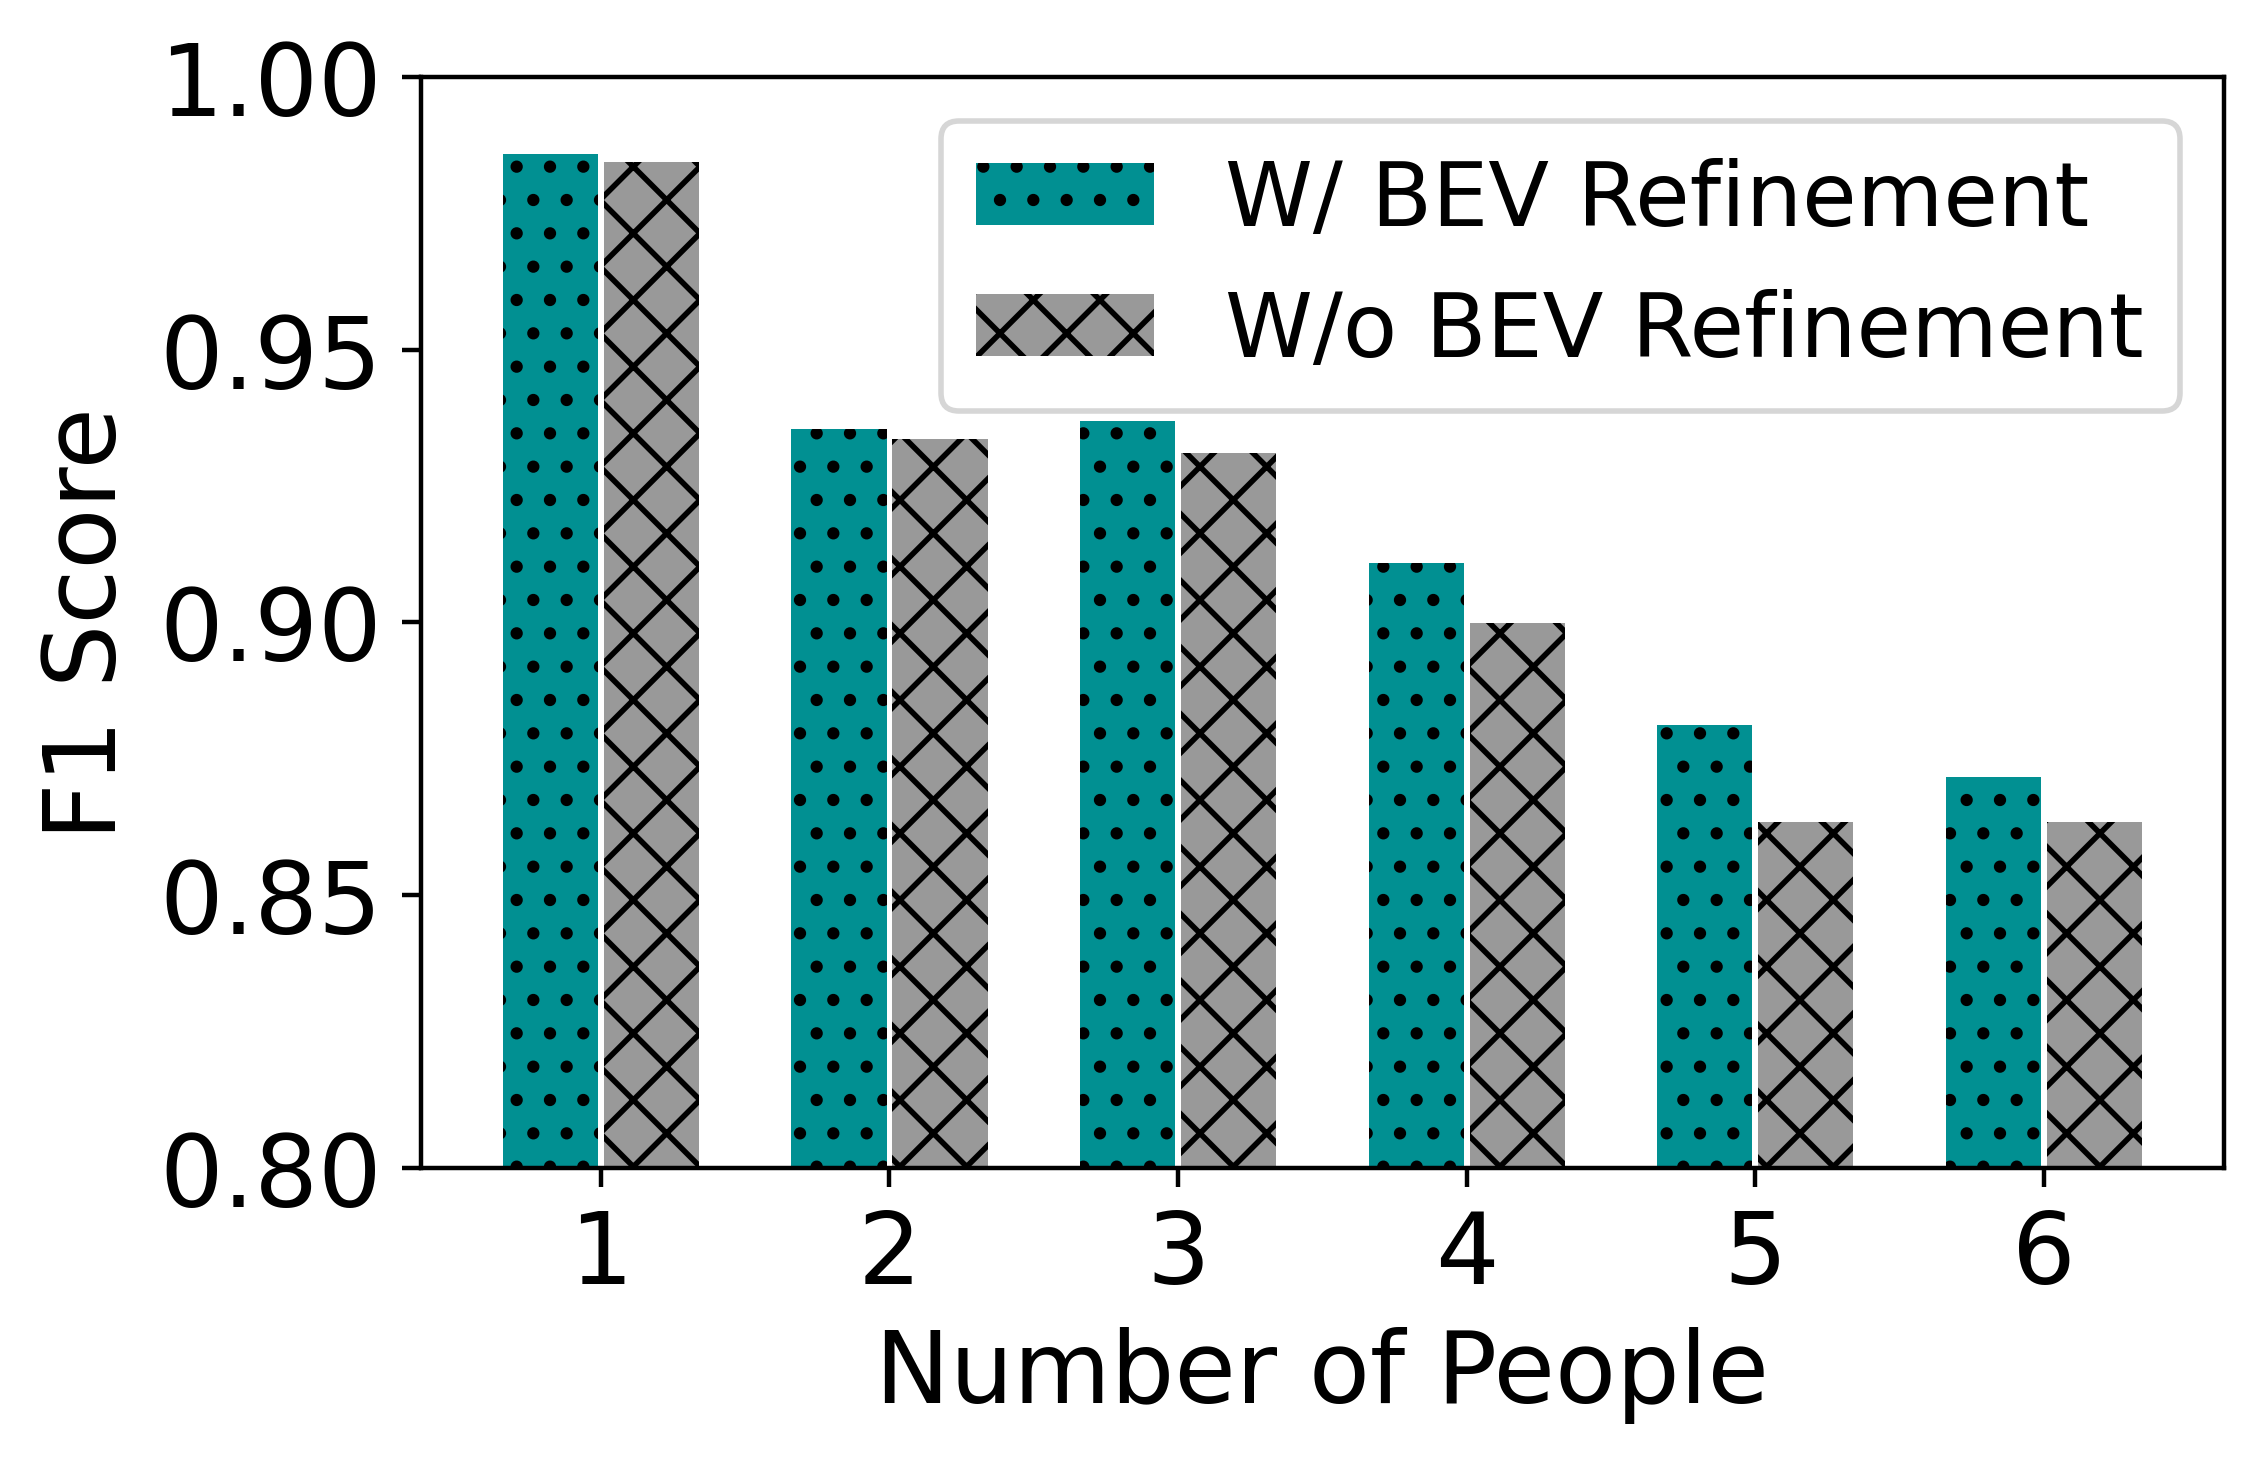

Diff of 1-3 people:  0.008975449024311022
Diff of 4-6 people:  0.03720482524179558


In [41]:
model1_metric_df = load_metrics_df_1(model1_Log_folder_path, file_names)
model3_metric_df = load_metrics_df_1(TAP3D_Log_folder_path, file_names)

results = []

if 'num_people' in model3_metric_df.columns and 'num_people' in model1_metric_df.columns:
    num_people_selected = model3_metric_df['num_people']
    # print("\nAverage F1 scores by 'num_people':")
    for n in sorted(num_people_selected.unique()):  
        idx = (model3_metric_df['num_people'] == n)
        m3_f1 = model3_metric_df.loc[idx, 'F1_score'].mean()
        m1_f1 = model1_metric_df.loc[idx, 'F1_score'].mean()
        count = idx.sum()
        results.append([n, m3_f1, m1_f1, count, m3_f1 - m1_f1])
else:
    print("'num_people' column not found in both DataFrames.")


results_df = pd.DataFrame(results, columns=['num_people', 'M3_F1', 'M1_F1', 'count', 'diff'])

df_plot = results_df[results_df['num_people'] != 0].reset_index(drop=True)

x = np.arange(len(df_plot['num_people']))  # label locations
width = 0.35  # width of each bar

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize = (6,4),dpi=400, layout='constrained')

ax.bar(
    x - width/2,
    df_plot['M3_F1'],
    capsize=5,
    width=width -0.02,
    label= 'W/ BEV Refinement',
    color='#019092',
    hatch='..'
)
ax.bar(
    x + width/2,
    df_plot['M1_F1'],
    capsize=5,
    width=width -0.02,
    label= 'W/o BEV Refinement',
    color='#999999',
    hatch='XX'
)

# Axis labels and ticks
ax.set_xlabel('Number of People')
ax.set_ylabel('F1 Score')
# ax.set_title('Comparison of F1 Score by Number of People')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['num_people'])
ax.set_ylim(0.8, 1)
ax.legend(fontsize=16, loc='upper right')

fig.tight_layout()

plt.show()

# sum the diff of the rows where the 'num_people' is 1 - 3
results_df_1_3_diff = results_df[(results_df['num_people'] <= 3) & (results_df['num_people'] >= 1)]['diff'].sum()
print('Diff of 1-3 people: ',results_df_1_3_diff)

# sum the diff of the rows where the 'num_people' is 4-6
results_df_4_6_diff = results_df[results_df['num_people'] >= 4]['diff'].sum()
print('Diff of 4-6 people: ',results_df_4_6_diff)

### Figure 24: Effect of OAV refinement under different ambient thermal interferences.

['U0_E3_1_walking_1o0_AI-PC_2.pkl', 'U0_E3_1_walking_1o0_AI-PT_2.pkl', 'U0_E4_1_walking_1o2_AI-SC_0.pkl', 'U0_E4_1_standing_1o2_AI-ST_0.pkl', 'U0_E4_1_walking_1o2_AI-ST_0.pkl', 'U0_E7_1_cooking_1o0_AI-CC_3.pkl', 'U0_E7_1_walking_1o0_AI-F_4.pkl']
{'Phone': np.float64(0.9990029910269193), 'Screen': np.float64(0.9854972548549483), 'cooking': np.float64(0.986), 'Fridge': np.float64(0.9219562955254943)}
{'Phone': np.float64(0.9975054875294277), 'Screen': np.float64(0.9741786320605893), 'cooking': np.float64(0.935361216730038), 'Fridge': np.float64(0.9033570701932858)}


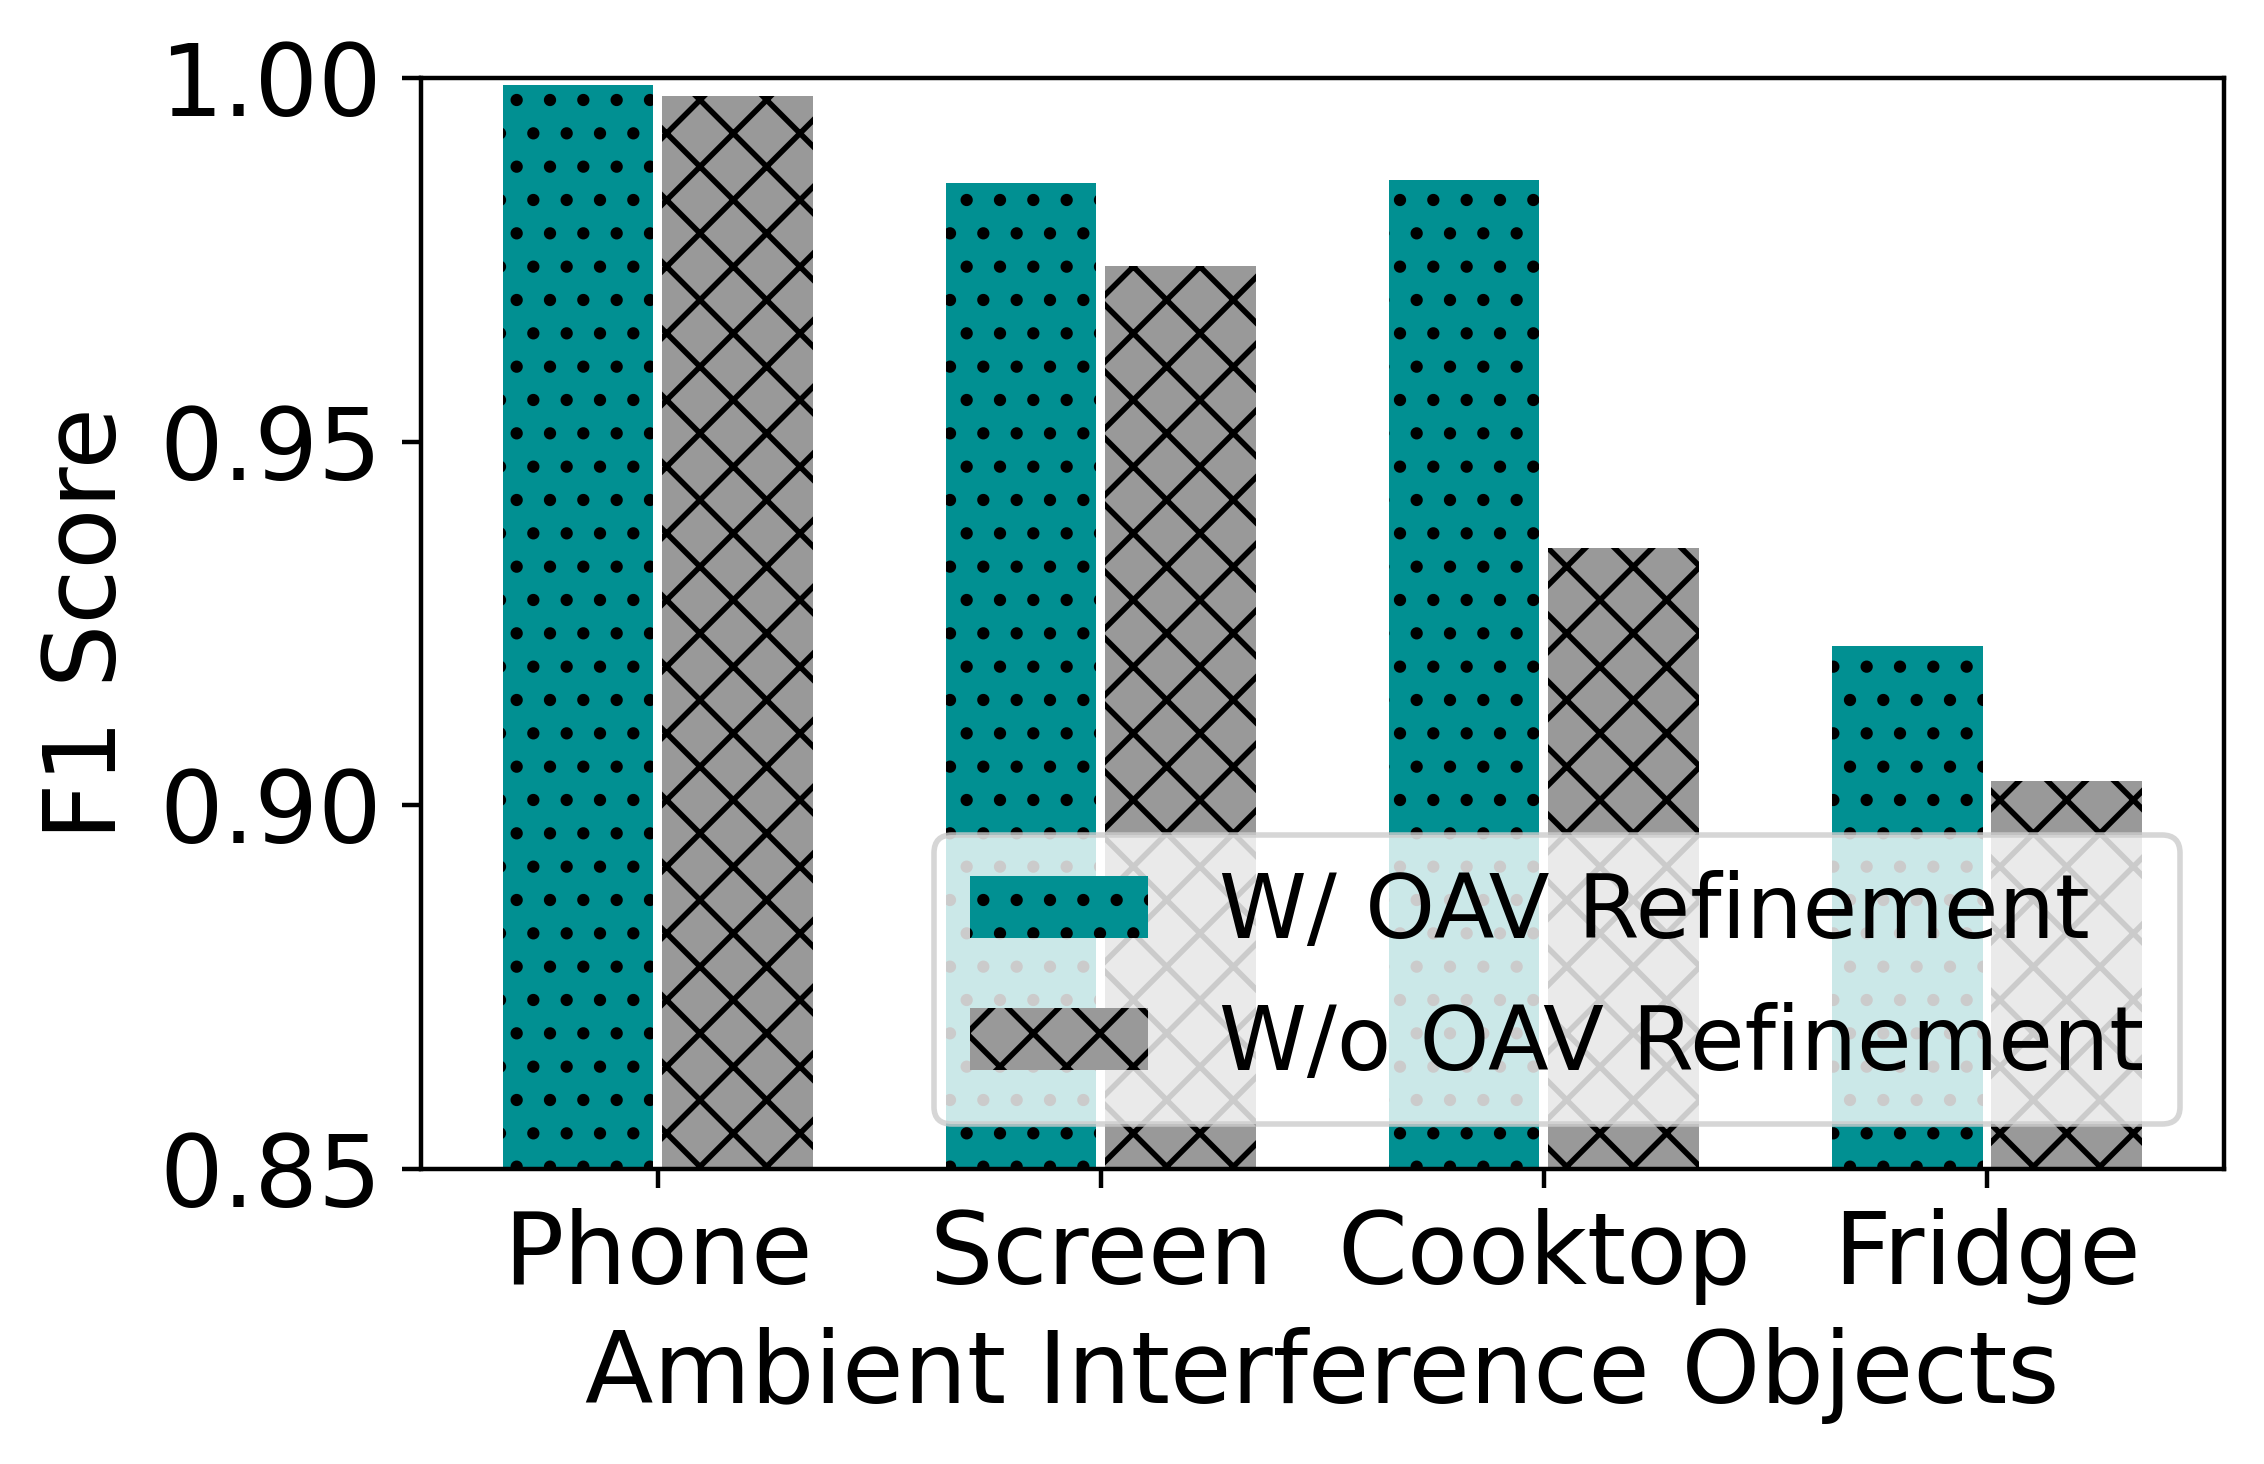

In [42]:
Phone = [
'U0_E3_1_walking_1o0_AI-PC_2.pkl',
'U0_E3_1_walking_1o0_AI-PT_2.pkl',
 ]
Screen = [
'U0_E4_1_walking_1o2_AI-SC_0.pkl',
'U0_E4_1_standing_1o2_AI-ST_0.pkl',
'U0_E4_1_walking_1o2_AI-ST_0.pkl',

 ]
cooking = [
'U0_E7_1_cooking_1o0_AI-CC_3.pkl',
 ]
Fridge = [
'U0_E7_1_walking_1o0_AI-F_4.pkl',
 ]

complete_file_list = Phone + Screen + cooking + Fridge
print(complete_file_list)

AI_files = {
    'Phone': Phone,
    'Screen': Screen,
    'cooking': cooking,
    'Fridge': Fridge,
}

model2_results = {}
for key, value in AI_files.items():
    temp = load_metrics_df_1(model2_Log_folder_path, value)
    f1_score = temp['F1_score'].mean()
    model2_results[key] = f1_score
    
model1_results = {}
for key, value in AI_files.items():
    temp = load_metrics_df_1(model1_Log_folder_path, value)
    f1_score = temp['F1_score'].mean()
    model1_results[key] = f1_score

print(model2_results)
print(model1_results)


# Rename 'cooking' → 'Cooktop' just for visualization
rename_map = {'cooking': 'Cooktop'}
cats = ['Phone', 'Screen', 'Cooktop', 'Fridge']

df_plot = pd.DataFrame({
    'Model1': pd.Series(model1_results).rename(index=rename_map),
    'Model2': pd.Series(model2_results).rename(index=rename_map),
}).loc[cats].reset_index().rename(columns={'index': 'Object'})

# ---- plot ----
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(6, 4), dpi=400, layout='constrained')

x = np.arange(len(df_plot['Object']))
width = 0.36

ax.bar(
    x - width/2,
    df_plot['Model2'],
    capsize=5,
    width=width - 0.02,
    label='W/ OAV Refinement',
    color='#019092',
    hatch='..'
)

ax.bar(
    x + width/2,
    df_plot['Model1'],
    capsize=5,
    width=width - 0.02,
    label= 'W/o OAV Refinement',
    color='#999999',
    hatch='XX'
)


# Axes & ticks
ax.set_xlabel('Ambient Interference Objects')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Object'])
ax.set_ylim(0.85, 1.)
ax.legend(loc='lower right', fontsize=16)
fig.tight_layout()

plt.show()

### Figure 25: Effect of multi-primitive estimation (MPE) on point cloud reconstruction accuracy.

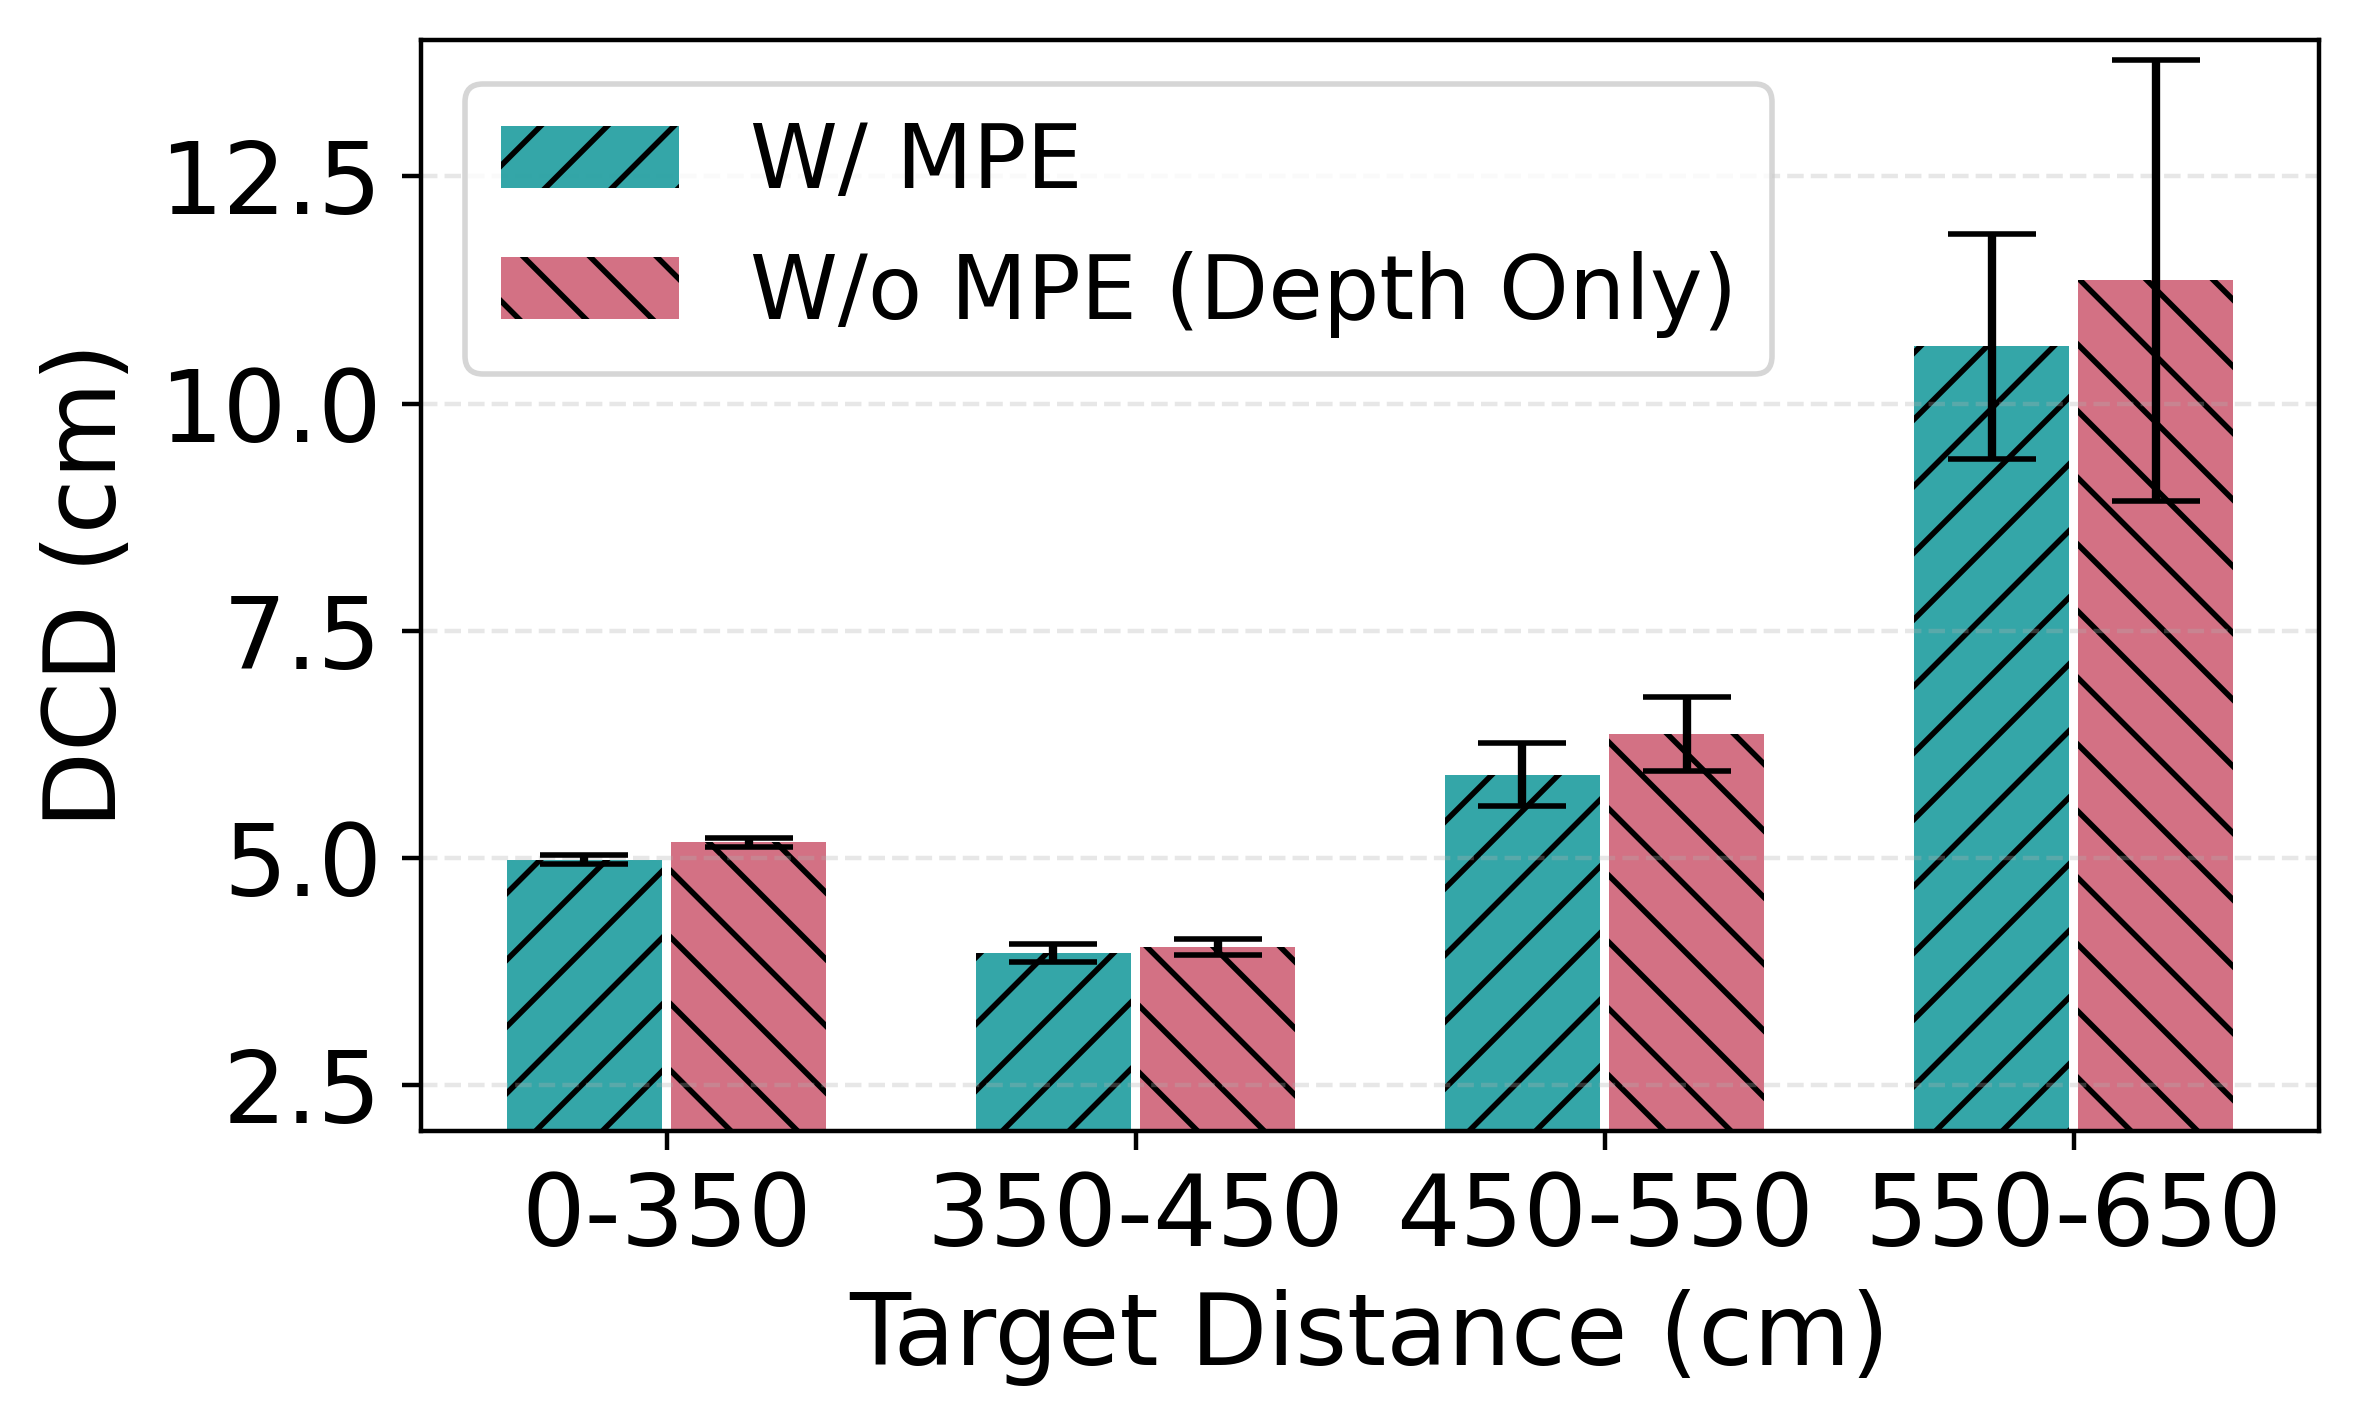

W/ Multi-Primitive Estimation, average DCD:  6.373745936710275
W/o Multi-Primitive Estimation (Depth Only), average DCD:  6.730203439912322
Gain:  0.055925903972574686


In [43]:
def get_distance_metric(model_name, file_names, bins):
    selected_metrics_df = load_metrics_df_0(model_name, file_names)

    min_distance = 0
    max_distance = 6500 # mm
    selected_metrics_df = selected_metrics_df[(selected_metrics_df['z_average'] >= min_distance) & (selected_metrics_df['z_average'] <= max_distance)]
    distance_bins = pd.cut(selected_metrics_df['z_average'], bins=bins, include_lowest=True)

    distance_metrics = selected_metrics_df.groupby(distance_bins).apply(lambda x: pd.Series({
        'distance_range': f"{x['z_average'].min():.1f}-{x['z_average'].max():.1f}",
        'precision': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_positives'].sum()) if (x['true_positives'].sum() + x['false_positives'].sum()) > 0 else 0,
        'recall': x['true_positives'].sum() / (x['true_positives'].sum() + x['false_negatives'].sum()) if (x['true_positives'].sum() + x['false_negatives'].sum()) > 0 else 0,
        'chamfer_distance': x['chamfer_distance'].mean(),
        'chamfer_distance_std': x['chamfer_distance'].std(),
        'chamfer_distance_sem': x['chamfer_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'hausdorff_distance': x['hausdorff_distance'].mean(),
        'hausdorff_distance_std': x['hausdorff_distance'].std(),
        'hausdorff_distance_sem': x['hausdorff_distance'].std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'point2point_distance': (x['point2point_distance'] / 10).mean(), # unit is cm
        'point2point_distance_std': (x['point2point_distance'] / 10).std(),
        'point2point_distance_sem': (x['point2point_distance'] / 10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
        'sample_count': len(x),
        'One_directional_Chamfer_Distance': (np.sqrt(x['chamfer_distance']/2)/10).mean(), # unit is cm
        'One_directional_Chamfer_Distance_std': (np.sqrt(x['chamfer_distance']/2)/10).std(),
        'One_directional_Chamfer_Distance_sem': (np.sqrt(x['chamfer_distance']/2)/10).std() / np.sqrt(len(x)) if len(x) > 0 else 0,
    }))
    return distance_metrics

bins = [0.  ,  3500. ,  4500. , 5500. , 6500.]
distance_metrics = get_distance_metric(model4_Log_folder_path, file_names, bins)
with_multi_primitive_chamfer_distance = distance_metrics['One_directional_Chamfer_Distance']
with_multi_primitive_chamfer_distance_error = distance_metrics['One_directional_Chamfer_Distance_sem']

distance_metrics = get_distance_metric(model0_Log_folder_path, file_names, bins)
without_multi_primitive_chamfer_distance = distance_metrics['One_directional_Chamfer_Distance']
without_multi_primitive_chamfer_distance_error = distance_metrics['One_directional_Chamfer_Distance_sem']


# draw the bar plot to compare the chamfer distance between the two models
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(6, 4),dpi=400, layout='constrained')

# Get the distance ranges as labels
x_labels = (distance_metrics.index.categories.left / 10).astype(int).astype(str) + '-' + (distance_metrics.index.categories.right / 10).astype(int).astype(str)
x = np.arange(len(x_labels))
width = 0.35

# Create bars
bars1 = plt.bar(x - width/2, with_multi_primitive_chamfer_distance, width=width - 0.02,
                yerr=with_multi_primitive_chamfer_distance_error,
                label='W/ MPE', capsize=8, alpha=0.8, hatch='//', color='#019092',)
bars2 = plt.bar(x + width/2, without_multi_primitive_chamfer_distance, width=width - 0.02,
                yerr=without_multi_primitive_chamfer_distance_error,
                label='W/o MPE (Depth Only)', capsize=8, alpha=0.8, hatch='\\\\', color='#C94E65',)


# Customize the plot
plt.xlabel('Target Distance (cm)')
plt.ylabel('DCD (cm)')
plt.xticks(x, x_labels, ha='center')
plt.legend(fontsize=16)
plt.ylim(2, 14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

# print the mean of the chamfer distance
print('W/ Multi-Primitive Estimation, average DCD: ',with_multi_primitive_chamfer_distance.mean())
print('W/o Multi-Primitive Estimation (Depth Only), average DCD: ',without_multi_primitive_chamfer_distance.mean())
# calculate the gain
print('Gain: ',(without_multi_primitive_chamfer_distance.mean() - with_multi_primitive_chamfer_distance.mean())/with_multi_primitive_chamfer_distance.mean())


### Figure 26: Effect of self-supervised pretraining with different amounts of labeled finetuning data.

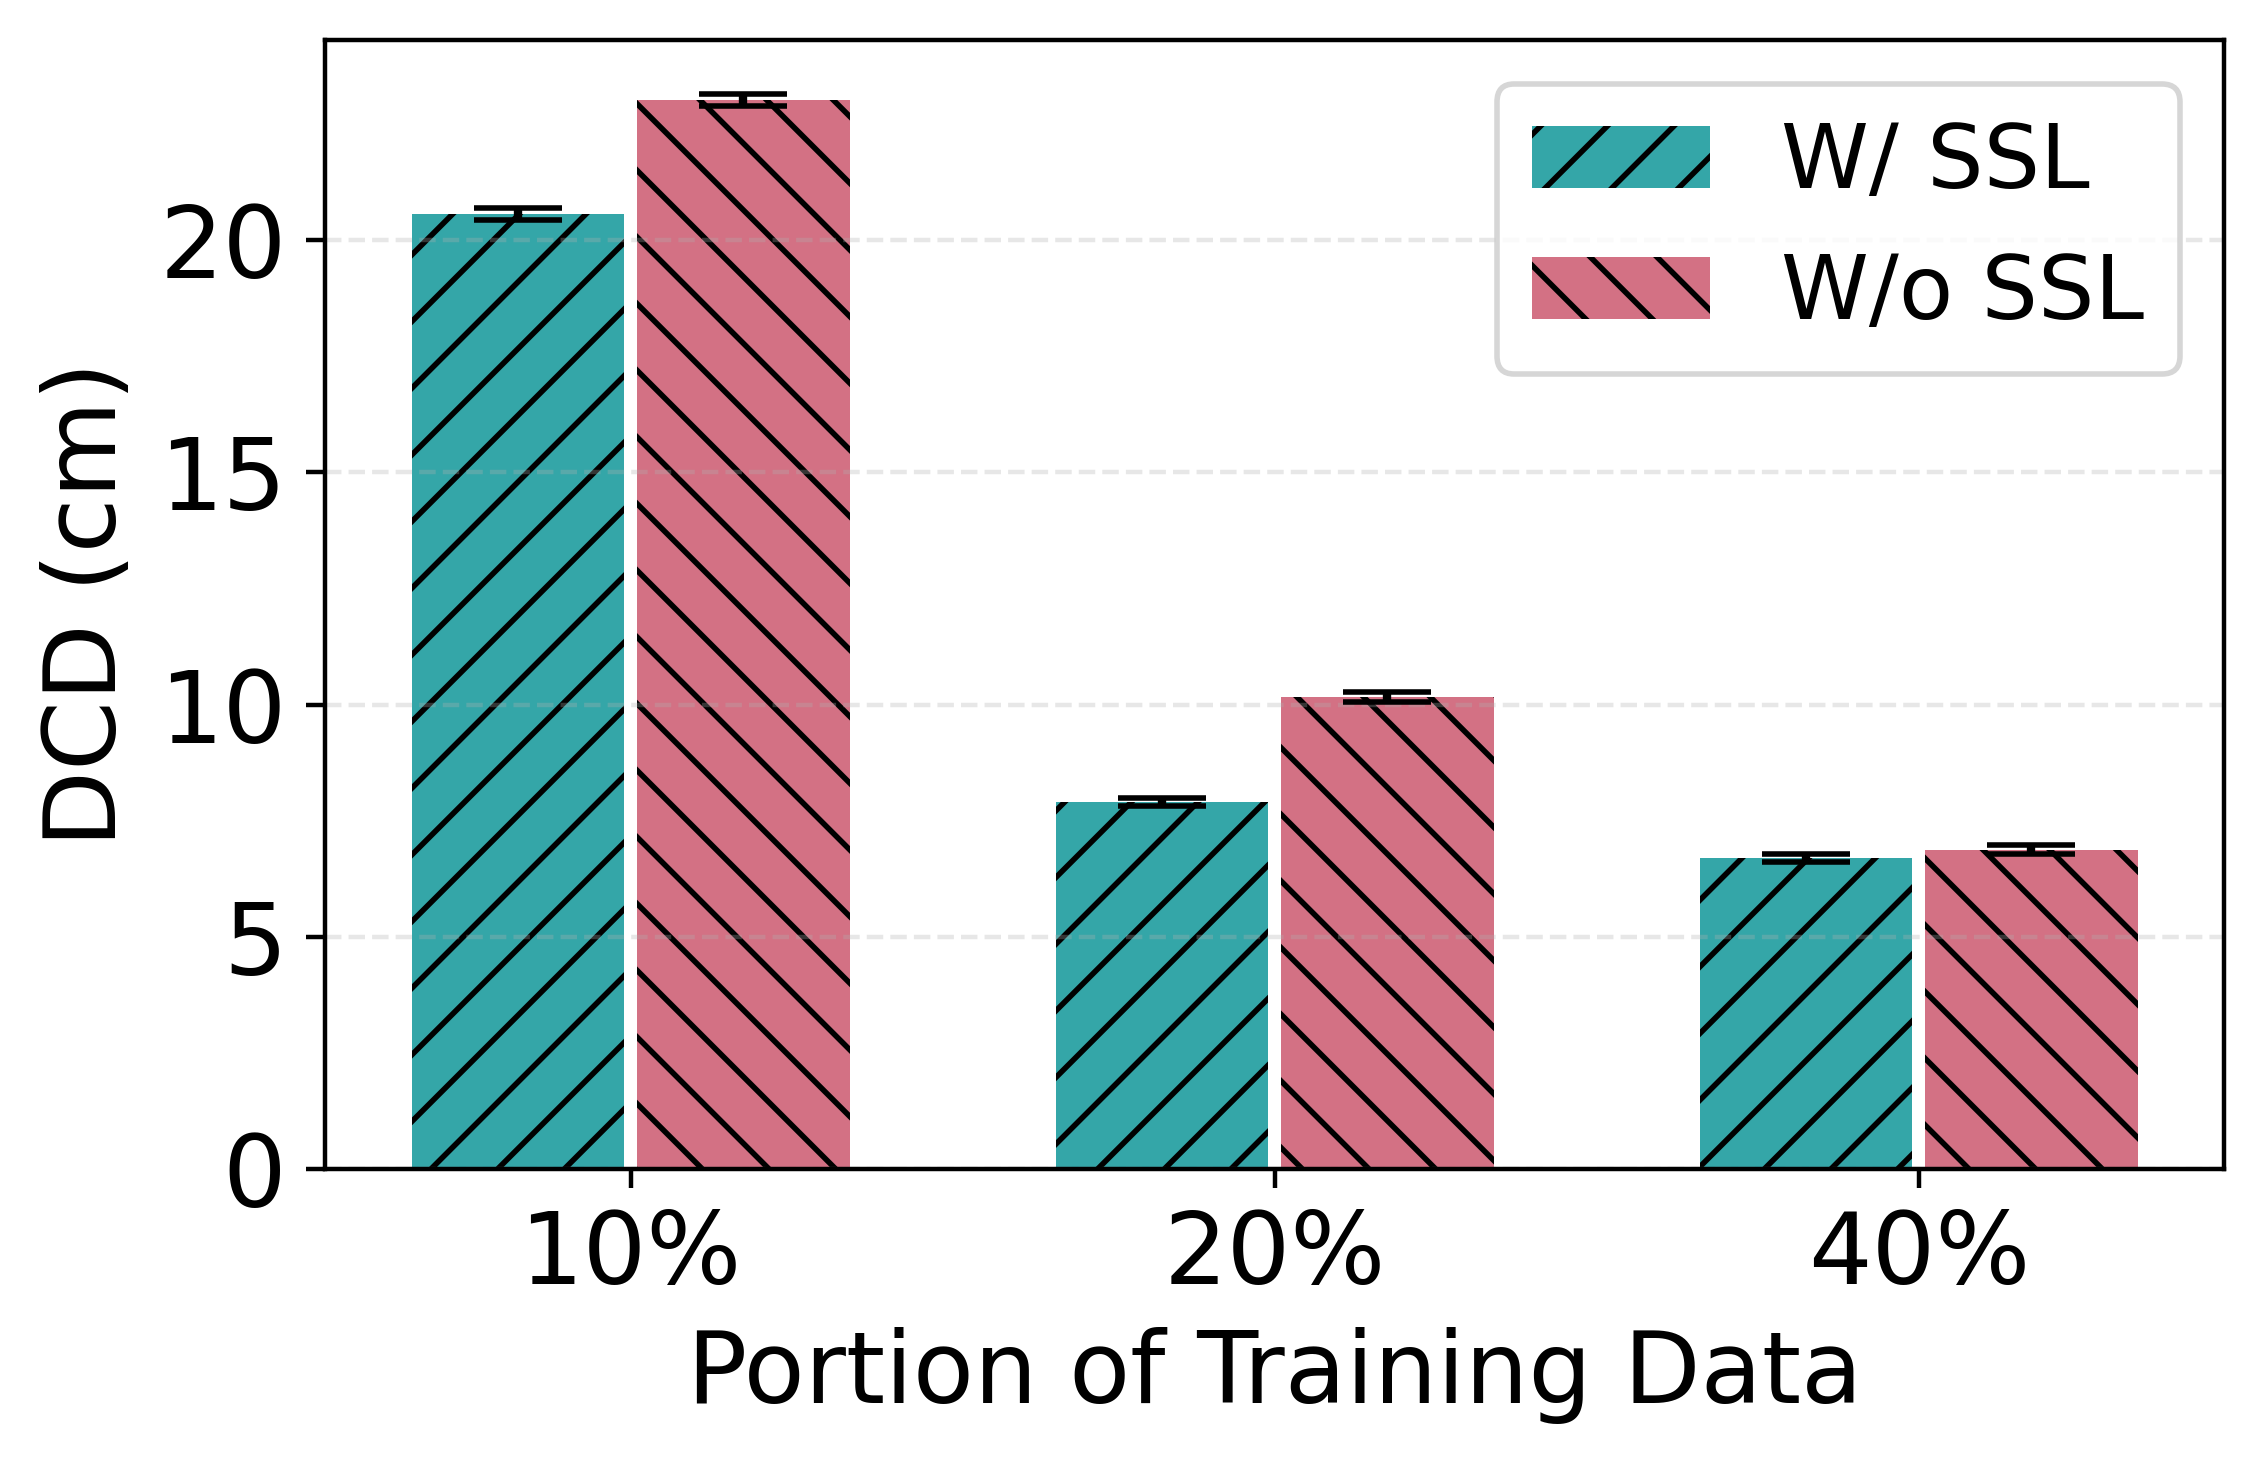

[np.float64(23.02201901350334), np.float64(10.17364311156878), np.float64(6.874899910826684)]
[np.float64(20.559451270547505), np.float64(7.895169936001702), np.float64(6.688753614728322)]
Gain:  0.11933347064681703


In [44]:

wo_ssl_0_1_folder_path = 'logs/m08/TAP3D_m08_SL_thermo_pt_1223230750_trainset_0_1/final_metric.pickle'
wo_ssl_0_2_folder_path = 'logs/m08/TAP3D_m08_SL_thermo_pt_1223234527_trainset_0_2/final_metric.pickle'
wo_ssl_0_4_folder_path = 'logs/m08/TAP3D_m08_SL_thermo_pt_1224004732_trainset_0_4/final_metric.pickle'

w_human_ssl_0_1_folder_path = 'logs/m08/TAP3D_m08_SSL_SL_thermo_pt_1224144225_finetune_trainset_0_1/final_metric.pickle'
w_human_ssl_0_2_folder_path = 'logs/m08/TAP3D_m08_SSL_SL_thermo_pt_1224150406_finetune_trainset_0_2/final_metric.pickle'
w_human_ssl_0_4_folder_path = 'logs/m08/TAP3D_m08_SSL_SL_thermo_pt_1228191624_finetune_trainset_0_4/final_metric.pickle'


wo_ssl_0_1_f1_score, wo_ssl_0_1_One_directional_Chamfer_Distance, wo_ssl_0_1_One_directional_Chamfer_Distance_sem = get_the_measurement(wo_ssl_0_1_folder_path, file_names)
wo_ssl_0_2_f1_score, wo_ssl_0_2_One_directional_Chamfer_Distance, wo_ssl_0_2_One_directional_Chamfer_Distance_sem = get_the_measurement(wo_ssl_0_2_folder_path, file_names)
wo_ssl_0_4_f1_score, wo_ssl_0_4_One_directional_Chamfer_Distance, wo_ssl_0_4_One_directional_Chamfer_Distance_sem = get_the_measurement(wo_ssl_0_4_folder_path, file_names)


chamfer_means0 = [
    np.mean(wo_ssl_0_1_One_directional_Chamfer_Distance),
    np.mean(wo_ssl_0_2_One_directional_Chamfer_Distance),
    np.mean(wo_ssl_0_4_One_directional_Chamfer_Distance),
]

chamfer_sems0 = [
    np.mean(wo_ssl_0_1_One_directional_Chamfer_Distance_sem),
    np.mean(wo_ssl_0_2_One_directional_Chamfer_Distance_sem),
    np.mean(wo_ssl_0_4_One_directional_Chamfer_Distance_sem),
]


w_human_ssl_0_1_f1_score, w_human_ssl_0_1_One_directional_Chamfer_Distance, w_human_ssl_0_1_One_directional_Chamfer_Distance_sem = get_the_measurement(w_human_ssl_0_1_folder_path, file_names)
w_human_ssl_0_2_f1_score, w_human_ssl_0_2_One_directional_Chamfer_Distance, w_human_ssl_0_2_One_directional_Chamfer_Distance_sem = get_the_measurement(w_human_ssl_0_2_folder_path, file_names)
w_human_ssl_0_4_f1_score, w_human_ssl_0_4_One_directional_Chamfer_Distance, w_human_ssl_0_4_One_directional_Chamfer_Distance_sem = get_the_measurement(w_human_ssl_0_4_folder_path, file_names)


chamfer_means1 = [
    np.mean(w_human_ssl_0_1_One_directional_Chamfer_Distance),
    np.mean(w_human_ssl_0_2_One_directional_Chamfer_Distance),
    np.mean(w_human_ssl_0_4_One_directional_Chamfer_Distance),
]

chamfer_sems1 = [
    np.mean(w_human_ssl_0_1_One_directional_Chamfer_Distance_sem),
    np.mean(w_human_ssl_0_2_One_directional_Chamfer_Distance_sem),
    np.mean(w_human_ssl_0_4_One_directional_Chamfer_Distance_sem),
]

# draw the bar plot to compare the chamfer distance between the two models
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(6, 4),dpi=400, layout='constrained')

# Get the distance ranges as labels
x_labels = [ '10%', '20%', '40%',]
x = np.arange(len(x_labels))
width = 0.35

bars2 = plt.bar(x - width/2, chamfer_means1, width=width - 0.02,
                yerr=chamfer_sems1,
                label='W/ SSL', capsize=8, alpha=0.8, hatch='//', color='#019092',)

bars1 = plt.bar(x + width/2, chamfer_means0, width=width - 0.02,
                yerr=chamfer_sems0,
                label='W/o SSL', capsize=8, alpha=0.8, hatch='\\\\', color='#C94E65',)

# Customize the plot
plt.xlabel('Portion of Training Data')
plt.ylabel('DCD (cm)')
plt.xticks(x, x_labels, ha='center')
# plt.ylim(2, 12)
plt.legend(fontsize=16, loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


print(chamfer_means0)
print(chamfer_means1)
# calculate the gain
print('Gain: ',((np.array(chamfer_means0) - np.array(chamfer_means1))/np.array(chamfer_means0)).mean())